In [2]:
%pip install seaborn

   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/294.9 kB 660.6 kB/s eta 0:00:01
   -------------------------- ------------- 194.6/294.9 kB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 2.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 01 — Exploration, fusion et préparation des données


## 1. Import des librairies et configuration

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## 2. Chargement des jeux de données


In [7]:
DATA_DIR = Path("data")

crop_yield = pd.read_csv(DATA_DIR / "crop_yield.csv")
pesticides = pd.read_csv(DATA_DIR / "pesticides.csv")
rainfall = pd.read_csv(DATA_DIR / "rainfall.csv")
temp = pd.read_csv(DATA_DIR / "temp.csv")
yield_df = pd.read_csv(DATA_DIR / "yield_df.csv")
yield_data = pd.read_csv(DATA_DIR / "yield.csv")



In [8]:
print("Dossier utilisé :", DATA_DIR.resolve())
print("Dossier existant :", DATA_DIR.exists())

for name, df in {
    "crop_yield": crop_yield,
    "pesticides": pesticides,
    "rainfall": rainfall,
    "temp": temp,
    "yield_df": yield_df,
    "yield_data": yield_data
}.items():
    print(f"{name:<15} : {df.shape}")

Dossier utilisé : C:\Users\obenb\Formation data scientist machine learning eng\Projet 12-\data
Dossier existant : True
crop_yield      : (1000000, 10)
pesticides      : (4349, 7)
rainfall        : (6727, 3)
temp            : (71311, 3)
yield_df        : (28242, 8)
yield_data      : (56717, 12)


## 3. Vue d'ensemble des jeux de données


### 3.1 Inspection générale des datasets

#### 3.1.1 Dataset `crop_yield`


In [11]:
print("Dimensions :", crop_yield.shape)

print("\n--- Colonnes ---")
print(crop_yield.columns.tolist())

print("\n--- Types ---")
print(crop_yield.dtypes)

print("\n--- Valeurs manquantes ---")
print(crop_yield.isna().sum())
print("Total :", crop_yield.isna().sum().sum())

print("\n--- Doublons ---")
print("Nombre de doublons :", crop_yield.duplicated().sum())

print("\n--- Aperçu ---")
display(crop_yield.head())

Dimensions : (1000000, 10)

--- Colonnes ---
['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']

--- Types ---
Region                     object
Soil_Type                  object
Crop                       object
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition          object
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

--- Valeurs manquantes ---
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64
Total : 0

--- Doublons ---
Nombre de doublons : 0

--- Aperçu ---


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


#### 3.1.2 Dataset `pesticides`

In [12]:
print("Dimensions :", pesticides.shape)

print("\n--- Colonnes ---")
print(pesticides.columns.tolist())

print("\n--- Types ---")
print(pesticides.dtypes)

print("\n--- Valeurs manquantes ---")
print(pesticides.isna().sum())
print("Total :", pesticides.isna().sum().sum())

print("\n--- Doublons ---")
print("Nombre de doublons :", pesticides.duplicated().sum())

print("\n--- Aperçu ---")
display(pesticides.head())

Dimensions : (4349, 7)

--- Colonnes ---
['Domain', 'Area', 'Element', 'Item', 'Year', 'Unit', 'Value']

--- Types ---
Domain      object
Area        object
Element     object
Item        object
Year         int64
Unit        object
Value      float64
dtype: object

--- Valeurs manquantes ---
Domain     0
Area       0
Element    0
Item       0
Year       0
Unit       0
Value      0
dtype: int64
Total : 0

--- Doublons ---
Nombre de doublons : 0

--- Aperçu ---


,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


#### 3.1.3 Dataset `rainfall`

In [13]:
print("Dimensions :", rainfall.shape)

print("\n--- Colonnes ---")
print(rainfall.columns.tolist())

print("\n--- Types ---")
print(rainfall.dtypes)

print("\n--- Valeurs manquantes ---")
print(rainfall.isna().sum())
print("Total :", rainfall.isna().sum().sum())

print("\n--- Doublons ---")
print("Nombre de doublons :", rainfall.duplicated().sum())

print("\n--- Aperçu ---")
display(rainfall.head())

Dimensions : (6727, 3)

--- Colonnes ---
[' Area', 'Year', 'average_rain_fall_mm_per_year']

--- Types ---
 Area                            object
Year                              int64
average_rain_fall_mm_per_year    object
dtype: object

--- Valeurs manquantes ---
 Area                              0
Year                               0
average_rain_fall_mm_per_year    774
dtype: int64
Total : 774

--- Doublons ---
Nombre de doublons : 0

--- Aperçu ---


,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985,327
1,Afghanistan,1986,327
2,Afghanistan,1987,327
3,Afghanistan,1989,327
4,Afghanistan,1990,327


#### 3.1.4 Dataset `temp`

In [14]:
print("Dimensions :", temp.shape)

print("\n--- Colonnes ---")
print(temp.columns.tolist())

print("\n--- Types ---")
print(temp.dtypes)

print("\n--- Valeurs manquantes ---")
print(temp.isna().sum())
print("Total :", temp.isna().sum().sum())

print("\n--- Doublons ---")
print("Nombre de doublons :", temp.duplicated().sum())

print("\n--- Aperçu ---")
display(temp.head())

Dimensions : (71311, 3)

--- Colonnes ---
['year', 'country', 'avg_temp']

--- Types ---
year          int64
country      object
avg_temp    float64
dtype: object

--- Valeurs manquantes ---
year           0
country        0
avg_temp    2547
dtype: int64
Total : 2547

--- Doublons ---
Nombre de doublons : 6958

--- Aperçu ---


,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


#### 3.1.5 Dataset `yield_df`

In [15]:
print("Dimensions :", yield_df.shape)

print("\n--- Colonnes ---")
print(yield_df.columns.tolist())

print("\n--- Types ---")
print(yield_df.dtypes)

print("\n--- Valeurs manquantes ---")
print(yield_df.isna().sum())
print("Total :", yield_df.isna().sum().sum())

print("\n--- Doublons ---")
print("Nombre de doublons :", yield_df.duplicated().sum())

print("\n--- Aperçu ---")
display(yield_df.head())

Dimensions : (28242, 8)

--- Colonnes ---
['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

--- Types ---
Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

--- Valeurs manquantes ---
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64
Total : 0

--- Doublons ---
Nombre de doublons : 0

--- Aperçu ---


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


#### 3.1.6 Dataset `yield_data`

In [16]:
print("Dimensions :", yield_data.shape)

print("\n--- Colonnes ---")
print(yield_data.columns.tolist())

print("\n--- Types ---")
print(yield_data.dtypes)

print("\n--- Valeurs manquantes ---")
print(yield_data.isna().sum())
print("Total :", yield_data.isna().sum().sum())

print("\n--- Doublons ---")
print("Nombre de doublons :", yield_data.duplicated().sum())

print("\n--- Aperçu ---")
display(yield_data.head())

Dimensions : (56717, 12)

--- Colonnes ---
['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element', 'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value']

--- Types ---
Domain Code     object
Domain          object
Area Code        int64
Area            object
Element Code     int64
Element         object
Item Code        int64
Item            object
Year Code        int64
Year             int64
Unit            object
Value            int64
dtype: object

--- Valeurs manquantes ---
Domain Code     0
Domain          0
Area Code       0
Area            0
Element Code    0
Element         0
Item Code       0
Item            0
Year Code       0
Year            0
Unit            0
Value           0
dtype: int64
Total : 0

--- Doublons ---
Nombre de doublons : 0

--- Aperçu ---


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


### 3.2 Synthèse de l'inspection initiale

L'inspection des différents jeux de données met en évidence des structures et des
niveaux de qualité différents. Certains fichiers semblent correspondre à des sources
brutes tandis que d'autres semblent déjà résulter d'opérations de préparation ou
de fusion.

Les prochaines analyses permettront de déterminer précisément leur granularité,
leurs relations et leur rôle dans la construction du dataset consolidé.

| Dataset | Dimensions | Valeurs manquantes | Doublons | Observation principale |
|---|---:|---:|---:|---|
| `crop_yield` | 1 000 000 × 10 | 0 | 0 | Dataset très volumineux avec rendement, climat et pratiques agricoles |
| `pesticides` | 4 349 × 7 | 0 | 0 | Données sur les pesticides structurées par zone et année |
| `rainfall` | 6 727 × 3 | 774 | 0 | Précipitations annuelles avec valeurs manquantes et type à vérifier |
| `temp` | 71 311 × 3 | 2 547 | 6 958 | Températures avec valeurs manquantes et nombreux doublons |
| `yield_df` | 28 242 × 8 | 0 | 0 | Dataset qui semble déjà combiner rendement, pluie, pesticides et température |
| `yield_data` | 56 717 × 12 | 0 | 0 | Données détaillées de rendement par zone, culture et année |

### 3.3 Analyse de la granularité des jeux de données

#### 3.3.1 Granularité de `crop_yield`

In [17]:
print("Nombre de régions :", crop_yield["Region"].nunique())
print(crop_yield["Region"].unique())

print("\nNombre de types de sol :", crop_yield["Soil_Type"].nunique())
print(crop_yield["Soil_Type"].unique())

print("\nNombre de cultures :", crop_yield["Crop"].nunique())
print(crop_yield["Crop"].unique())

print("\nConditions météo :")
print(crop_yield["Weather_Condition"].value_counts())

print("\nUtilisation d'engrais :")
print(crop_yield["Fertilizer_Used"].value_counts())

print("\nUtilisation de l'irrigation :")
print(crop_yield["Irrigation_Used"].value_counts())

Nombre de régions : 4
['West' 'South' 'North' 'East']

Nombre de types de sol : 6
['Sandy' 'Clay' 'Loam' 'Silt' 'Peaty' 'Chalky']

Nombre de cultures : 6
['Cotton' 'Rice' 'Barley' 'Soybean' 'Wheat' 'Maize']

Conditions météo :
Weather_Condition
Sunny     333790
Rainy     333561
Cloudy    332649
Name: count, dtype: int64

Utilisation d'engrais :
Fertilizer_Used
False    500060
True     499940
Name: count, dtype: int64

Utilisation de l'irrigation :
Irrigation_Used
False    500509
True     499491
Name: count, dtype: int64


##### Premières observations sur la granularité de `crop_yield`

Le dataset contient quatre régions génériques (`West`, `South`, `North`, `East`)
et ne comporte aucune variable temporelle telle qu'une année.

Il n'est donc pas possible, à ce stade, d'établir une correspondance géographique
ou temporelle directe avec les datasets utilisant des pays (`Area`, `country`)
et des années (`Year`, `year`).

Le dataset contient six cultures et plusieurs caractéristiques agronomiques et
climatiques directement associées au rendement. La granularité exacte d'une
observation devra être précisée lors de l'analyse approfondie du dataset.

#### 3.3.2 Granularité de `pesticides`


In [20]:
print("Nombre de zones :", pesticides["Area"].nunique())
print("Exemples de zones :")
print(pesticides["Area"].unique()[:20])

print("\nPériode couverte :")
print("Année minimale :", pesticides["Year"].min())
print("Année maximale :", pesticides["Year"].max())
print("Nombre d'années :", pesticides["Year"].nunique())

print("\nDomain :")
print(pesticides["Domain"].value_counts())

print("\nElement :")
print(pesticides["Element"].value_counts())

print("\nItem :")
print(pesticides["Item"].value_counts())

print("\nUnités :")
print(pesticides["Unit"].value_counts())

print("\nNombre de doublons sur (Area, Year) :")
print(
    pesticides.duplicated(
        subset=["Area", "Year"]
    ).sum()
)

Nombre de zones : 168
Exemples de zones :
['Albania' 'Algeria' 'Angola' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belgium-Luxembourg' 'Belize' 'Bermuda'
 'Bhutan' 'Bolivia (Plurinational State of)']

Période couverte :
Année minimale : 1990
Année maximale : 2016
Nombre d'années : 27

Domain :
Domain
Pesticides Use    4349
Name: count, dtype: int64

Element :
Element
Use    4349
Name: count, dtype: int64

Item :
Item
Pesticides (total)    4349
Name: count, dtype: int64

Unités :
Unit
tonnes of active ingredients    4349
Name: count, dtype: int64

Nombre de doublons sur (Area, Year) :
0


##### Premières observations sur la granularité de `pesticides`

Le dataset couvre 168 zones géographiques sur une période allant de 1990 à 2016.

Les variables `Domain`, `Element`, `Item` et `Unit` sont constantes dans l'ensemble
du dataset. La variable `Value` représente l'utilisation totale de pesticides,
exprimée en tonnes de substances actives.

La granularité semble donc être principalement définie par le couple
`Area` / `Year`. L'unicité de cette combinaison devra être vérifiée avant
d'utiliser ces variables comme clés de jointure.

#### 3.3.3 Granularité de `rainfall`


In [19]:
print("Nombre de zones :", rainfall[" Area"].nunique())

print("\nExemples de zones :")
print(rainfall[" Area"].unique()[:20])

print("\nPériode couverte :")
print("Année minimale :", rainfall["Year"].min())
print("Année maximale :", rainfall["Year"].max())
print("Nombre d'années :", rainfall["Year"].nunique())

print("\nNombre de doublons sur (Area, Year) :")
print(
    rainfall.duplicated(
        subset=[" Area", "Year"]
    ).sum()
)

print("\nType de la variable de précipitations :")
print(rainfall["average_rain_fall_mm_per_year"].dtype)

print("\nExemples de valeurs :")
print(
    rainfall["average_rain_fall_mm_per_year"]
    .dropna()
    .unique()[:20]
)

Nombre de zones : 217

Exemples de zones :
['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize']

Période couverte :
Année minimale : 1985
Année maximale : 2017
Nombre d'années : 31

Nombre de doublons sur (Area, Year) :
0

Type de la variable de précipitations :
object

Exemples de valeurs :
['327' '1485' '89' '1010' '1030' '591' '562' '534' '1110' '447' '..'
 '1292' '83' '2666' '1422' '618' '847' '1705' '1039' '2200']


##### Conclusion sur la granularité de `rainfall`

Le dataset couvre 217 zones géographiques sur une période allant de 1985 à 2017.

Aucun doublon n'a été identifié sur la combinaison (`Area`, `Year`). Chaque
observation correspond donc à une zone géographique et une année uniques,
associées à une valeur de précipitations annuelles moyennes.

Le couple (`Area`, `Year`) constitue ainsi une clé potentielle pour les futures
opérations de jointure.

La variable `average_rain_fall_mm_per_year` est cependant stockée sous forme
de texte (`object`) alors qu'elle représente une mesure quantitative. L'inspection
révèle notamment la présence de la valeur spéciale `..` parmi les observations.
Ce problème devra être analysé et traité lors de la phase de nettoyage.

Le nom de la colonne ` Area` contient également un espace initial qui devra être
corrigé afin d'harmoniser les noms de variables entre les différents datasets.

#### 3.3.4 Granularité de `temp`


In [21]:
print("Nombre de pays :", temp["country"].nunique())

print("\nExemples de pays :")
print(temp["country"].unique()[:20])

print("\nPériode couverte :")
print("Année minimale :", temp["year"].min())
print("Année maximale :", temp["year"].max())
print("Nombre d'années :", temp["year"].nunique())

print("\nNombre de doublons exacts :")
print(temp.duplicated().sum())

print("\nNombre de doublons sur (country, year) :")
print(
    temp.duplicated(
        subset=["country", "year"]
    ).sum()
)

print("\nValeurs manquantes de avg_temp :")
print(temp["avg_temp"].isna().sum())

Nombre de pays : 137

Exemples de pays :
["Côte D'Ivoire" 'United Arab Emirates' 'Nigeria' 'Ghana' 'Turkey'
 'Australia' 'India' 'United States' 'Egypt' 'Algeria' 'Kazakhstan'
 'Netherlands' 'China' 'Madagascar' 'Eritrea' 'Greece' 'Iraq' 'Azerbaijan'
 'Mali' 'Indonesia']

Période couverte :
Année minimale : 1743
Année maximale : 2013
Nombre d'années : 271

Nombre de doublons exacts :
6958

Nombre de doublons sur (country, year) :
42797

Valeurs manquantes de avg_temp :
2547


In [22]:
#Investigation doublons

temp_counts = (
    temp.groupby(["country", "year"])
    .size()
    .sort_values(ascending=False)
)

print("Nombre minimal d'observations par (country, year) :")
print(temp_counts.min())

print("\nNombre maximal d'observations par (country, year) :")
print(temp_counts.max())

print("\nRépartition du nombre d'observations :")
print(temp_counts.value_counts().sort_index())

print("\nExemples de couples présents plusieurs fois :")
display(temp_counts[temp_counts > 1].head(10))

Nombre minimal d'observations par (country, year) :
1

Nombre maximal d'observations par (country, year) :
52

Répartition du nombre d'observations :
1     20520
2      3451
3      1192
4       197
5       791
6       742
7       191
8       190
9       375
10       13
11      178
15       11
20       20
22      214
27       10
29        7
31       45
34      173
37        5
38        3
40        7
44       14
52      165
Name: count, dtype: int64

Exemples de couples présents plusieurs fois :


country        year
United States  1925    52
               1858    52
               1859    52
               1891    52
               1860    52
               1861    52
               1862    52
               1863    52
               1864    52
               1865    52
dtype: int64

In [23]:
country_example, year_example = temp_counts[temp_counts > 1].index[0]

print("Exemple étudié :", country_example, year_example)

display(
    temp[
        (temp["country"] == country_example) &
        (temp["year"] == year_example)
    ]
)

Exemple étudié : United States 1925


,year,country,avg_temp
1596,1925,United States,11.22
2090,1925,United States,12.13
4174,1925,United States,15.55
5058,1925,United States,15.34
5252,1925,United States,20.51
5924,1925,United States,12.13
10203,1925,United States,18.03
10639,1925,United States,7.68
14589,1925,United States,16.84
15289,1925,United States,9.93


##### Conclusion sur la granularité de `temp`

Le dataset couvre 137 pays sur une période allant de 1743 à 2013.

L'analyse met en évidence 6 958 doublons exacts ainsi que de nombreuses
répétitions de la combinaison (`country`, `year`). Un même pays peut ainsi
posséder plusieurs observations de température pour une même année.

L'étude d'un exemple montre que ces observations peuvent contenir des températures
différentes. Le couple (`country`, `year`) ne constitue donc pas une clé unique
dans le dataset brut.

Les variables disponibles ne permettent pas d'identifier précisément la dimension
supplémentaire à l'origine de ces observations multiples. Cette caractéristique
constitue une limite du dataset.

Pour permettre un rapprochement ultérieur avec les autres sources annuelles,
une agrégation des températures par pays et par année devra être envisagée
et justifiée lors de la phase de préparation des données.

Enfin, 2 547 valeurs de température sont manquantes et devront faire l'objet
d'un traitement spécifique.

#### 3.3.5 Granularité de `yield_data`


In [24]:
print("Nombre de zones :", yield_data["Area"].nunique())

print("\nExemples de zones :")
print(yield_data["Area"].unique()[:20])

print("\nPériode couverte :")
print("Année minimale :", yield_data["Year"].min())
print("Année maximale :", yield_data["Year"].max())
print("Nombre d'années :", yield_data["Year"].nunique())

print("\nNombre de cultures :", yield_data["Item"].nunique())

print("\nCultures présentes :")
print(yield_data["Item"].value_counts())

print("\nElement :")
print(yield_data["Element"].value_counts())

print("\nUnités :")
print(yield_data["Unit"].value_counts())

print("\nNombre de doublons sur (Area, Item, Year) :")
print(
    yield_data.duplicated(
        subset=["Area", "Item", "Year"]
    ).sum()
)

Nombre de zones : 212

Exemples de zones :
['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belgium-Luxembourg' 'Belize' 'Benin']

Période couverte :
Année minimale : 1961
Année maximale : 2016
Nombre d'années : 56

Nombre de cultures : 10

Cultures présentes :
Item
Maize                   8631
Potatoes                7876
Rice, paddy             6469
Sweet potatoes          6356
Wheat                   6160
Cassava                 5718
Sorghum                 5511
Soybeans                4192
Yams                    3150
Plantains and others    2654
Name: count, dtype: int64

Element :
Element
Yield    56717
Name: count, dtype: int64

Unités :
Unit
hg/ha    56717
Name: count, dtype: int64

Nombre de doublons sur (Area, Item, Year) :
0


In [25]:
print("Statistiques de la variable Value :")
display(yield_data["Value"].describe())

Statistiques de la variable Value :


count      56717.000000
mean       62094.660084
std        67835.932856
min            0.000000
25%        15680.000000
50%        36744.000000
75%        86213.000000
max      1000000.000000
Name: Value, dtype: float64

In [26]:
yield_data["Unit"].value_counts()

Unit
hg/ha    56717
Name: count, dtype: int64

##### Conclusion sur la granularité de `yield_data`

Le dataset couvre 212 zones géographiques sur une période allant de 1961 à
2016 et contient 10 cultures différentes.

La variable `Element` prend uniquement la valeur `Yield`, confirmant que les
observations correspondent à des mesures de rendement. Toutes les valeurs sont
exprimées en `hg/ha` (hectogrammes par hectare).

Aucun doublon n'a été identifié sur la combinaison (`Area`, `Item`, `Year`).
Cette combinaison constitue donc une clé unique dans le dataset : une
observation correspond à une zone géographique, une culture et une année,
associées à une valeur de rendement.

La variable `Value` pourra être convertie en tonnes par hectare afin d'obtenir
une unité comparable à `Yield_tons_per_hectare` dans `crop_yield`, selon la
relation :

**rendement_t_ha = Value / 10 000**

Les cultures disponibles ne correspondent toutefois pas exactement à celles
de `crop_yield`. Une harmonisation des noms et une analyse de leur intersection
seront donc nécessaires avant d'envisager une comparaison entre les deux
sources.

Enfin, les variables agronomiques et climatiques disponibles à la granularité
(`Area`, `Year`) pourront être associées aux observations de rendement. Une
même valeur nationale annuelle pourra alors être associée à plusieurs cultures,
ce qui devra être pris en compte lors de l'interprétation des données.

#### 3.3.6 Granularité de `yield_df`


In [ ]:

print("Nombre de zones :", yield_df["Area"].nunique())

print("\nExemples de zones :")
print(yield_df["Area"].unique()[:20])

print("\nPériode couverte :")
print("Année minimale :", yield_df["Year"].min())
print("Année maximale :", yield_df["Year"].max())
print("Nombre d'années :", yield_df["Year"].nunique())

print("\nNombre de cultures :", yield_df["Item"].nunique())

print("\nCultures présentes :")
print(yield_df["Item"].value_counts())

print("\nNombre de doublons sur (Area, Item, Year) :")
print(
    yield_df.duplicated(
        subset=["Area", "Item", "Year"]
    ).sum()
)

print("\nStatistiques du rendement :")
display(yield_df["hg/ha_yield"].describe())

print("\nAnalyse de Unnamed: 0 :")
print("Nombre de valeurs uniques :", yield_df["Unnamed: 0"].nunique())
print("Minimum :", yield_df["Unnamed: 0"].min())
print("Maximum :", yield_df["Unnamed: 0"].max())

Nombre de zones : 101

Exemples de zones :
['Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Belarus' 'Belgium'
 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Canada']

Période couverte :
Année minimale : 1990
Année maximale : 2013
Nombre d'années : 23

Nombre de cultures : 10

Cultures présentes :
Item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64

Nombre de doublons sur (Area, Item, Year) :
15112

Statistiques du rendement :


count     28242.000000
mean      77053.332094
std       84956.612897
min          50.000000
25%       19919.250000
50%       38295.000000
75%      104676.750000
max      501412.000000
Name: hg/ha_yield, dtype: float64


Analyse de Unnamed: 0 :
Nombre de valeurs uniques : 28242
Minimum : 0
Maximum : 28241


In [29]:
print("Colonnes de yield_df :")
print(yield_df.columns.tolist())

print("\nComparaison des tailles :")
print("yield_data :", yield_data.shape)
print("yield_df   :", yield_df.shape)

print("\nPlages des variables enrichies :")
display(
    yield_df[
        [
            "average_rain_fall_mm_per_year",
            "pesticides_tonnes",
            "avg_temp"
        ]
    ].describe()
)

Colonnes de yield_df :
['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

Comparaison des tailles :
yield_data : (56717, 12)
yield_df   : (28242, 8)

Plages des variables enrichies :


,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.00000,28242.000000,28242.000000
mean,1149.05598,37076.909344,20.542627
std,709.81215,59958.784665,6.312051
min,51.00000,0.040000,1.300000
25%,593.00000,1702.000000,16.702500
50%,1083.00000,17529.440000,21.510000
75%,1668.00000,48687.880000,26.000000
max,3240.00000,367778.000000,30.650000


In [30]:
#Inspection doublons dans yield_df
yield_df_counts = (
    yield_df.groupby(["Area", "Item", "Year"])
    .size()
    .sort_values(ascending=False)
)

print("Nombre minimal d'observations par (Area, Item, Year) :")
print(yield_df_counts.min())

print("\nNombre maximal d'observations par (Area, Item, Year) :")
print(yield_df_counts.max())

print("\nRépartition du nombre d'observations :")
print(yield_df_counts.value_counts().sort_index())

print("\nExemples de clés présentes plusieurs fois :")
display(yield_df_counts[yield_df_counts > 1].head(10))

Nombre minimal d'observations par (Area, Item, Year) :
1

Nombre maximal d'observations par (Area, Item, Year) :
22

Répartition du nombre d'observations :
1     9293
2     1759
3      458
4      161
5      171
6      552
8      184
9      161
11     207
22     184
Name: count, dtype: int64

Exemples de clés présentes plusieurs fois :


Area   Item   Year
India  Wheat  2004    22
              2002    22
              2001    22
              2000    22
              1999    22
              1998    22
              1997    22
              1996    22
              1995    22
              1994    22
dtype: int64

In [31]:
area_ex, item_ex, year_ex = yield_df_counts[yield_df_counts > 1].index[0]

print("Exemple étudié :", area_ex, item_ex, year_ex)

display(
    yield_df[
        (yield_df["Area"] == area_ex) &
        (yield_df["Item"] == item_ex) &
        (yield_df["Year"] == year_ex)
    ]
)

Exemple étudié : India Wheat 2004


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
12944,12944,India,Wheat,2004,27132,1083.0,35113.0,26.11
12945,12945,India,Wheat,2004,27132,1083.0,35113.0,27.63
12946,12946,India,Wheat,2004,27132,1083.0,35113.0,26.25
12947,12947,India,Wheat,2004,27132,1083.0,35113.0,24.85
12948,12948,India,Wheat,2004,27132,1083.0,35113.0,25.25
12949,12949,India,Wheat,2004,27132,1083.0,35113.0,26.22
12950,12950,India,Wheat,2004,27132,1083.0,35113.0,26.24
12951,12951,India,Wheat,2004,27132,1083.0,35113.0,26.63
12952,12952,India,Wheat,2004,27132,1083.0,35113.0,27.23
12953,12953,India,Wheat,2004,27132,1083.0,35113.0,25.98


##### Conclusion sur la granularité de `yield_df`

Le dataset `yield_df` contient 28 242 observations, couvre 101 zones
géographiques et une période allant de 1990 à 2013. Il contient les mêmes
10 cultures que `yield_data`.

Sa structure regroupe simultanément le rendement (`hg/ha_yield`), les
précipitations annuelles moyennes (`average_rain_fall_mm_per_year`),
l'utilisation de pesticides (`pesticides_tonnes`) et la température moyenne
(`avg_temp`). Cette structure indique qu'il s'agit vraisemblablement d'un
dataset déjà enrichi à partir de plusieurs sources.

Contrairement à `yield_data`, la combinaison (`Area`, `Item`, `Year`) n'est
cependant pas unique dans `yield_df`. L'inspection d'une clé répétée montre
que le rendement, les précipitations et les pesticides restent constants,
tandis que plusieurs valeurs de température sont associées à la même zone,
culture et année.

Cette observation est cohérente avec la granularité identifiée précédemment
dans `temp`, où plusieurs températures peuvent exister pour un même couple
(`country`, `year`). Elle suggère donc fortement que la multiplication des
observations de `yield_df` est liée à la granularité des données de température.

Pour construire notre propre dataset consolidé, les températures devront être
ramenées à une granularité annuelle unique par pays avant leur jointure avec
les données de rendement. La méthode d'agrégation devra être explicitée et
justifiée lors de la préparation des données.

Enfin, la colonne `Unnamed: 0` contient une valeur unique pour chaque ligne,
comprise entre 0 et 28 241. Elle correspond vraisemblablement à un index
sauvegardé lors d'un précédent export CSV et pourra être supprimée lors du
nettoyage.

## 4. Analyse individuelle des jeux de données

### 4.1 Agriculture CropYield Dataset

#### 4.1.1 Statistiques descriptives des variables numériques


In [34]:
numeric_cols_crop = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest",
    "Yield_tons_per_hectare"
]

display(
    crop_yield[numeric_cols_crop]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
Rainfall_mm,1000000.0,549.981901,259.851320,100.000896,324.891090,550.124061,774.738520,999.998098
Temperature_Celsius,1000000.0,27.504965,7.220608,15.000034,21.254502,27.507365,33.753267,39.999997
Days_to_Harvest,1000000.0,104.495025,25.953412,60.000000,82.000000,104.000000,127.000000,149.000000
Yield_tons_per_hectare,1000000.0,4.649472,1.696572,-1.147613,3.417637,4.651808,5.879200,9.963372


In [36]:
# Investigation valeur abérrante : Yield_tons_per_hectare < 0
negative_yield = crop_yield["Yield_tons_per_hectare"] < 0

print("Nombre de rendements négatifs :", negative_yield.sum())

print(
    "Proportion de rendements négatifs :",
    f"{negative_yield.mean() * 100:.4f} %"
)

display(
    crop_yield.loc[
        negative_yield,
        "Yield_tons_per_hectare"
    ].describe()
)

Nombre de rendements négatifs : 231
Proportion de rendements négatifs : 0.0231 %


count    231.000000
mean      -0.195638
std        0.194068
min       -1.147613
25%       -0.263873
50%       -0.134787
75%       -0.055350
max       -0.000333
Name: Yield_tons_per_hectare, dtype: float64

In [35]:
numeric_summary_crop = pd.DataFrame({
    "median": crop_yield[numeric_cols_crop].median(),
    "skewness": crop_yield[numeric_cols_crop].skew()
})

display(numeric_summary_crop)

,median,skewness
Rainfall_mm,550.124061,-0.000934
Temperature_Celsius,27.507365,-0.000534
Days_to_Harvest,104.000000,0.000033
Yield_tons_per_hectare,4.651808,-0.000862


##### Conclusion

- Les variables numériques présentent des distributions globalement symétriques (`skewness ≈ 0`).
- Les moyennes et médianes sont très proches pour toutes les variables.
- Le rendement moyen est d'environ **4,65 t/ha**.
- **231 rendements négatifs** sont détectés, soit seulement **0,0231 %** des observations.
- Ces valeurs négatives sont considérées comme des anomalies potentielles et seront traitées lors du nettoyage.

#### 4.1.2 Distribution des variables numériques


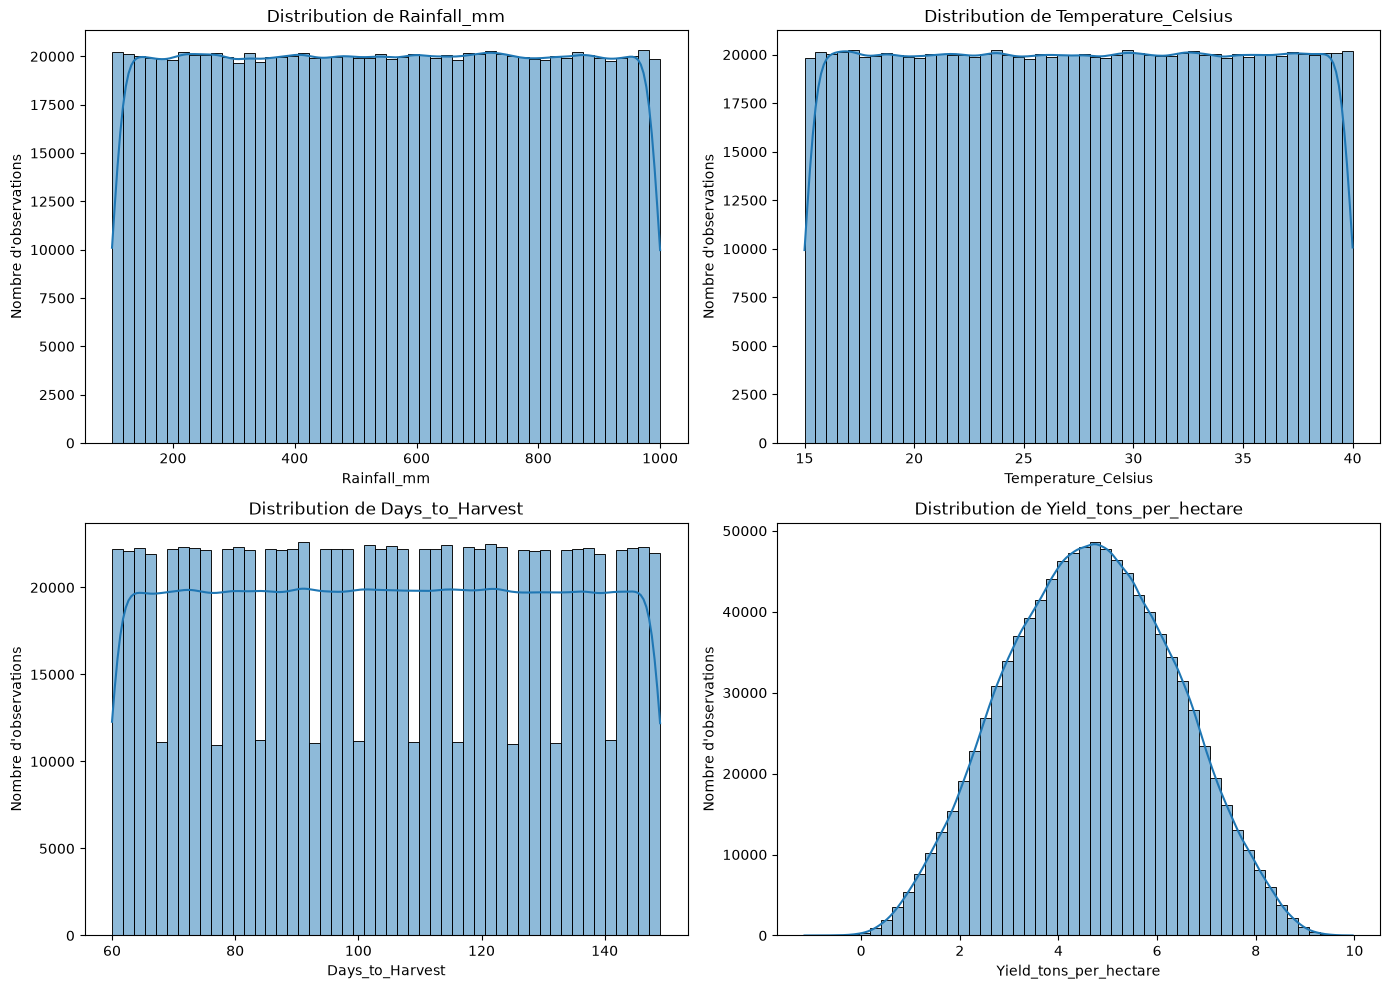

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), numeric_cols_crop):
    sns.histplot(
        data=crop_yield,
        x=col,
        bins=50,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

##### Conclusion

- `Rainfall_mm` est répartie de façon quasi uniforme entre **100 et 1 000 mm**.
- `Temperature_Celsius` est également quasi uniforme entre **15 et 40 °C**.
- `Days_to_Harvest` couvre **60 à 149 jours** avec une répartition globalement uniforme, malgré un effet visuel lié à son caractère discret.
- `Yield_tons_per_hectare` présente au contraire une distribution en cloche, centrée autour de **4,65 t/ha**.
- Les distributions très régulières des variables explicatives renforcent l'intérêt de vérifier plus tard si `crop_yield` est un jeu de données synthétique ou fortement simulé.

#### 4.1.3 Analyse des variables catégorielles


In [38]:
categorical_cols_crop = [
    "Region",
    "Soil_Type",
    "Crop",
    "Weather_Condition",
    "Fertilizer_Used",
    "Irrigation_Used"
]

for col in categorical_cols_crop:
    counts = crop_yield[col].value_counts()
    proportions = crop_yield[col].value_counts(normalize=True).mul(100)

    summary = pd.DataFrame({
        "count": counts,
        "percentage": proportions.round(2)
    })

    print(f"\n--- {col} ---")
    display(summary)


--- Region ---


,count,percentage
Region,,
North,250173,25.02
West,250074,25.01
South,250054,25.01
East,249699,24.97



--- Soil_Type ---


,count,percentage
Soil_Type,,
Sandy,167119,16.71
Loam,166795,16.68
Chalky,166779,16.68
Silt,166672,16.67
Clay,166352,16.64
Peaty,166283,16.63



--- Crop ---


...

,count,percentage
Weather_Condition,,
Sunny,333790,33.38
Rainy,333561,33.36
Cloudy,332649,33.26



--- Fertilizer_Used ---


,count,percentage
Fertilizer_Used,,
False,500060,50.01
True,499940,49.99



--- Irrigation_Used ---


,count,percentage
Irrigation_Used,,
False,500509,50.05
True,499491,49.95


##### Conclusion

- `Region` est quasiment équilibrée : environ **25 %** des observations par région.
- `Soil_Type` est quasiment équilibrée : environ **16,7 %** par type de sol.
- `Crop` est quasiment équilibrée : environ **16,7 %** par culture.
- `Weather_Condition` est quasiment équilibrée : environ **33,3 %** par condition météo.
- `Fertilizer_Used` et `Irrigation_Used` présentent une répartition proche de **50/50**.
- Aucune catégorie rare ou fortement sous-représentée n'est détectée.
- Cet équilibrage très régulier, combiné aux distributions numériques observées précédemment, renforce l'hypothèse d'un dataset synthétique ou fortement contrôlé.

#### 4.1.4 Analyse du rendement par culture


In [39]:
yield_by_crop = (
    crop_yield
    .groupby("Crop")["Yield_tons_per_hectare"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(yield_by_crop)

,count,mean,median,std,min,max
Crop,,,,,,
Soybean,166349,4.653712,4.657371,1.696774,-0.595955,9.677596
Wheat,166673,4.652740,4.655529,1.694823,-1.147613,9.802534
Cotton,166585,4.650841,4.650913,1.695367,-0.590388,9.786272
Rice,166792,4.650760,4.652837,1.698143,-0.468290,9.963372
Barley,166777,4.647412,4.650378,1.698294,-0.818945,9.949207
Maize,166824,4.641387,4.642647,1.696023,-0.875193,9.952983


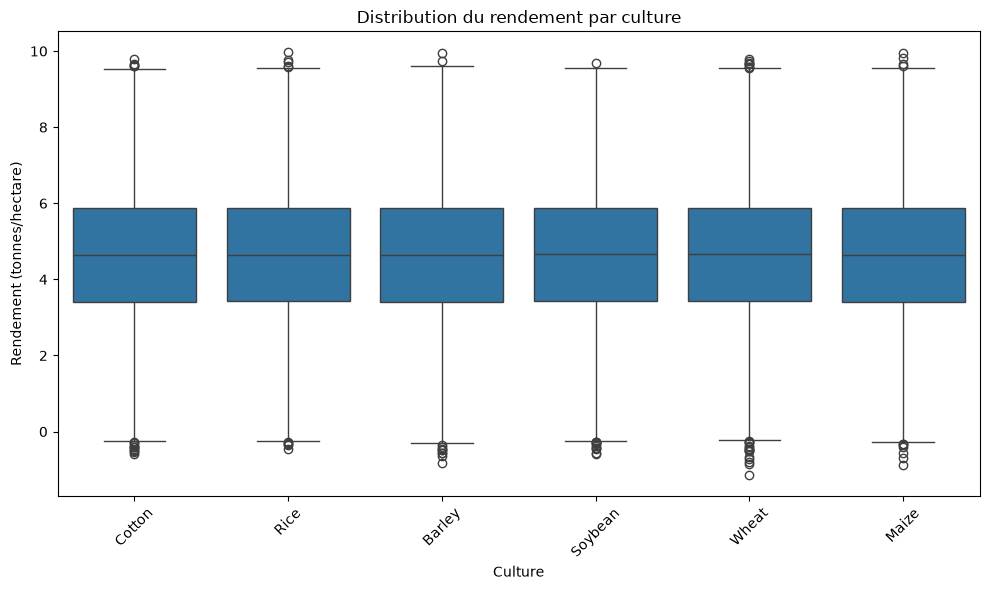

In [40]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=crop_yield,
    x="Crop",
    y="Yield_tons_per_hectare"
)

plt.title("Distribution du rendement par culture")
plt.xlabel("Culture")
plt.ylabel("Rendement (tonnes/hectare)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Conclusion

- Les rendements moyens sont très proches pour les six cultures (**≈ 4,64–4,65 t/ha**).
- Les médianes et dispersions sont également très similaires.
- Les distributions de rendement se chevauchent presque entièrement.
- La culture seule semble donc peu discriminante pour le rendement dans ce dataset.
- Des valeurs atypiques existent aux deux extrémités des distributions, notamment les rares rendements négatifs déjà identifiés.

##### 4.1.5.1 Corrélations entre variables numériques


,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
Rainfall_mm,1.000000,-0.000123,-0.002669,0.764618
Temperature_Celsius,-0.000123,1.000000,-0.000731,0.085565
Days_to_Harvest,-0.002669,-0.000731,1.000000,-0.002591
Yield_tons_per_hectare,0.764618,0.085565,-0.002591,1.000000


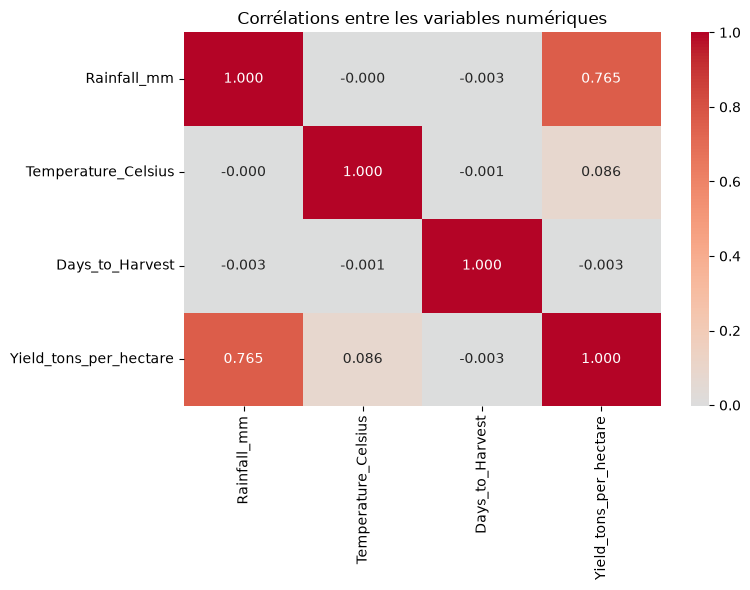

In [41]:
corr_cols = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest",
    "Yield_tons_per_hectare"
]

corr_matrix = crop_yield[corr_cols].corr()

display(corr_matrix)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Corrélations entre les variables numériques")
plt.tight_layout()
plt.show()

##### Conclusion

- `Rainfall_mm` présente une forte corrélation positive avec le rendement (**r = 0,765**).
- `Temperature_Celsius` présente une faible corrélation positive (**r = 0,086**).
- `Days_to_Harvest` ne présente pratiquement aucune corrélation linéaire avec le rendement (**r ≈ -0,003**).
- Les variables explicatives numériques sont quasiment non corrélées entre elles.
- `Rainfall_mm` apparaît comme la variable numérique la plus informative à ce stade.

##### 4.1.5.2 Rendement selon les variables catégorielles


In [42]:
categorical_effect_cols = [
    "Region",
    "Soil_Type",
    "Weather_Condition",
    "Fertilizer_Used",
    "Irrigation_Used"
]

for col in categorical_effect_cols:
    summary = (
        crop_yield
        .groupby(col)["Yield_tons_per_hectare"]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
    )

    print(f"\n--- Rendement selon {col} ---")
    display(summary)


--- Rendement selon Region ---


,count,mean,median,std
Region,,,,
North,250173,4.654114,4.659441,1.696369
West,250074,4.649331,4.651359,1.695569
South,250054,4.648843,4.646668,1.697191
East,249699,4.645594,4.649821,1.697160



--- Rendement selon Soil_Type ---


,count,mean,median,std
Soil_Type,,,,
Chalky,166779,4.652895,4.661322,1.699694
Peaty,166283,4.651063,4.655080,1.696084
Loam,166795,4.651056,4.648692,1.696445
Sandy,167119,4.648511,4.648330,1.695665
Silt,166672,4.648414,4.649454,1.696799
Clay,166352,4.644891,4.647424,1.694753



--- Rendement selon Weather_Condition ---


,count,mean,median,std
Weather_Condition,,,,
Sunny,333790,4.651919,4.654851,1.696837
Rainy,333561,4.649277,4.650815,1.696660
Cloudy,332649,4.647214,4.649913,1.696221



--- Rendement selon Fertilizer_Used ---


,count,mean,median,std
Fertilizer_Used,,,,
True,499940,5.399616,5.398603,1.522173
False,500060,3.899509,3.903824,1.521365



--- Rendement selon Irrigation_Used ---


,count,mean,median,std
Irrigation_Used,,,,
True,499491,5.250231,5.250169,1.585858
False,500509,4.049936,4.051524,1.587897


##### Conclusion

- `Fertilizer_Used` est fortement associé au rendement : **5,40 t/ha** avec fertilisation contre **3,90 t/ha** sans fertilisation.
- `Irrigation_Used` montre également un écart important : **5,25 t/ha** avec irrigation contre **4,05 t/ha** sans irrigation.
- `Region`, `Soil_Type` et `Weather_Condition` présentent des rendements moyens quasiment identiques entre leurs modalités.
- La fertilisation et l'irrigation apparaissent donc comme les variables catégorielles les plus informatives à ce stade.
- Ces résultats décrivent des associations et ne démontrent pas de relation causale.

#### 4.1.6 Synthèse de l'analyse de `crop_yield`

- Dataset très volumineux (**1 000 000 d'observations**) et sans valeurs manquantes.
- Les variables numériques explicatives présentent des distributions très régulières et globalement symétriques.
- La cible `Yield_tons_per_hectare` est centrée autour de **4,65 t/ha**.
- **231 rendements négatifs (0,0231 %)** ont été détectés et devront être traités lors du nettoyage.
- `Rainfall_mm` présente la relation linéaire la plus forte avec le rendement (**r = 0,765**).
- `Fertilizer_Used` et `Irrigation_Used` sont associés à des différences importantes de rendement.
- `Crop`, `Region`, `Soil_Type`, `Weather_Condition` et `Days_to_Harvest` montrent peu de pouvoir discriminant lorsqu'ils sont étudiés isolément.
- L'équilibre presque parfait des catégories et les distributions très régulières suggèrent un dataset potentiellement synthétique ou fortement contrôlé.
- Les relations entre variables devront être confirmées lors de la modélisation, notamment pour détecter d'éventuelles interactions ou relations non linéaires.

### 4.2 Analyse pesticides dataset

#### 4.2.1 Distribution de l'utilisation des pesticides

In [46]:
display(pesticides["Value"].describe())

print("Skewness :", pesticides["Value"].skew())
print("Minimum :", pesticides["Value"].min())
print("Maximum :", pesticides["Value"].max())
print("Nombre de valeurs égales à 0 :", (pesticides["Value"] == 0).sum())

count    4.349000e+03
mean     2.030334e+04
std      1.177362e+05
min      0.000000e+00
25%      9.300000e+01
50%      1.137560e+03
75%      7.869000e+03
max      1.807000e+06
Name: Value, dtype: float64

Skewness : 11.585833899822068
Minimum : 0.0
Maximum : 1807000.0
Nombre de valeurs égales à 0 : 2


In [44]:
print("Valeur minimale :", pesticides["Value"].min())
print("Valeur maximale :", pesticides["Value"].max())
print("Nombre de valeurs égales à 0 :", (pesticides["Value"] == 0).sum())

Valeur minimale : 0.0
Valeur maximale : 1807000.0
Nombre de valeurs égales à 0 : 2


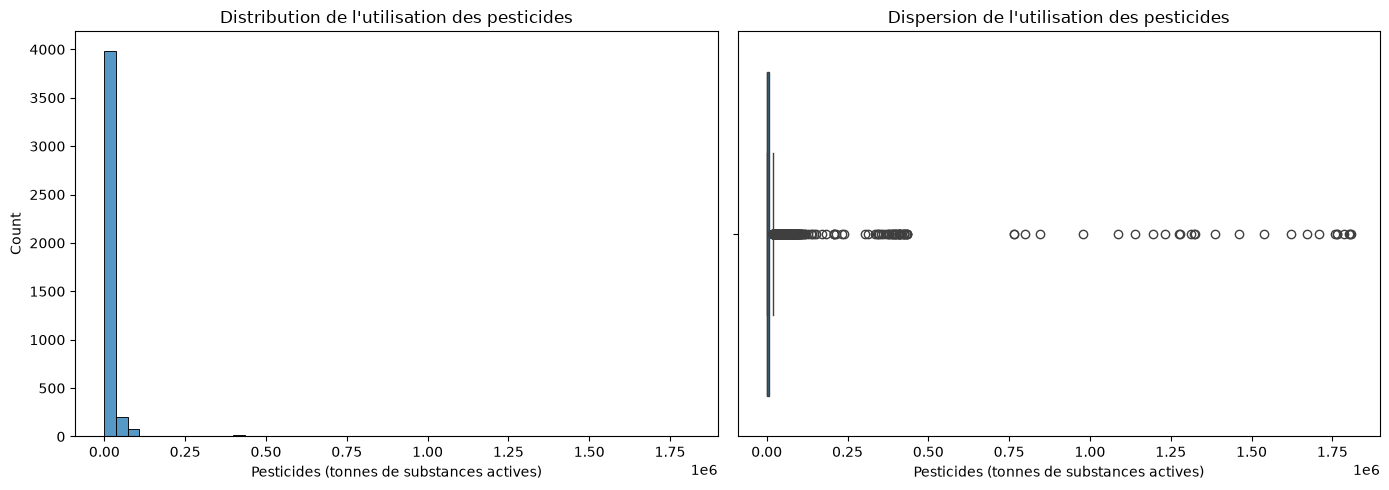

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=pesticides,
    x="Value",
    bins=50,
    ax=axes[0]
)
axes[0].set_title("Distribution de l'utilisation des pesticides")
axes[0].set_xlabel("Pesticides (tonnes de substances actives)")

sns.boxplot(
    data=pesticides,
    x="Value",
    ax=axes[1]
)
axes[1].set_title("Dispersion de l'utilisation des pesticides")
axes[1].set_xlabel("Pesticides (tonnes de substances actives)")

plt.tight_layout()
plt.show()

##### Conclusion

- `Value` est très fortement asymétrique à droite (**skewness = 11,59**).
- La médiane (**1 138 t**) est très inférieure à la moyenne (**20 303 t**).
- Quelques valeurs très élevées atteignent jusqu'à **1 807 000 t**.
- Seulement **2 observations** ont une valeur nulle.
- Les valeurs extrêmes ne seront pas supprimées automatiquement : `Value` représente un total annuel par zone géographique.
- Une transformation logarithmique pourra être étudiée lors de la préparation des données.

#### 4.2.2 Évolution temporelle de l'utilisation des pesticides


In [47]:
pesticides_yearly = (
    pesticides
    .groupby("Year")["Value"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

display(pesticides_yearly)

,Year,mean,median,count
0,1990,16101.315874,909.000,143
1,1991,15921.229930,909.000,143
2,1992,14824.490253,1108.780,158
3,1993,14829.531296,985.500,162
4,1994,15817.389506,926.500,162
5,1995,16742.965988,911.070,162
6,1996,17459.714506,966.000,162
7,1997,18138.136420,918.855,162
8,1998,18456.678457,1103.085,162
9,1999,19096.923642,1003.775,162


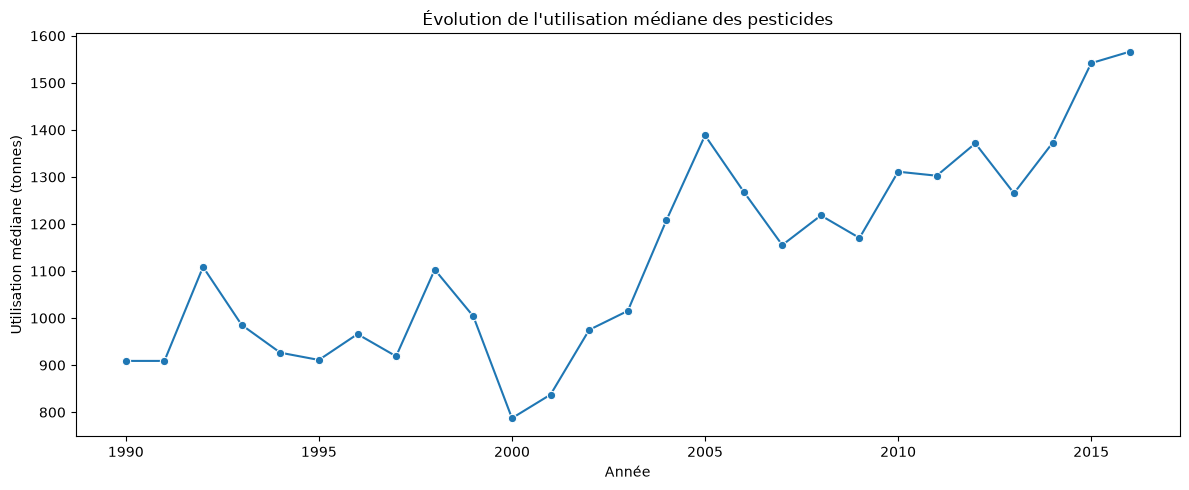

In [ ]:
# Visualisation de l'évolution de l'utilisation médiane (plus robuste aux extrêmes) des pesticides au fil des années 
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=pesticides_yearly,
    x="Year",
    y="median",
    marker="o"
)

plt.title("Évolution de l'utilisation médiane des pesticides")
plt.xlabel("Année")
plt.ylabel("Utilisation médiane (tonnes)")
plt.tight_layout()
plt.show()

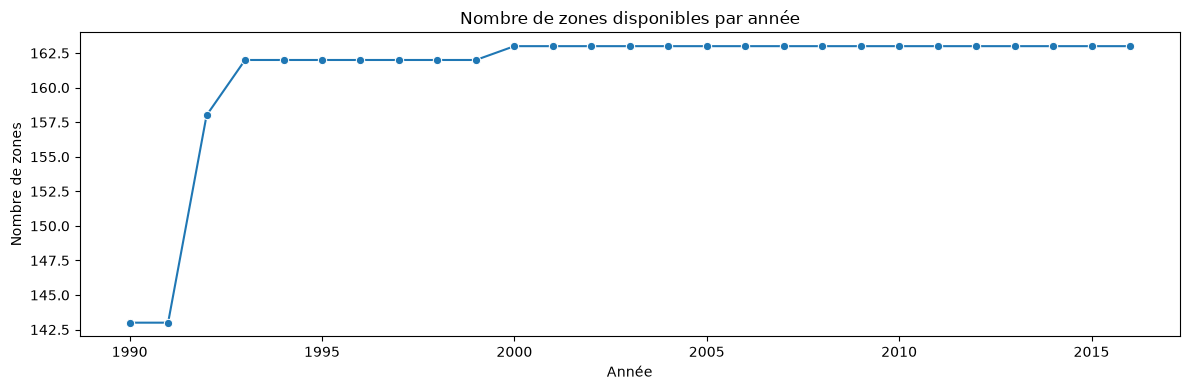

In [ ]:
# Visualisation du nombre de zones utilisant les pesticides et dont on a des données par année 
plt.figure(figsize=(12, 4))

sns.lineplot(
    data=pesticides_yearly,
    x="Year",
    y="count",
    marker="o"
)

plt.title("Nombre de zones disponibles par année")
plt.xlabel("Année")
plt.ylabel("Nombre de zones")
plt.tight_layout()
plt.show()

##### Conclusion

- L'utilisation médiane des pesticides présente une tendance globale à la hausse, malgré des fluctuations annuelles.
- Elle passe de **909 t en 1990** à **1 566 t en 2016**.
- La moyenne reste nettement supérieure à la médiane, confirmant l'influence des valeurs très élevées.
- La couverture passe de **143 zones en 1990-1991** à **163 zones à partir de 2000**.
- La tendance observée après 2000 ne s'explique donc pas par une variation du nombre de zones disponibles.

#### 4.2.3 Synthèse de l'analyse de `pesticides`

- Le dataset possède une granularité unique **`Area × Year`**, adaptée à une jointure annuelle.
- `Value` correspond à l'utilisation totale de pesticides en **tonnes de substances actives**.
- Sa distribution est très asymétrique (**skewness = 11,59**) et comporte des valeurs très élevées.
- Les valeurs extrêmes ne seront pas supprimées automatiquement, car elles peuvent refléter des différences réelles entre zones géographiques.
- L'utilisation médiane présente une tendance globale à la hausse sur la période étudiée.
- Une transformation logarithmique de `Value` pourra être évaluée lors du preprocessing.
- Après fusion avec des données par culture, une même valeur annuelle de pesticides sera répétée pour toutes les cultures d'une zone : elle ne devra pas être interprétée comme une consommation spécifique à chaque culture.

### 4.3 Analyse rainfall dataset

#### 4.3.1 Diagnostic de la variable de précipitations


In [51]:
rainfall_col = "average_rain_fall_mm_per_year"

rainfall_numeric = pd.to_numeric(
    rainfall[rainfall_col],
    errors="coerce"
)

original_missing = rainfall[rainfall_col].isna()
conversion_missing = rainfall_numeric.isna()

print("Nombre total de lignes :", len(rainfall))
print("Valeurs manquantes d'origine :", original_missing.sum())
print("Valeurs non convertibles supplémentaires :",
      (conversion_missing & ~original_missing).sum())
print("Total non exploitable numériquement :", conversion_missing.sum())
print(
    "Proportion non exploitable :",
    f"{conversion_missing.mean() * 100:.2f} %"
)

Nombre total de lignes : 6727
Valeurs manquantes d'origine : 774
Valeurs non convertibles supplémentaires : 6
Total non exploitable numériquement : 780
Proportion non exploitable : 11.60 %


In [52]:
non_numeric_values = (
    rainfall.loc[
        conversion_missing & ~original_missing,
        rainfall_col
    ]
    .value_counts(dropna=False)
)

display(non_numeric_values)

average_rain_fall_mm_per_year
..    6
Name: count, dtype: int64

In [53]:
display(
    rainfall.loc[
        conversion_missing,
        [" Area", "Year", rainfall_col]
    ].head(20)
)

,Area,Year,average_rain_fall_mm_per_year
93,American Samoa,1985,NaN
94,American Samoa,1986,NaN
95,American Samoa,1987,NaN
96,American Samoa,1989,NaN
97,American Samoa,1990,NaN
98,American Samoa,1991,NaN
99,American Samoa,1992,NaN
100,American Samoa,1993,NaN
101,American Samoa,1994,NaN
102,American Samoa,1995,NaN


##### Conclusion

- `average_rain_fall_mm_per_year` contient **774 valeurs manquantes** et **6 valeurs `".."`**.
- Au total, **780 observations (11,60 %)** ne sont pas exploitables numériquement.
- Le marqueur `".."` devra être converti en valeur manquante lors du nettoyage.
- La proportion de données indisponibles est importante et nécessite d'étudier leur répartition avant toute suppression.

#### 4.3.2 Répartition des valeurs non exploitables


In [ ]:
#Répartition des valeurs manquantes par zone

missing_by_area = (
    rainfall
    .assign(rainfall_missing=conversion_missing)
    .groupby(" Area")
    .agg(
        total=("rainfall_missing", "size"),
        missing=("rainfall_missing", "sum")
    )
)

missing_by_area["missing_pct"] = (
    missing_by_area["missing"] / missing_by_area["total"] * 100
)

display(
    missing_by_area[
        missing_by_area["missing"] > 0
    ]
    .sort_values(["missing_pct", "missing"], ascending=False)
    .head(20)
)

,total,missing,missing_pct
Area,,,
American Samoa,31,31,100.0
Aruba,31,31,100.0
Bermuda,31,31,100.0
British Virgin Islands,31,31,100.0
Cayman Islands,31,31,100.0
Channel Islands,31,31,100.0
Curacao,31,31,100.0
Faroe Islands,31,31,100.0
French Polynesia,31,31,100.0


In [ ]:
#répartition des valeurs manquantes par année

missing_by_year = (
    rainfall
    .assign(rainfall_missing=conversion_missing)
    .groupby("Year")
    .agg(
        total=("rainfall_missing", "size"),
        missing=("rainfall_missing", "sum")
    )
)

missing_by_year["missing_pct"] = (
    missing_by_year["missing"] / missing_by_year["total"] * 100
)

display(missing_by_year)

,total,missing,missing_pct
Year,,,
1985,217,26,11.981567
1986,217,26,11.981567
1987,217,25,11.520737
1989,217,26,11.981567
1990,217,26,11.981567
1991,217,26,11.981567
1992,217,25,11.520737
1993,217,25,11.520737
1994,217,25,11.520737


In [56]:
print(
    "Zones avec au moins une valeur non exploitable :",
    (missing_by_area["missing"] > 0).sum()
)

print(
    "Zones avec 100 % de valeurs non exploitables :",
    (missing_by_area["missing_pct"] == 100).sum()
)

Zones avec au moins une valeur non exploitable : 26
Zones avec 100 % de valeurs non exploitables : 25


##### Conclusion

- Environ **25 à 26 zones** ont une précipitation non exploitable chaque année.
- Plusieurs zones présentent **100 % de valeurs manquantes** sur leur historique.
- Les données manquantes sont donc principalement structurées par **zone géographique**, plutôt que concentrées sur une période particulière.
- La couverture reste stable à **217 zones par année**.
- Une interpolation temporelle ne pourra pas résoudre le cas des zones entièrement dépourvues de données.

#### 4.3.3 Distribution des précipitations exploitables


In [57]:
valid_rainfall = rainfall_numeric.dropna()

display(valid_rainfall.describe())

print("Skewness :", round(valid_rainfall.skew(), 3))

count    5947.000000
mean     1124.743232
std       786.257365
min        51.000000
25%       534.000000
50%      1010.000000
75%      1651.000000
max      3240.000000
Name: average_rain_fall_mm_per_year, dtype: float64

Skewness : 0.697


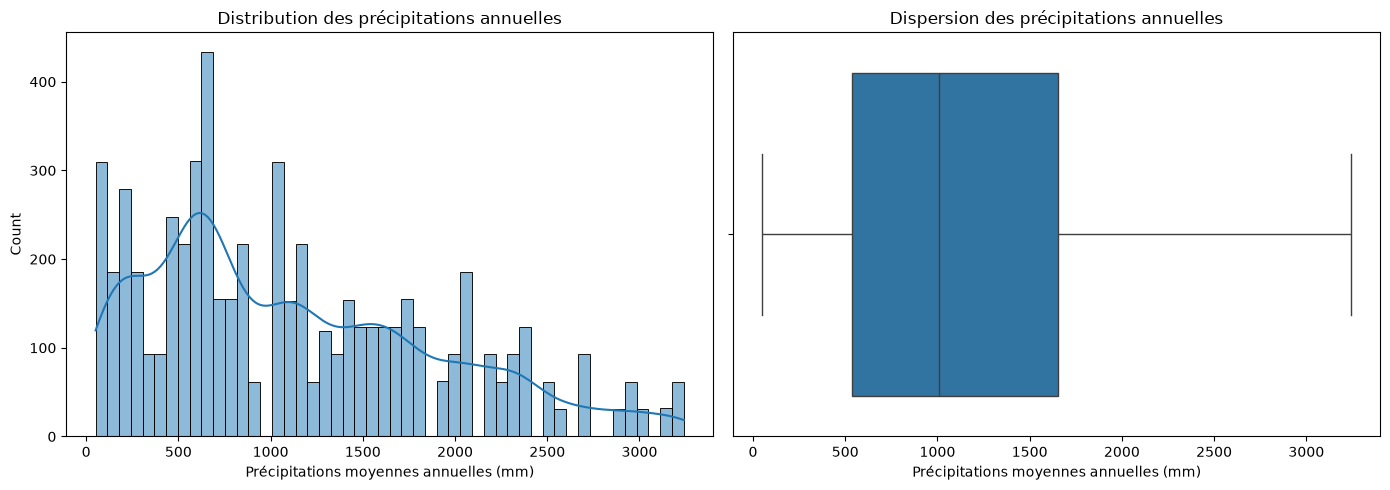

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    valid_rainfall,
    bins=50,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribution des précipitations annuelles")
axes[0].set_xlabel("Précipitations moyennes annuelles (mm)")

sns.boxplot(
    x=valid_rainfall,
    ax=axes[1]
)
axes[1].set_title("Dispersion des précipitations annuelles")
axes[1].set_xlabel("Précipitations moyennes annuelles (mm)")

plt.tight_layout()
plt.show()

##### Conclusion

- **5 947 observations** disposent d'une valeur de précipitations exploitable.
- Les précipitations varient de **51 à 3 240 mm/an**, avec une médiane de **1 010 mm/an**.
- La moyenne (**1 125 mm/an**) est légèrement supérieure à la médiane.
- La distribution est irrégulière et davantage étendue vers les fortes précipitations.
- Aucune valeur ne sera considérée comme aberrante uniquement sur la base de son niveau de précipitations.

#### 4.3.4 Synthèse de l'analyse de `rainfall`

- La granularité **`Area × Year`** est unique et adaptée à une jointure annuelle.
- **780 observations (11,60 %)** ne sont pas exploitables : 774 valeurs manquantes et 6 marqueurs `".."`.
- **26 zones** sont concernées, dont **25 entièrement dépourvues de données exploitables**.
- Les valeurs manquantes sont principalement structurées par zone géographique.
- Les **5 947 valeurs exploitables** couvrent une plage de **51 à 3 240 mm/an**.
- La colonne `" Area"` devra être renommée et les précipitations converties en type numérique.
- Le traitement des valeurs manquantes devra tenir compte des zones sans aucun historique disponible.

### 4.4 Analyse temp dataset

#### 4.4.1 Distribution des températures


In [60]:
valid_temp = temp["avg_temp"].dropna()

display(valid_temp.describe())

print("Skewness :", round(valid_temp.skew(), 3))

count    68764.000000
mean        16.183876
std          7.592960
min        -14.350000
25%          9.750000
50%         16.140000
75%         23.762500
max         30.730000
Name: avg_temp, dtype: float64

Skewness : -0.154


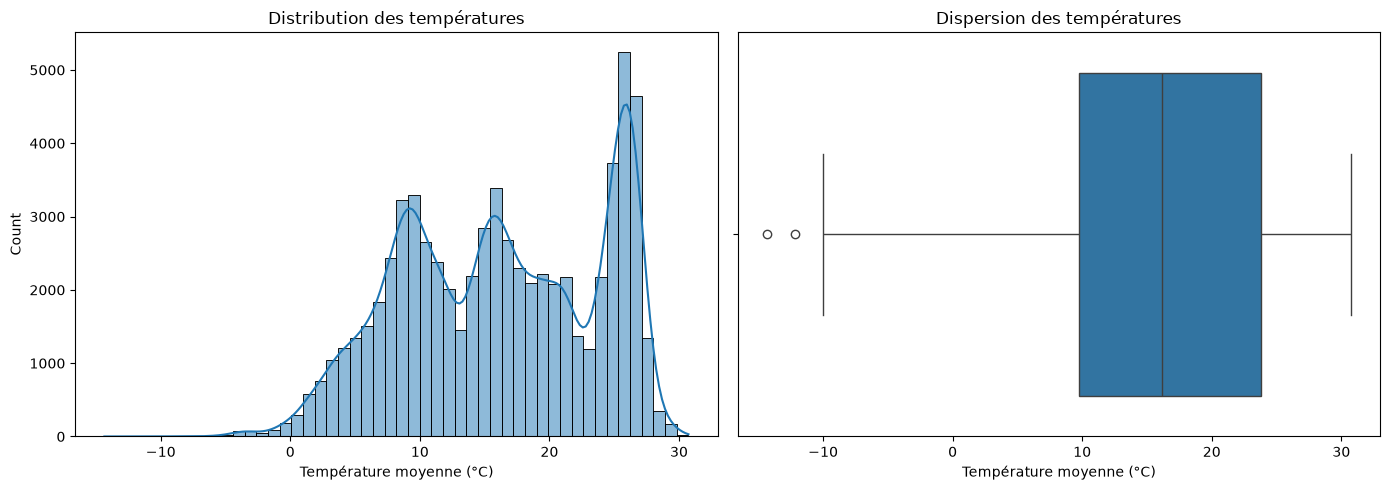

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    valid_temp,
    bins=50,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribution des températures")
axes[0].set_xlabel("Température moyenne (°C)")

sns.boxplot(
    x=valid_temp,
    ax=axes[1]
)
axes[1].set_title("Dispersion des températures")
axes[1].set_xlabel("Température moyenne (°C)")

plt.tight_layout()
plt.show()


##### Conclusion

- **68 764 températures** sont exploitables sur 71 311 observations.
- La température moyenne est de **16,18 °C**, très proche de la médiane (**16,14 °C**).
- Les valeurs s'étendent de **-14,35 °C à 30,73 °C**.
- La distribution est **multimodale**, avec plusieurs concentrations de températures.
- Quelques températures très basses apparaissent comme atypiques au boxplot, sans être nécessairement erronées.
- Aucune valeur extrême ne sera supprimée à ce stade.

#### 4.4.2 Analyse des doublons et de la granularité


In [62]:
temp_no_exact_duplicates = temp.drop_duplicates()

print("Nombre de lignes initial :", len(temp))
print("Doublons exacts supprimables :", temp.duplicated().sum())
print(
    "Nombre de lignes après dédoublonnage :",
    len(temp_no_exact_duplicates)
)

Nombre de lignes initial : 71311
Doublons exacts supprimables : 6958
Nombre de lignes après dédoublonnage : 64353


In [63]:
temp_country_year_counts = (
    temp_no_exact_duplicates
    .groupby(["country", "year"])
    .size()
)

print(
    "Nombre de couples (country, year) :",
    len(temp_country_year_counts)
)

print(
    "Couples ayant plusieurs observations :",
    (temp_country_year_counts > 1).sum()
)

print(
    "Proportion avec plusieurs observations :",
    f"{(temp_country_year_counts > 1).mean() * 100:.2f} %"
)

print(
    "Nombre maximal d'observations pour une clé :",
    temp_country_year_counts.max()
)

Nombre de couples (country, year) : 28514
Couples ayant plusieurs observations : 7625
Proportion avec plusieurs observations : 26.74 %
Nombre maximal d'observations pour une clé : 41


In [64]:
temp_unique_values = (
    temp_no_exact_duplicates
    .groupby(["country", "year"])["avg_temp"]
    .nunique(dropna=True)
)

print(
    "Couples avec plusieurs températures distinctes :",
    (temp_unique_values > 1).sum()
)

print(
    "Maximum de températures distinctes pour une clé :",
    temp_unique_values.max()
)

Couples avec plusieurs températures distinctes : 7534
Maximum de températures distinctes pour une clé : 41


##### Conclusion

- `temp` contient **6 958 doublons exacts**, soit des lignes potentiellement supprimables lors du nettoyage.
- Après dédoublonnage, **64 353 observations** subsistent.
- **7 625 couples (`country`, `year`)**, soit **26,74 %**, possèdent encore plusieurs observations.
- **7 534 couples** contiennent plusieurs températures réellement distinctes.
- Une clé peut contenir jusqu'à **41 températures distinctes** après dédoublonnage.
- La suppression des doublons ne suffit donc pas : une agrégation par (`country`, `year`) sera nécessaire avant la fusion.

#### 4.4.3 Préparation de l'agrégation annuelle


In [65]:
temp_annual = (
    temp_no_exact_duplicates
    .groupby(["country", "year"], as_index=False)
    .agg(
        avg_temp=("avg_temp", "mean"),
        n_observations=("avg_temp", "count")
    )
)

print("Dimensions :", temp_annual.shape)

print(
    "Doublons sur (country, year) :",
    temp_annual.duplicated(["country", "year"]).sum()
)

print(
    "Valeurs manquantes de avg_temp :",
    temp_annual["avg_temp"].isna().sum()
)

display(temp_annual.head())

Dimensions : (28514, 4)
Doublons sur (country, year) : 0
Valeurs manquantes de avg_temp : 1035


,country,year,avg_temp,n_observations
0,Afghanistan,1833,13.91,1
1,Afghanistan,1834,13.91,1
2,Afghanistan,1835,14.71,1
3,Afghanistan,1836,NaN,0
4,Afghanistan,1837,15.47,1


In [66]:
temp_annual_missing = temp_annual[
    temp_annual["avg_temp"].isna()
]

print(
    "Couples (country, year) sans température exploitable :",
    len(temp_annual_missing)
)

display(temp_annual_missing.head(10))

Couples (country, year) sans température exploitable : 1035


,country,year,avg_temp,n_observations
3,Afghanistan,1836,NaN,0
6,Afghanistan,1839,NaN,0
184,Albania,1746,NaN,0
185,Albania,1747,NaN,0
186,Albania,1748,NaN,0
187,Albania,1749,NaN,0
720,Angola,1863,NaN,0
721,Angola,1864,NaN,0
722,Angola,1865,NaN,0
723,Angola,1866,NaN,0


In [67]:
display(temp_annual["avg_temp"].describe())

count    27479.000000
mean        16.240719
std          7.959802
min        -12.130000
25%          9.075000
50%         16.250000
75%         24.510000
max         30.420000
Name: avg_temp, dtype: float64

##### Conclusion

- L'agrégation produit **28 514 couples (`country`, `year`) uniques**, sans doublon.
- **27 479 couples** disposent d'une température annuelle exploitable.
- **1 035 couples** restent sans température exploitable après agrégation.
- La température annuelle médiane est de **16,25 °C**, pour une moyenne de **16,24 °C**.
- L'agrégation par moyenne permet d'obtenir la granularité nécessaire à la future fusion.
- Le traitement des **1 035 températures annuelles manquantes** sera décidé lors du nettoyage.

#### 4.4.4 Synthèse de l'analyse de `temp`

- `temp` contient **71 311 observations**, dont **2 547 températures manquantes**.
- **6 958 doublons exacts** ont été identifiés.
- Après dédoublonnage, **26,74 %** des couples (`country`, `year`) possèdent encore plusieurs observations.
- **7 534 couples** contiennent plusieurs températures distinctes : un simple dédoublonnage ne suffit donc pas.
- Une agrégation par moyenne permet d'obtenir **28 514 couples (`country`, `year`) uniques**.
- Après agrégation, **1 035 couples** restent sans température exploitable.
- La version annuelle agrégée devra être utilisée pour éviter une multiplication des lignes lors de la fusion.

### 4.5 Analyse yield_df dataset

#### 4.5.1 Distribution du rendement


In [68]:
display(yield_data["Value"].describe())

print(
    "Skewness :",
    round(yield_data["Value"].skew(), 3)
)

print(
    "Rendements égaux à 0 :",
    (yield_data["Value"] == 0).sum()
)

count      56717.000000
mean       62094.660084
std        67835.932856
min            0.000000
25%        15680.000000
50%        36744.000000
75%        86213.000000
max      1000000.000000
Name: Value, dtype: float64

Skewness : 2.205
Rendements égaux à 0 : 8


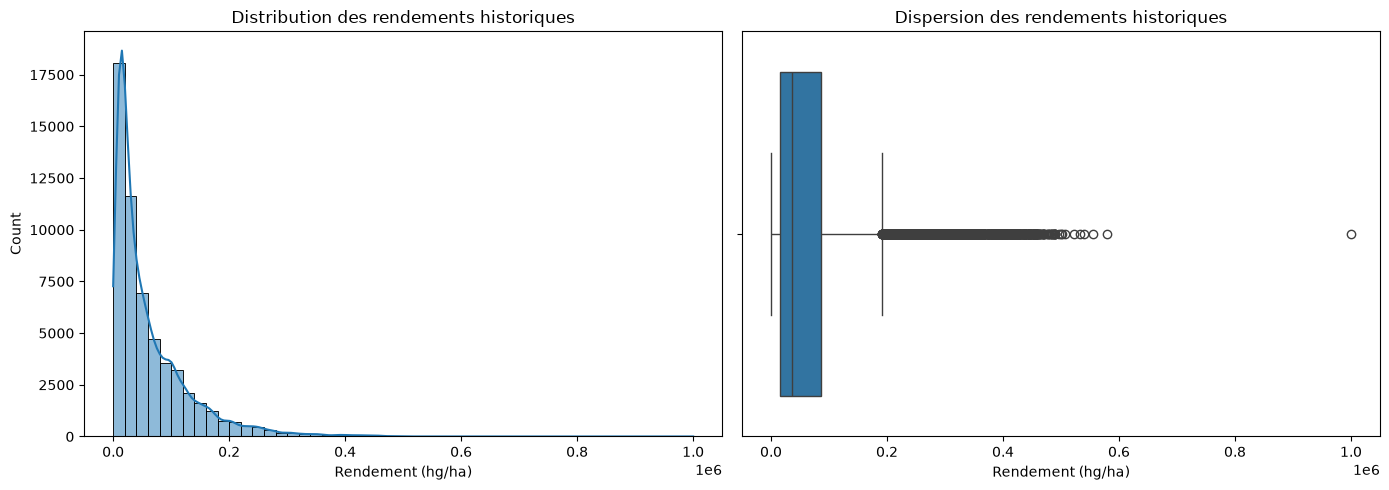

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=yield_data,
    x="Value",
    bins=50,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Distribution des rendements historiques")
axes[0].set_xlabel("Rendement (hg/ha)")

sns.boxplot(
    data=yield_data,
    x="Value",
    ax=axes[1]
)
axes[1].set_title("Dispersion des rendements historiques")
axes[1].set_xlabel("Rendement (hg/ha)")

plt.tight_layout()
plt.show()

##### Conclusion

- Le rendement est fortement asymétrique à droite (**skewness = 2,205**).
- La médiane est de **36 744 hg/ha**, contre une moyenne de **62 095 hg/ha**.
- Des rendements très élevés atteignent jusqu'à **1 000 000 hg/ha**.
- Seulement **8 observations** présentent un rendement nul.
- Les valeurs élevées ne seront pas supprimées automatiquement : elles peuvent notamment dépendre du type de culture.
- L'unité `hg/ha` sera harmonisée lors du preprocessing.

#### 4.5.2 Rendement selon la culture


In [70]:
yield_by_item = (
    yield_data
    .groupby("Item")["Value"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("median", ascending=False)
)

display(yield_by_item)

,count,mean,median,std,min,max
Item,,,,,,
Potatoes,7876,150083.237176,130427.5,92303.929631,8052,540003
Cassava,5718,92768.762854,85612.5,51785.547430,10000,385818
Yams,3150,80903.501587,74534.0,43568.013316,1367,333333
Sweet potatoes,6356,89885.121460,71429.0,65644.130266,2000,400000
Plantains and others,2654,86282.765637,71226.5,65498.765715,286,1000000
"Rice, paddy",6469,30239.233112,26271.0,17775.859868,2034,106827
Wheat,6160,24607.424351,19999.0,17433.159224,0,106677
Maize,8631,29360.009616,17393.0,31941.629349,343,404127
Soybeans,4192,14162.731632,12993.0,7454.863365,50,59470


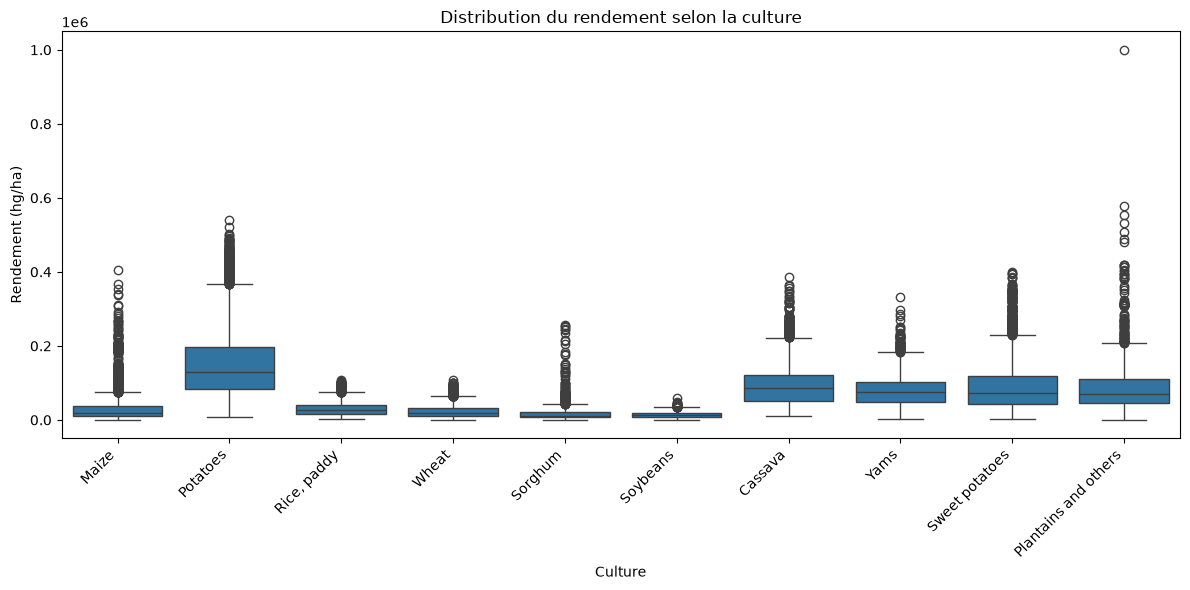

In [71]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=yield_data,
    x="Item",
    y="Value"
)

plt.title("Distribution du rendement selon la culture")
plt.xlabel("Culture")
plt.ylabel("Rendement (hg/ha)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

##### Conclusion

- Les rendements diffèrent fortement selon les cultures.
- `Potatoes` présente la médiane la plus élevée (**130 428 hg/ha**), contre **11 411 hg/ha** pour `Sorghum`.
- `Cassava`, `Yams`, `Sweet potatoes` et `Plantains and others` présentent également des rendements médians relativement élevés.
- Le mélange de cultures aux rendements très différents explique une partie de la forte dispersion du rendement global.
- Une valeur maximale de **1 000 000 hg/ha** est observée pour `Plantains and others` et devra être contrôlée lors du nettoyage.
- `Item` apparaît comme une variable importante à conserver pour la future modélisation.

#### 4.5.3 Évolution temporelle du rendement

,Year,median,mean,count
0,1961,26403.5,46822.252735,914
1,1962,26146.5,47316.997812,914
2,1963,26654.5,48312.522976,914
3,1964,27040.5,49877.831510,914
4,1965,27397.5,49153.838074,914
5,1966,28013.0,50023.635473,919
6,1967,29637.0,50983.318478,920
7,1968,30438.5,50928.275974,924
8,1969,30487.0,50923.134054,925
9,1970,30909.0,51770.272336,929


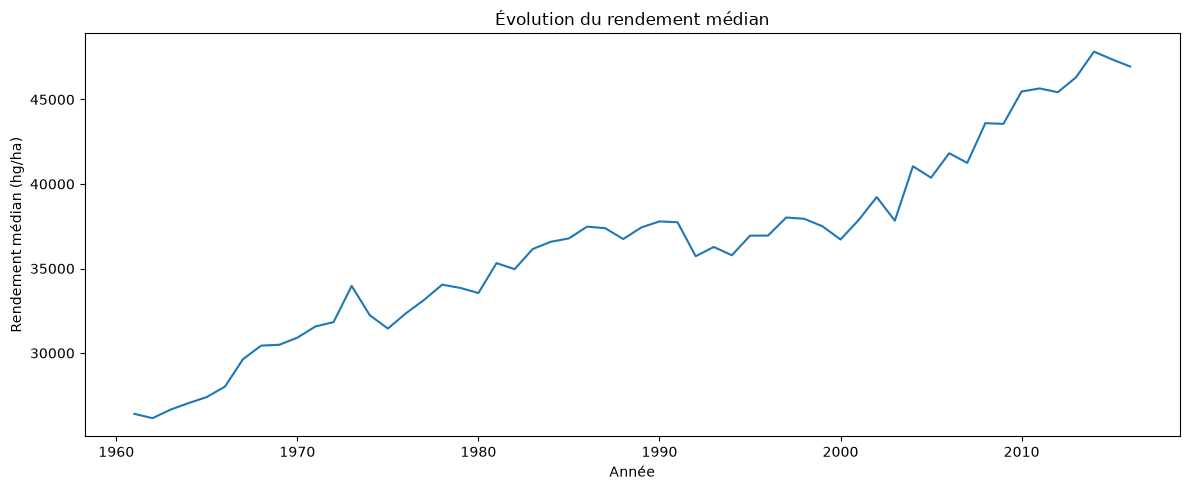

In [72]:
yield_yearly = (
    yield_data
    .groupby("Year")["Value"]
    .agg(["median", "mean", "count"])
    .reset_index()
)

display(yield_yearly)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=yield_yearly,
    x="Year",
    y="median"
)

plt.title("Évolution du rendement médian")
plt.xlabel("Année")
plt.ylabel("Rendement médian (hg/ha)")
plt.tight_layout()
plt.show()

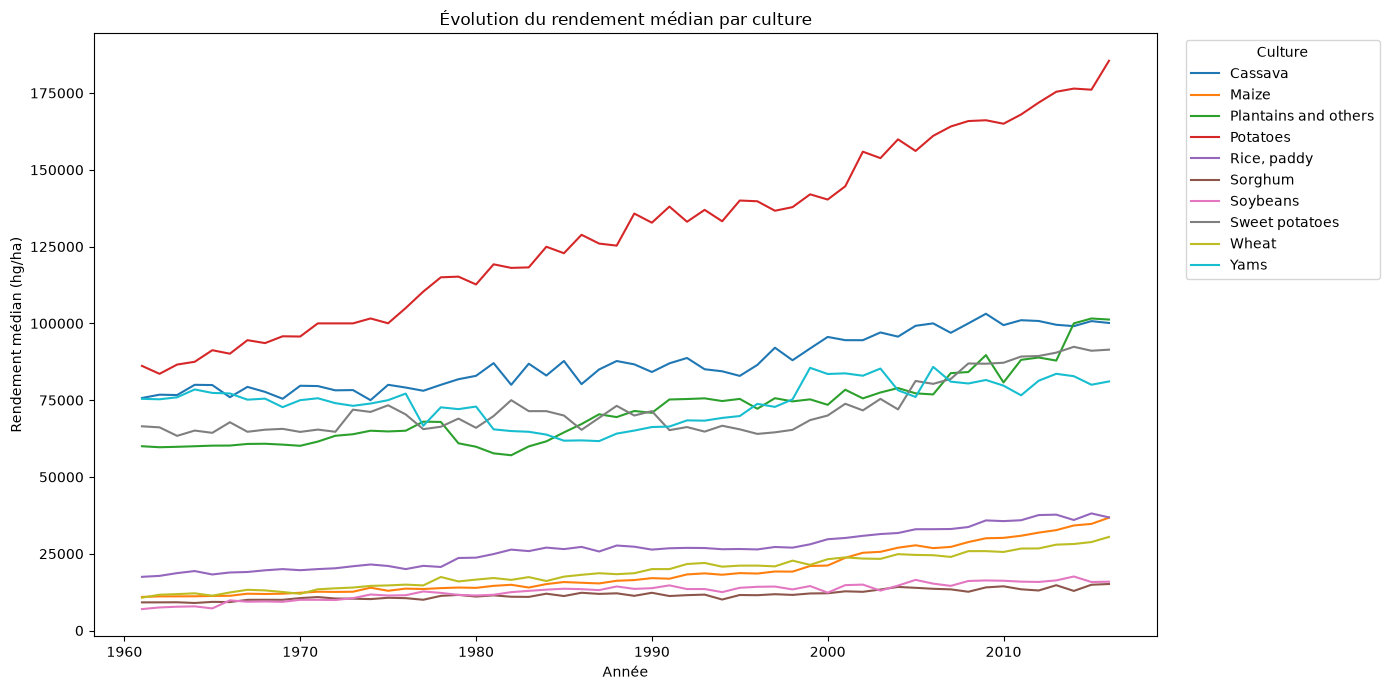

In [73]:
yield_yearly_crop = (
    yield_data
    .groupby(["Year", "Item"], as_index=False)["Value"]
    .median()
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=yield_yearly_crop,
    x="Year",
    y="Value",
    hue="Item"
)

plt.title("Évolution du rendement médian par culture")
plt.xlabel("Année")
plt.ylabel("Rendement médian (hg/ha)")
plt.legend(
    title="Culture",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

In [ ]:
#vérification que l'évolution du rendement médian par culture n'est pas lié à une variation du nombre d'observations par année
display(yield_yearly.head())
display(yield_yearly.tail())

print(
    "Nombre minimal d'observations par année :",
    yield_yearly["count"].min()
)

print(
    "Nombre maximal d'observations par année :",
    yield_yearly["count"].max()
)

,Year,median,mean,count
0,1961,26403.5,46822.252735,914
1,1962,26146.5,47316.997812,914
2,1963,26654.5,48312.522976,914
3,1964,27040.5,49877.831510,914
4,1965,27397.5,49153.838074,914


,Year,median,mean,count
51,2012,45428.0,76287.178058,1112
52,2013,46303.0,78003.250225,1111
53,2014,47828.5,79039.082130,1108
54,2015,47371.5,78126.717509,1108
55,2016,46947.0,79146.269127,1111


Nombre minimal d'observations par année : 914
Nombre maximal d'observations par année : 1112


##### Conclusion

- Le rendement médian global présente une **tendance haussière nette** entre 1961 et 2016.
- Cette progression est visible pour la majorité des cultures, avec des amplitudes différentes.
- `Potatoes` présente notamment une hausse particulièrement marquée.
- La couverture annuelle reste relativement stable, entre **914 et 1 112 observations**.
- `Year` pourrait apporter une information prédictive, mais son effet devra être distingué de ceux de la culture et de la composition géographique.

#### 4.5.4 Synthèse de l'analyse de `yield_data`

- La granularité **`Area × Item × Year`** est unique et adaptée à la future fusion.
- Le rendement est fortement asymétrique à droite (**skewness = 2,205**).
- Les rendements diffèrent fortement selon les cultures : `Item` constitue une variable explicative importante.
- Le rendement médian présente une **tendance globale à la hausse** entre 1961 et 2016.
- La couverture annuelle reste relativement stable, entre **914 et 1 112 observations**.
- Seulement **8 rendements nuls** sont présents ; les valeurs très élevées devront être contrôlées sans suppression automatique.
- L'unité `hg/ha` devra être harmonisée avec les autres sources lors du preprocessing.
- Les cultures devront également être harmonisées avec `crop_yield` avant toute comparaison ou fusion.

### 4.6 Analyse yield dataset

#### 4.6.1 Analyse des clés répétées


In [75]:
duplicated_keys_df = yield_df[
    yield_df.duplicated(
        ["Area", "Item", "Year"],
        keep=False
    )
].copy()

print(
    "Lignes appartenant à une clé répétée :",
    len(duplicated_keys_df)
)

print(
    "Nombre de clés répétées :",
    duplicated_keys_df[
        ["Area", "Item", "Year"]
    ].drop_duplicates().shape[0]
)

Lignes appartenant à une clé répétée : 18949
Nombre de clés répétées : 3837


In [ ]:
#variation des valeurs pour les clés répétées
variation_within_keys = (
    duplicated_keys_df
    .groupby(["Area", "Item", "Year"])
    .agg({
        "hg/ha_yield": "nunique",
        "average_rain_fall_mm_per_year": "nunique",
        "pesticides_tonnes": "nunique",
        "avg_temp": "nunique"
    })
)

display(variation_within_keys.describe())

,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,3837.0,3837.0,3837.0,3837.000000
mean,1.0,1.0,1.0,4.336461
std,0.0,0.0,0.0,3.797968
min,1.0,1.0,1.0,1.000000
25%,1.0,1.0,1.0,2.000000
50%,1.0,1.0,1.0,3.000000
75%,1.0,1.0,1.0,6.000000
max,1.0,1.0,1.0,19.000000


In [77]:
for col in [
    "hg/ha_yield",
    "average_rain_fall_mm_per_year",
    "pesticides_tonnes",
    "avg_temp"
]:
    print(
        f"{col} :",
        (variation_within_keys[col] > 1).sum(),
        "clés avec plusieurs valeurs distinctes"
    )

hg/ha_yield : 0 clés avec plusieurs valeurs distinctes
average_rain_fall_mm_per_year : 0 clés avec plusieurs valeurs distinctes
pesticides_tonnes : 0 clés avec plusieurs valeurs distinctes
avg_temp : 3690 clés avec plusieurs valeurs distinctes


##### Conclusion

- **18 949 lignes** appartiennent à **3 837 clés (`Area`, `Item`, `Year`) répétées**.
- Pour ces clés, `hg/ha_yield`, les précipitations et les pesticides restent systématiquement identiques.
- Seule `avg_temp` présente plusieurs valeurs distinctes, jusqu'à **19 par clé**.
- La répétition des lignes est donc associée à la granularité de la température.
- `yield_df` ne doit pas être utilisé tel quel comme dataset consolidé sans corriger cette granularité.

#### 4.6.2 Comparaison avec la source historique de rendement


In [78]:
yield_df_unique_yield = (
    yield_df[
        ["Area", "Item", "Year", "hg/ha_yield"]
    ]
    .drop_duplicates()
)

print(
    "Clés uniques dans yield_df :",
    len(yield_df_unique_yield)
)

Clés uniques dans yield_df : 13130


In [79]:
yield_comparison = yield_df_unique_yield.merge(
    yield_data[
        ["Area", "Item", "Year", "Value"]
    ],
    on=["Area", "Item", "Year"],
    how="left",
    indicator=True
)

print("\nCorrespondance des clés :")
print(yield_comparison["_merge"].value_counts())

matched = yield_comparison["_merge"] == "both"

print(
    "\nRendements identiques :",
    (
        yield_comparison.loc[matched, "hg/ha_yield"]
        == yield_comparison.loc[matched, "Value"]
    ).sum()
)

print(
    "Rendements différents :",
    (
        yield_comparison.loc[matched, "hg/ha_yield"]
        != yield_comparison.loc[matched, "Value"]
    ).sum()
)


Correspondance des clés :
_merge
both          13130
left_only         0
right_only        0
Name: count, dtype: int64

Rendements identiques : 13130
Rendements différents : 0


In [80]:
print(
    "Clés de yield_data :",
    len(yield_data)
)

print(
    "Clés uniques de yield_df :",
    len(yield_df_unique_yield)
)

print(
    "Part de yield_data conservée dans yield_df :",
    f"{len(yield_df_unique_yield) / len(yield_data) * 100:.2f} %"
)

Clés de yield_data : 56717
Clés uniques de yield_df : 13130
Part de yield_data conservée dans yield_df : 23.15 %


##### Conclusion

- `yield_df` contient **13 130 clés (`Area`, `Item`, `Year`) uniques**.
- Les **13 130 clés** sont toutes présentes dans `yield_data`.
- Les rendements sont **strictement identiques pour 100 % des clés correspondantes**.
- `yield_df` ne conserve que **23,15 %** des observations de rendement de `yield_data`.
- Ces résultats indiquent que `yield_df` repose sur un sous-ensemble de `yield_data`, enrichi avec des variables climatiques et agronomiques.
- La réduction de couverture est compatible avec la recherche de données communes entre plusieurs sources, sans permettre d'établir précisément le pipeline d'origine.

#### 4.6.3 Synthèse de l'analyse de `yield_df`

- `yield_df` contient **13 130 clés (`Area`, `Item`, `Year`) uniques**, toutes présentes dans `yield_data`.
- Les rendements associés sont **strictement identiques** à ceux de `yield_data`.
- `yield_df` représente seulement **23,15 %** des observations de rendement disponibles dans `yield_data`.
- **3 837 clés** sont répétées dans `yield_df`, représentant **18 949 lignes**.
- Pour ces clés, le rendement, les précipitations et les pesticides restent constants ; seule `avg_temp` varie.
- La granularité de la température explique donc la répétition des observations dans `yield_df`.
- `yield_df` ne sera pas utilisé tel quel comme source consolidée principale.
- Le dataset consolidé sera reconstruit à partir des sources après harmonisation de leur granularité.
- `yield_df` pourra servir de **référence de comparaison** pour contrôler la cohérence du dataset reconstruit.

## 4.7 Synthèse de l'analyse individuelle

L'analyse des différentes sources met en évidence plusieurs différences de
granularité, d'unité et de qualité qui devront être corrigées avant leur fusion.

### Principaux constats

- `crop_yield` est un dataset de **1 000 000 d'observations** aux variables très régulièrement distribuées ; il devra être exploité séparément ou comparé avec prudence aux données historiques.
- `pesticides` possède une granularité **`Area × Year`** unique et fournit une quantité annuelle totale de pesticides par zone.
- `rainfall` possède également une granularité **`Area × Year`**, mais **780 observations (11,60 %)** ne sont pas exploitables numériquement ; **25 zones** ne disposent d'aucune donnée exploitable.
- `temp` n'est pas directement exploitable à la granularité `country × year` : plusieurs températures peuvent exister pour une même clé. Une agrégation annuelle est nécessaire.
- `yield_data` constitue la source historique de rendement à granularité unique **`Area × Item × Year`**.
- Les rendements de `yield_data` varient fortement selon la culture et présentent une tendance temporelle globale à la hausse.
- `yield_df` correspond à un sous-ensemble des rendements de `yield_data` enrichi de variables climatiques et agronomiques, mais présente des répétitions associées à la granularité de `avg_temp`.
- Le dataset consolidé sera donc reconstruit à partir des sources plutôt que d'utiliser directement `yield_df`.²

### Traitements à prévoir

| Dataset | Traitement principal à prévoir |
|---|---|
| `crop_yield` | contrôler les rendements négatifs et définir son rôle dans la modélisation |
| `pesticides` | harmoniser les noms de zones et conserver la granularité `Area × Year` |
| `rainfall` | renommer `Area`, convertir la pluie en numérique et traiter les zones manquantes |
| `temp` | supprimer les doublons exacts puis agréger à `country × year` |
| `yield_data` | harmoniser l'unité du rendement et les noms des cultures/zones |
| `yield_df` | conserver comme référence de comparaison plutôt que comme source principale |

## 5. Analyse de la qualité des données

### 5.1 Valeurs manquantes

In [81]:
datasets = {
    "crop_yield": crop_yield,
    "pesticides": pesticides,
    "rainfall": rainfall,
    "temp": temp,
    "yield_df": yield_df,
    "yield_data": yield_data
}

missing_summary = []

for dataset_name, df in datasets.items():
    for col in df.columns:
        n_missing = df[col].isna().sum()

        if n_missing > 0:
            missing_summary.append({
                "dataset": dataset_name,
                "column": col,
                "missing": n_missing,
                "missing_pct": n_missing / len(df) * 100
            })

missing_summary = pd.DataFrame(missing_summary)

display(
    missing_summary.sort_values(
        "missing_pct",
        ascending=False
    )
)

,dataset,column,missing,missing_pct
0,rainfall,average_rain_fall_mm_per_year,774,11.505872
1,temp,avg_temp,2547,3.571679


In [82]:
rainfall_invalid = pd.to_numeric(
    rainfall["average_rain_fall_mm_per_year"],
    errors="coerce"
).isna()

print(
    "Rainfall réellement non exploitable :",
    rainfall_invalid.sum()
)

print(
    "Proportion :",
    f"{rainfall_invalid.mean() * 100:.2f} %"
)

Rainfall réellement non exploitable : 780
Proportion : 11.60 %


##### Conclusion

- `crop_yield`, `pesticides`, `yield_df` et `yield_data` ne présentent aucune valeur manquante.
- `rainfall` contient **774 NaN** et **6 valeurs `".."`**, soit **780 valeurs non exploitables (11,60 %)**.
- `temp` contient **2 547 valeurs manquantes (3,57 %)** dans `avg_temp`.
- Les valeurs manquantes de `rainfall` sont principalement concentrées sur certaines zones géographiques.
- Aucun traitement n'est appliqué à ce stade ; les décisions seront prises lors du nettoyage.

### 5.2 Doublons

In [83]:
key_columns = {
    "pesticides": ["Area", "Year"],
    "rainfall": [" Area", "Year"],
    "temp": ["country", "year"],
    "yield_data": ["Area", "Item", "Year"],
    "yield_df": ["Area", "Item", "Year"]
}

duplicates_summary = []

for dataset_name, df in datasets.items():

    exact_duplicates = df.duplicated().sum()

    if dataset_name in key_columns:
        keys = key_columns[dataset_name]

        duplicated_keys = df.duplicated(
            subset=keys,
            keep=False
        )

        n_rows_repeated_keys = duplicated_keys.sum()

        n_repeated_keys = (
            df.loc[duplicated_keys, keys]
            .drop_duplicates()
            .shape[0]
        )

    else:
        n_rows_repeated_keys = np.nan
        n_repeated_keys = np.nan

    duplicates_summary.append({
        "dataset": dataset_name,
        "exact_duplicates": exact_duplicates,
        "rows_in_repeated_keys": n_rows_repeated_keys,
        "repeated_keys": n_repeated_keys
    })

duplicates_summary = pd.DataFrame(duplicates_summary)

display(duplicates_summary)

,dataset,exact_duplicates,rows_in_repeated_keys,repeated_keys
0,crop_yield,0,NaN,NaN
1,pesticides,0,0.0,0.0
2,rainfall,0,0.0,0.0
3,temp,6958,50791.0,7994.0
4,yield_df,0,18949.0,3837.0
5,yield_data,0,0.0,0.0


##### Conclusion

- `crop_yield`, `pesticides`, `rainfall`, `yield_df` et `yield_data` ne contiennent **aucun doublon exact**.
- `temp` contient **6 958 doublons exacts**.
- `pesticides`, `rainfall` et `yield_data` respectent leur granularité attendue : aucune clé métier répétée.
- `temp` contient **50 791 lignes** appartenant à **7 994 clés `country × year` répétées**.
- La suppression des doublons exacts de `temp` ne suffira pas : une agrégation annuelle sera nécessaire.
- `yield_df` contient **18 949 lignes** appartenant à **3 837 clés `Area × Item × Year` répétées**, associées aux différentes valeurs de `avg_temp`.

### 5.3 Valeurs aberrantes

In [84]:
def iqr_diagnostic(series, dataset_name, variable_name):
    s = pd.to_numeric(series, errors="coerce").dropna()

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = (s < lower_bound) | (s > upper_bound)

    return {
        "dataset": dataset_name,
        "variable": variable_name,
        "min": s.min(),
        "max": s.max(),
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "n_flagged": outliers.sum(),
        "flagged_pct": outliers.mean() * 100
    }

In [85]:
outlier_diagnostics = [
    iqr_diagnostic(
        crop_yield["Yield_tons_per_hectare"],
        "crop_yield",
        "Yield_tons_per_hectare"
    ),

    iqr_diagnostic(
        pesticides["Value"],
        "pesticides",
        "pesticides_tonnes"
    ),

    iqr_diagnostic(
        rainfall["average_rain_fall_mm_per_year"],
        "rainfall",
        "rainfall_mm"
    ),

    iqr_diagnostic(
        temp["avg_temp"],
        "temp",
        "avg_temp"
    ),

    iqr_diagnostic(
        yield_data["Value"],
        "yield_data",
        "yield_hg_ha"
    )
]

outlier_summary = pd.DataFrame(outlier_diagnostics)

display(
    outlier_summary.round(2)
)

,dataset,variable,min,max,lower_bound,upper_bound,n_flagged,flagged_pct
0,crop_yield,Yield_tons_per_hectare,-1.15,9.96,-0.27,9.57,84,0.01
1,pesticides,pesticides_tonnes,0.00,1807000.00,-11571.00,19533.00,615,14.14
2,rainfall,rainfall_mm,51.00,3240.00,-1141.50,3326.50,0,0.00
3,temp,avg_temp,-14.35,30.73,-11.27,44.78,2,0.00
4,yield_data,yield_hg_ha,0.00,1000000.00,-90119.50,192012.50,3169,5.59


In [86]:
print(
    "Rendements négatifs dans crop_yield :",
    (crop_yield["Yield_tons_per_hectare"] < 0).sum()
)

print(
    "Rendements nuls dans yield_data :",
    (yield_data["Value"] == 0).sum()
)

print(
    "Pesticides nuls :",
    (pesticides["Value"] == 0).sum()
)

print(
    "Températures négatives :",
    (temp["avg_temp"] < 0).sum()
)

Rendements négatifs dans crop_yield : 231
Rendements nuls dans yield_data : 8
Pesticides nuls : 2
Températures négatives : 503


##### Conclusion

- `crop_yield` contient **231 rendements négatifs**, considérés comme non plausibles pour la cible et à traiter avant modélisation.
- `pesticides` présente **14,14 %** de valeurs signalées par l'IQR, principalement en raison de sa forte asymétrie ; aucune suppression automatique n'est justifiée.
- `rainfall` ne présente aucune valeur extrême selon l'IQR.
- `temp` contient **503 températures négatives**, mais celles-ci peuvent être plausibles ; seules **2 valeurs** sont signalées par l'IQR.
- `yield_data` contient **5,59 %** de valeurs signalées par l'IQR et **8 rendements nuls** ; les différences importantes entre cultures imposent une analyse prudente.
- Les valeurs extrêmes seront conservées à ce stade, sauf traitement ultérieur justifié par leur validité métier.

### 5.4 Cohérence des types, formats et unités

In [87]:
for name, df in datasets.items():
    print(f"\n--- {name} ---")
    print(df.dtypes)


--- crop_yield ---
Region                     object
Soil_Type                  object
Crop                       object
Rainfall_mm               float64
Temperature_Celsius       float64
Fertilizer_Used              bool
Irrigation_Used              bool
Weather_Condition          object
Days_to_Harvest             int64
Yield_tons_per_hectare    float64
dtype: object

--- pesticides ---
Domain      object
Area        object
Element     object
Item        object
Year         int64
Unit        object
Value      float64
dtype: object

--- rainfall ---
 Area                            object
Year                              int64
average_rain_fall_mm_per_year    object
dtype: object

--- temp ---
year          int64
country      object
avg_temp    float64
dtype: object

--- yield_df ---
Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        in

In [ ]:
$#compatibilité des années 

year_columns = {
    "pesticides": "Year",
    "rainfall": "Year",
    "temp": "year",
    "yield_data": "Year",
    "yield_df": "Year"
}

year_summary = []

for dataset_name, year_col in year_columns.items():
    df = datasets[dataset_name]

    year_summary.append({
        "dataset": dataset_name,
        "column": year_col,
        "dtype": str(df[year_col].dtype),
        "min_year": df[year_col].min(),
        "max_year": df[year_col].max(),
        "n_years": df[year_col].nunique()
    })

year_summary = pd.DataFrame(year_summary)

display(year_summary)

,dataset,column,dtype,min_year,max_year,n_years
0,pesticides,Year,int64,1990,2016,27
1,rainfall,Year,int64,1985,2017,31
2,temp,year,int64,1743,2013,271
3,yield_data,Year,int64,1961,2016,56
4,yield_df,Year,int64,1990,2013,23


##### Conclusion

- Les variables `Year/year` sont toutes de type entier ; seule leur nomenclature devra être harmonisée.
- `rainfall.average_rain_fall_mm_per_year` est de type `object` à cause des valeurs non numériques ; elle devra être convertie en numérique.
- La colonne `" Area"` de `rainfall` devra être renommée en `Area`.
- `yield_df["Unnamed: 0"]` correspond à une colonne d'index technique sans intérêt analytique et pourra être supprimée.
- Les rendements utilisent deux unités : **t/ha** dans `crop_yield` et **hg/ha** dans `yield_data`/`yield_df`.
- Les périodes disponibles diffèrent fortement selon les sources.
- Pour les sources historiques destinées à la fusion, la période commune maximale est **1990–2013**.

### 5.5 Synthèse de la qualité des données

- **Valeurs manquantes :** `rainfall` contient **780 valeurs non exploitables (11,60 %)** et `temp` **2 547 valeurs manquantes (3,57 %)**.
- **Doublons :** `temp` contient **6 958 doublons exacts** et nécessite une agrégation annuelle.
- **Granularité :** `yield_df` présente des répétitions de `Area × Item × Year` associées aux différentes valeurs de température.
- **Valeurs atypiques :** les distributions très asymétriques de `pesticides` et des rendements ne justifient pas une suppression automatique des valeurs extrêmes.
- **Valeurs invalides :** les **231 rendements négatifs** de `crop_yield` devront être traités.
- **Formats :** la pluie de `rainfall` devra être convertie en numérique et les noms de colonnes harmonisés.
- **Unités :** les rendements devront être exprimés dans une unité commune avant comparaison.
- **Période commune des sources historiques :** **1990–2013**.
- Les données brutes sont conservées intactes ; les transformations seront appliquées lors de la préparation.

## 6. Analyse exploratoire des données 

### 6.1 Relations numériques dans `crop_yield`


In [92]:
interaction_corr = (
    crop_yield
    .groupby(["Fertilizer_Used", "Irrigation_Used"])
    .apply(
        lambda x: pd.Series({
            "n": len(x),
            "mean_yield": x["Yield_tons_per_hectare"].mean(),
            "rainfall_yield_corr":
                x["Rainfall_mm"].corr(x["Yield_tons_per_hectare"]),
            "temperature_yield_corr":
                x["Temperature_Celsius"].corr(
                    x["Yield_tons_per_hectare"]
                )
        }),
        include_groups=False
    )
    .reset_index()
)

display(interaction_corr.round(3))

,Fertilizer_Used,Irrigation_Used,n,mean_yield,rainfall_yield_corr,temperature_yield_corr
0,False,False,250662.0,3.303,0.928,0.106
1,False,True,249398.0,4.499,0.928,0.102
2,True,False,249847.0,4.800,0.928,0.102
3,True,True,250093.0,5.999,0.928,0.101


In [91]:
interaction_yield = (
    crop_yield
    .groupby(
        ["Fertilizer_Used", "Irrigation_Used"]
    )["Yield_tons_per_hectare"]
    .mean()
    .reset_index()
)

display(interaction_yield)

,Fertilizer_Used,Irrigation_Used,Yield_tons_per_hectare
0,False,False,3.302678
1,False,True,4.499366
2,True,False,4.799632
3,True,True,5.999009


##### Conclusion

- Les quatre groupes sont équilibrés, avec environ **250 000 observations chacun**.
- L'irrigation est associée à environ **+1,20 t/ha** de rendement moyen.
- La fertilisation est associée à environ **+1,50 t/ha**.
- Leur combinaison est associée à environ **+2,70 t/ha**, suggérant un effet essentiellement additif dans ce dataset.
- La relation pluie–rendement reste forte et stable dans les quatre groupes (**r ≈ 0,928**).
- La relation température–rendement reste faible (**r ≈ 0,10**).
- Ces résultats décrivent des associations dans les données et ne démontrent pas d'effets causaux.

### 6.2 Variables candidates pour l'analyse multivariée

Les sources historiques ne sont pas encore fusionnées à une granularité commune.
Les relations directes entre rendement, température, précipitations et pesticides
seront donc étudiées après construction du dataset consolidé.

#### Variables candidates

- **`Item`** : les niveaux de rendement diffèrent fortement selon les cultures.
- **`Year`** : le rendement historique présente une tendance temporelle nette.
- **Précipitations** : variable climatique disponible à l'échelle `Area × Year`.
- **Température moyenne** : sera agrégée à l'échelle `Area × Year`.
- **Pesticides** : variable agronomique disponible à l'échelle `Area × Year`.
- **`Area`** : nécessaire à la fusion et potentiellement informative sur les différences géographiques.

`yield_df` sera conservé comme référence de comparaison, mais ne sera pas utilisé
pour remplacer la reconstruction contrôlée du dataset consolidé.

### 6.3 Synthèse de l'EDA pré-fusion

- Dans `crop_yield`, les variables les plus associées au rendement sont les **précipitations**, la **fertilisation** et l'**irrigation**.
- La fertilisation et l'irrigation présentent un comportement essentiellement additif dans ce dataset.
- La température et le nombre de jours avant récolte présentent peu d'association linéaire isolée avec le rendement de `crop_yield`.
- Dans `yield_data`, la **culture** constitue une variable majeure de différenciation des rendements.
- Le rendement historique présente également une **tendance temporelle**.
- Les variables historiques candidates pour la modélisation sont `Item`, `Year`, `Area`, les précipitations, la température moyenne et les pesticides.
- L'analyse multivariée, les corrélations finales et l'ACP seront réalisées après harmonisation et fusion des sources.

## 7. Stratégie de fusion des jeux de données

### 7.1 Compatibilité des zones géographiques


In [93]:
areas_yield = set(yield_data["Area"].dropna().unique())
areas_pesticides = set(pesticides["Area"].dropna().unique())
areas_rainfall = set(rainfall[" Area"].dropna().unique())
areas_temp = set(temp["country"].dropna().unique())

print("Zones yield_data :", len(areas_yield))
print("Zones pesticides :", len(areas_pesticides))
print("Zones rainfall :", len(areas_rainfall))
print("Zones temp :", len(areas_temp))

common_areas = (
    areas_yield
    & areas_pesticides
    & areas_rainfall
    & areas_temp
)

print("\nZones communes aux 4 sources :", len(common_areas))

Zones yield_data : 212
Zones pesticides : 168
Zones rainfall : 217
Zones temp : 137

Zones communes aux 4 sources : 101


In [94]:
print(
    "\nAbsentes de pesticides :",
    len(areas_yield - areas_pesticides)
)

print(
    "Absentes de rainfall :",
    len(areas_yield - areas_rainfall)
)

print(
    "Absentes de temp :",
    len(areas_yield - areas_temp)
)


Absentes de pesticides : 45
Absentes de rainfall : 43
Absentes de temp : 94


##### Observation intermédiaire

- `yield_data` contient **212 zones**, contre 168 pour `pesticides`, 217 pour `rainfall` et 137 pour `temp`.
- Seulement **101 zones** correspondent exactement entre les quatre sources.
- Par rapport à `yield_data`, **45 zones** sont absentes de `pesticides`, **43** de `rainfall` et **94** de `temp`.
- `temp` constitue actuellement la source géographique la plus restrictive.
- Ces écarts peuvent combiner de véritables différences de couverture et des différences de nomenclature.
- Une harmonisation des noms doit être étudiée avant de mesurer la perte réelle de données.

In [ ]:
# Comparaison des zones présentes dans yield_data mais absentes dans les autres sources

print("=== Absents de pesticides ===")
print(sorted(areas_yield - areas_pesticides))

print("\n=== Absents de rainfall ===")
print(sorted(areas_yield - areas_rainfall))

print("\n=== Absents de temp ===")
print(sorted(areas_yield - areas_temp))

=== Absents de pesticides ===
['Afghanistan', 'American Samoa', 'Benin', 'Bosnia and Herzegovina', 'Cambodia', 'Cayman Islands', 'China', 'Cuba', 'Czechoslovakia', "Democratic People's Republic of Korea", 'Democratic Republic of the Congo', 'Djibouti', 'Dominica', 'Equatorial Guinea', 'Eswatini', 'Ethiopia PDR', 'Faroe Islands', 'French Guiana', 'Gabon', 'Georgia', 'Grenada', 'Guadeloupe', 'Guam', 'Liberia', 'Martinique', 'Micronesia (Federated States of)', 'Mongolia', 'Montserrat', 'Nigeria', 'Niue', 'Pacific Islands Trust Territory', 'Philippines', 'Puerto Rico', 'Réunion', 'Saint Vincent and the Grenadines', 'Sao Tome and Principe', 'Serbia', 'Sierra Leone', 'Singapore', 'Solomon Islands', 'Somalia', 'South Sudan', 'United Arab Emirates', 'Uzbekistan', 'Wallis and Futuna Islands']

=== Absents de rainfall ===
['Belgium-Luxembourg', 'Bolivia (Plurinational State of)', 'China, Hong Kong SAR', 'China, Taiwan Province of', 'China, mainland', 'Congo', 'Cook Islands', 'Czechia', 'Czechosl

##### Conclusion

- L'intersection brute est limitée à **101 zones** communes aux quatre sources.
- Plusieurs écarts proviennent vraisemblablement de différences de nomenclature (`United States of America`, `Viet Nam`, `Russian Federation`, etc.).
- D'autres correspondent à des entités historiques (`USSR`, `Yugoslav SFR`, `Czechoslovakia`, etc.).
- Certaines zones peuvent être réellement absentes d'une source.
- Une harmonisation explicite est nécessaire avant de mesurer la couverture finale.
- Les entités historiques ne seront pas automatiquement rattachées à des pays actuels.

#### 7.1.2 Recherche des variantes de nomenclature


In [98]:
def search_area_names(pattern, areas):
    return sorted([
        area for area in areas
        if pattern.lower() in area.lower()
    ])

In [99]:
patterns = [
    "United",
    "Viet",
    "Korea",
    "Mold",
    "Russia",
    "Tanzania",
    "Venez",
    "Iran",
    "Lao",
    "Congo",
    "Boliv",
    "Ivoire",
    "Maced",
    "China"
]

sources_areas = {
    "yield_data": areas_yield,
    "pesticides": areas_pesticides,
    "rainfall": areas_rainfall,
    "temp": areas_temp
}

for pattern in patterns:
    print(f"\n=== {pattern} ===")

    for source, areas in sources_areas.items():
        matches = search_area_names(pattern, areas)

        if matches:
            print(f"{source}: {matches}")


=== United ===
yield_data: ['United Arab Emirates', 'United Kingdom', 'United Republic of Tanzania', 'United States of America']
pesticides: ['United Kingdom', 'United Republic of Tanzania', 'United States of America']
rainfall: ['United Arab Emirates', 'United Kingdom', 'United States']
temp: ['United Arab Emirates', 'United Kingdom', 'United States']

=== Viet ===
yield_data: ['Viet Nam']
pesticides: ['Viet Nam']
rainfall: ['Vietnam']
temp: ['Vietnam']

=== Korea ===
yield_data: ["Democratic People's Republic of Korea", 'Republic of Korea']
pesticides: ['Republic of Korea']
rainfall: ['North Korea', 'South Korea ']
temp: ['South Korea']

=== Mold ===
yield_data: ['Republic of Moldova']
pesticides: ['Republic of Moldova']
rainfall: ['Moldova']
temp: ['Moldova']

=== Russia ===
yield_data: ['Russian Federation']
pesticides: ['Russian Federation']
rainfall: ['Russia']
temp: ['Russia']

=== Tanzania ===
yield_data: ['United Republic of Tanzania']
pesticides: ['United Republic of Tanzani

In [100]:
areas_yield_df = set(yield_df["Area"].unique())

print(
    "Zones yield_df :",
    len(areas_yield_df)
)

print(
    "Toutes présentes dans yield_data :",
    areas_yield_df.issubset(areas_yield)
)

print(
    "Toutes présentes exactement dans pesticides :",
    areas_yield_df.issubset(areas_pesticides)
)

print(
    "Toutes présentes exactement dans rainfall :",
    areas_yield_df.issubset(areas_rainfall)
)

print(
    "Toutes présentes exactement dans temp :",
    areas_yield_df.issubset(areas_temp)
)

Zones yield_df : 101
Toutes présentes dans yield_data : True
Toutes présentes exactement dans pesticides : True
Toutes présentes exactement dans rainfall : True
Toutes présentes exactement dans temp : True


##### Conclusion

- Les **101 zones de `yield_df`** correspondent exactement aux **101 zones communes** aux quatre sources.
- `yield_df` semble donc reposer sur une intersection stricte des nomenclatures géographiques, sans que cela permette de reconstituer son pipeline exact.
- Plusieurs zones supplémentaires sont récupérables par harmonisation explicite des noms.
- Exemples : `Viet Nam` ↔ `Vietnam`, `Russian Federation` ↔ `Russia`, `Republic of Moldova` ↔ `Moldova`.
- Les entités historiques ou ambiguës ne seront pas harmonisées automatiquement.
- Une table de correspondance explicite et traçable sera utilisée avant la fusion.

#### 7.1.3 Harmonisation contrôlée des zones


In [102]:
yield_work = yield_data.copy()
pesticides_work = pesticides.copy()
rainfall_work = rainfall.copy()
temp_work = temp.copy()

yield_work["Area_std"] = yield_work["Area"]
pesticides_work["Area_std"] = pesticides_work["Area"]
rainfall_work["Area_std"] = rainfall_work[" Area"].str.strip()
temp_work["Area_std"] = temp_work["country"].str.strip()

In [103]:
#Mapping de rainfall

rainfall_mapping = {
    "United States": "United States of America",
    "Vietnam": "Viet Nam",
    "South Korea": "Republic of Korea",
    "Moldova": "Republic of Moldova",
    "Russia": "Russian Federation",
    "Tanzania": "United Republic of Tanzania",
    "Venezuela, RB": "Venezuela (Bolivarian Republic of)",
    "Iran": "Iran (Islamic Republic of)",
    "Lao PDR": "Lao People's Democratic Republic",
    "Congo, Rep.": "Congo",
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Bolivia": "Bolivia (Plurinational State of)",
    "Cote d'Ivoire": "Côte d'Ivoire",
    "Macedonia": "The former Yugoslav Republic of Macedonia",
    "Hong Kong SAR, China": "China, Hong Kong SAR"
}

rainfall_work["Area_std"] = (
    rainfall_work["Area_std"]
    .replace(rainfall_mapping)
)

In [104]:
#Mapping de temp

temp_mapping = {
    "United States": "United States of America",
    "Vietnam": "Viet Nam",
    "South Korea": "Republic of Korea",
    "Moldova": "Republic of Moldova",
    "Russia": "Russian Federation",
    "Tanzania": "United Republic of Tanzania",
    "Venezuela": "Venezuela (Bolivarian Republic of)",
    "Iran": "Iran (Islamic Republic of)",
    "Laos": "Lao People's Democratic Republic",
    "Congo (Democratic Republic Of The)": "Democratic Republic of the Congo",
    "Bolivia": "Bolivia (Plurinational State of)",
    "Côte D'Ivoire": "Côte d'Ivoire",
    "Macedonia": "The former Yugoslav Republic of Macedonia"
}

temp_work["Area_std"] = (
    temp_work["Area_std"]
    .replace(temp_mapping)
)

In [105]:
# Recalcul de la couverture des zones après mapping de rainfall et temp

areas_yield_std = set(yield_work["Area_std"].dropna().unique())
areas_pesticides_std = set(
    pesticides_work["Area_std"].dropna().unique()
)
areas_rainfall_std = set(
    rainfall_work["Area_std"].dropna().unique()
)
areas_temp_std = set(
    temp_work["Area_std"].dropna().unique()
)

common_areas_std = (
    areas_yield_std
    & areas_pesticides_std
    & areas_rainfall_std
    & areas_temp_std
)

print(
    "Intersection avant harmonisation :",
    len(common_areas)
)

print(
    "Intersection après harmonisation :",
    len(common_areas_std)
)

print(
    "Zones supplémentaires récupérées :",
    len(common_areas_std) - len(common_areas)
)

print("\nZones récupérées :")
print(
    sorted(common_areas_std - common_areas)
)

Intersection avant harmonisation : 101
Intersection après harmonisation : 114
Zones supplémentaires récupérées : 13

Zones récupérées :
['Bolivia (Plurinational State of)', 'Congo', "Côte d'Ivoire", 'Iran (Islamic Republic of)', "Lao People's Democratic Republic", 'Republic of Korea', 'Republic of Moldova', 'Russian Federation', 'The former Yugoslav Republic of Macedonia', 'United Republic of Tanzania', 'United States of America', 'Venezuela (Bolivarian Republic of)', 'Viet Nam']


In [106]:
print(
    "Absentes de pesticides après harmonisation :",
    len(areas_yield_std - areas_pesticides_std)
)

print(
    "Absentes de rainfall après harmonisation :",
    len(areas_yield_std - areas_rainfall_std)
)

print(
    "Absentes de temp après harmonisation :",
    len(areas_yield_std - areas_temp_std)
)

Absentes de pesticides après harmonisation : 45
Absentes de rainfall après harmonisation : 28
Absentes de temp après harmonisation : 81


##### Conclusion

- L'intersection géographique passe de **101 à 114 zones** après harmonisation.
- **13 zones supplémentaires** sont récupérées grâce à des correspondances explicites de nomenclature.
- `rainfall` passe de **43 à 28 zones non correspondantes** avec `yield_data`.
- `temp` passe de **94 à 81 zones non correspondantes**.
- `pesticides` reste à **45 zones absentes** : les mappings appliqués concernaient principalement `rainfall` et `temp`.
- Les entités historiques ou ambiguës restent volontairement non harmonisées.
- Les colonnes originales sont conservées et `Area_std` servira de clé géographique standardisée.

### 7.2 Harmonisation de la granularité


#### 7.2.1 Agrégation annuelle de temp


In [107]:
temp_prepared = (
    temp_work
    .drop_duplicates()
    .groupby(
        ["Area_std", "year"],
        as_index=False
    )
    .agg(
        avg_temp=("avg_temp", "mean"),
        n_temp_observations=("avg_temp", "count")
    )
    .rename(columns={"year": "Year"})
)

print("Dimensions :", temp_prepared.shape)

print(
    "Clés Area_std × Year répétées :",
    temp_prepared.duplicated(
        ["Area_std", "Year"]
    ).sum()
)

print(
    "Températures annuelles manquantes :",
    temp_prepared["avg_temp"].isna().sum()
)

display(temp_prepared.head())

Dimensions : (28514, 4)
Clés Area_std × Year répétées : 0
Températures annuelles manquantes : 1035


,Area_std,Year,avg_temp,n_temp_observations
0,Afghanistan,1833,13.91,1
1,Afghanistan,1834,13.91,1
2,Afghanistan,1835,14.71,1
3,Afghanistan,1836,NaN,0
4,Afghanistan,1837,15.47,1


In [108]:
temp_mapping_collisions = (
    temp_work
    .groupby("Area_std")["country"]
    .nunique()
    .sort_values(ascending=False)
)

print(
    "Area_std issues de plusieurs noms temp :",
    (temp_mapping_collisions > 1).sum()
)

display(
    temp_mapping_collisions[
        temp_mapping_collisions > 1
    ]
)

Area_std issues de plusieurs noms temp : 0


Series([], Name: country, dtype: int64)

##### Conclusion

- Après déduplication et agrégation, `temp_prepared` contient **28 514 couples `Area_std × Year`**.
- La clé `Area_std × Year` est **unique**.
- **1 035 températures annuelles** restent manquantes après agrégation.
- Aucune collision de nomenclature n'a été créée par `Area_std`.
- `n_temp_observations` est conservé pour tracer le nombre d'observations utilisées dans chaque moyenne annuelle.
- Les valeurs manquantes ne sont pas encore imputées.

#### 7.2.2 Préparation de rainfall


In [109]:
#La variable de précipitations est convertie en numérique 
# les valeurs non convertibles sont transformées en valeurs manquantes. 
#La clé géographique standardisée est utilisée sans modifier la source brute.

rainfall_prepared = rainfall_work[
    ["Area_std", "Year", "average_rain_fall_mm_per_year"]
].copy()

rainfall_prepared["rainfall_mm"] = pd.to_numeric(
    rainfall_prepared["average_rain_fall_mm_per_year"],
    errors="coerce"
)

rainfall_prepared = rainfall_prepared.drop(
    columns="average_rain_fall_mm_per_year"
)

print("Dimensions :", rainfall_prepared.shape)

print(
    "Clés Area_std × Year répétées :",
    rainfall_prepared.duplicated(
        ["Area_std", "Year"]
    ).sum()
)

print(
    "Précipitations manquantes :",
    rainfall_prepared["rainfall_mm"].isna().sum()
)

print(
    "Type rainfall_mm :",
    rainfall_prepared["rainfall_mm"].dtype
)

Dimensions : (6727, 3)
Clés Area_std × Year répétées : 0
Précipitations manquantes : 780
Type rainfall_mm : float64


In [110]:
rainfall_mapping_collisions = (
    rainfall_work
    .assign(original_area=rainfall_work[" Area"].str.strip())
    .groupby("Area_std")["original_area"]
    .nunique()
    .sort_values(ascending=False)
)

print(
    "Area_std issues de plusieurs noms rainfall :",
    (rainfall_mapping_collisions > 1).sum()
)

display(
    rainfall_mapping_collisions[
        rainfall_mapping_collisions > 1
    ]
)

Area_std issues de plusieurs noms rainfall : 0


Series([], Name: original_area, dtype: int64)

##### Conclusion

- `rainfall_prepared` contient **6 727 observations**.
- `rainfall_mm` est correctement converti en **`float64`**.
- **780 valeurs** de précipitations restent manquantes après conversion.
- La clé `Area_std × Year` reste **unique**.
- Aucune collision de nomenclature n'a été créée par l'harmonisation.
- Aucune imputation n'est réalisée à ce stade.

#### 7.2.3 Préparation des pesticides


In [111]:
print("Items :")
print(pesticides_work["Item"].value_counts(dropna=False))

print("\nElements :")
print(pesticides_work["Element"].value_counts(dropna=False))

print("\nUnits :")
print(pesticides_work["Unit"].value_counts(dropna=False))

Items :
Item
Pesticides (total)    4349
Name: count, dtype: int64

Elements :
Element
Use    4349
Name: count, dtype: int64

Units :
Unit
tonnes of active ingredients    4349
Name: count, dtype: int64


In [112]:
pesticides_prepared = (
    pesticides_work[
        ["Area_std", "Year", "Value"]
    ]
    .copy()
    .rename(
        columns={"Value": "pesticides_tonnes"}
    )
)

print("\nDimensions :", pesticides_prepared.shape)

print(
    "Clés Area_std × Year répétées :",
    pesticides_prepared.duplicated(
        ["Area_std", "Year"]
    ).sum()
)

print(
    "Valeurs manquantes :",
    pesticides_prepared[
        "pesticides_tonnes"
    ].isna().sum()
)

print(
    "Type pesticides_tonnes :",
    pesticides_prepared[
        "pesticides_tonnes"
    ].dtype
)


Dimensions : (4349, 3)
Clés Area_std × Year répétées : 0
Valeurs manquantes : 0
Type pesticides_tonnes : float64


In [113]:
pesticides_mapping_collisions = (
    pesticides_work
    .groupby("Area_std")["Area"]
    .nunique()
    .sort_values(ascending=False)
)

print(
    "Area_std issues de plusieurs noms pesticides :",
    (pesticides_mapping_collisions > 1).sum()
)

display(
    pesticides_mapping_collisions[
        pesticides_mapping_collisions > 1
    ]
)

Area_std issues de plusieurs noms pesticides : 0


Series([], Name: Area, dtype: int64)

##### Conclusion

- `pesticides` contient uniquement **`Pesticides (total)`**, mesuré comme **`Use`**.
- L'unité est homogène : **tonnes of active ingredients**.
- `pesticides_prepared` contient **4 349 observations**.
- La clé `Area_std × Year` est **unique**.
- `pesticides_tonnes` est de type **`float64`** et ne contient aucune valeur manquante.
- Aucune collision de nomenclature n'a été créée.
- Les valeurs extrêmes sont conservées ; une transformation logarithmique pourra être testée lors de la modélisation.

#### 7.2.4 Préparation de yield


In [114]:
print("Elements :")
print(yield_work["Element"].value_counts(dropna=False))

print("\nUnits :")
print(yield_work["Unit"].value_counts(dropna=False))

Elements :
Element
Yield    56717
Name: count, dtype: int64

Units :
Unit
hg/ha    56717
Name: count, dtype: int64


In [115]:
#conversion du rendement  de `hg/ha` vers `t/ha` afin d'obtenir une unité plus directement interprétable et compatible avec l'autre dataset étudié.

yield_prepared = (
    yield_work[
        ["Area_std", "Item", "Year", "Value"]
    ]
    .copy()
    .rename(columns={"Value": "yield_hg_ha"})
)

yield_prepared["yield_t_ha"] = (
    yield_prepared["yield_hg_ha"] / 10_000
)

In [116]:
print("Dimensions :", yield_prepared.shape)

print(
    "Clés Area_std × Item × Year répétées :",
    yield_prepared.duplicated(
        ["Area_std", "Item", "Year"]
    ).sum()
)

print(
    "Rendements manquants :",
    yield_prepared["yield_t_ha"].isna().sum()
)

print(
    "Rendements nuls :",
    (yield_prepared["yield_t_ha"] == 0).sum()
)

print(
    "Rendements négatifs :",
    (yield_prepared["yield_t_ha"] < 0).sum()
)

display(
    yield_prepared["yield_t_ha"]
    .describe()
)

Dimensions : (56717, 5)
Clés Area_std × Item × Year répétées : 0
Rendements manquants : 0
Rendements nuls : 8
Rendements négatifs : 0


count    56717.000000
mean         6.209466
std          6.783593
min          0.000000
25%          1.568000
50%          3.674400
75%          8.621300
max        100.000000
Name: yield_t_ha, dtype: float64

In [117]:
yield_mapping_collisions = (
    yield_work
    .groupby("Area_std")["Area"]
    .nunique()
    .sort_values(ascending=False)
)

print(
    "Area_std issues de plusieurs noms yield_data :",
    (yield_mapping_collisions > 1).sum()
)

display(
    yield_mapping_collisions[
        yield_mapping_collisions > 1
    ]
)

Area_std issues de plusieurs noms yield_data : 0


Series([], Name: Area, dtype: int64)

##### Conclusion

- `yield_prepared` contient **56 717 observations**.
- La clé `Area_std × Item × Year` est **unique**.
- Le rendement est converti de `hg/ha` vers **`t/ha`**.
- Le rendement médian est de **3,67 t/ha** et la moyenne de **6,21 t/ha**.
- Aucun rendement négatif n'est présent ; **8 rendements nuls** sont conservés.
- Le maximum atteint **100 t/ha** ; les fortes valeurs sont conservées à ce stade.
- Aucune collision géographique n'a été créée par `Area_std`.

#### 7.2.5 Vérification de la couverture temporelle


In [118]:
years_yield = set(yield_prepared["Year"].unique())
years_pesticides = set(pesticides_prepared["Year"].unique())
years_rainfall = set(rainfall_prepared["Year"].unique())
years_temp = set(temp_prepared["Year"].unique())

common_years = (
    years_yield
    & years_pesticides
    & years_rainfall
    & years_temp
)

print("yield_data :", min(years_yield), "-", max(years_yield),
      "|", len(years_yield), "années")

print("pesticides :", min(years_pesticides), "-", max(years_pesticides),
      "|", len(years_pesticides), "années")

print("rainfall :", min(years_rainfall), "-", max(years_rainfall),
      "|", len(years_rainfall), "années")

print("temp :", min(years_temp), "-", max(years_temp),
      "|", len(years_temp), "années")

print("\nAnnées communes :", len(common_years))
print(sorted(common_years))

yield_data : 1961 - 2016 | 56 années
pesticides : 1990 - 2016 | 27 années
rainfall : 1985 - 2017 | 31 années
temp : 1743 - 2013 | 271 années

Années communes : 23
[np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013)]


In [119]:
expected_years = set(
    range(min(common_years), max(common_years) + 1)
)

missing_common_years = sorted(
    expected_years - common_years
)

print(
    "Période commune :",
    min(common_years),
    "-",
    max(common_years)
)

print(
    "Années absentes à l'intérieur de la période :",
    missing_common_years
)

Période commune : 1990 - 2013
Années absentes à l'intérieur de la période : [2003]


In [120]:
for name, years in {
    "yield_data": years_yield,
    "pesticides": years_pesticides,
    "rainfall": years_rainfall,
    "temp": years_temp
}.items():

    missing = sorted(expected_years - years)

    print(
        f"{name:12s} | années absentes "
        f"entre {min(common_years)} et {max(common_years)} : {missing}"
    )

yield_data   | années absentes entre 1990 et 2013 : []
pesticides   | années absentes entre 1990 et 2013 : []
rainfall     | années absentes entre 1990 et 2013 : [2003]
temp         | années absentes entre 1990 et 2013 : []


##### Conclusion

- La fenêtre temporelle commune s'étend de **1990 à 2013**.
- **23 années** sont réellement communes aux quatre sources.
- L'année **2003 est absente uniquement de `rainfall`**.
- `yield_data`, `pesticides` et `temp` couvrent toutes les années de 1990 à 2013.
- Aucune valeur de pluie ne sera artificiellement imputée pour 2003 à ce stade.
- La fusion sera basée sur les années réellement disponibles, avec une mesure explicite des pertes.

#### 7.2.6 Contrôle de la couverture avant fusion


In [121]:
yield_common = yield_prepared[
    yield_prepared["Year"].isin(common_years)
].copy()

coverage = (
    yield_common
    .merge(
        rainfall_prepared,
        on=["Area_std", "Year"],
        how="left"
    )
    .merge(
        pesticides_prepared,
        on=["Area_std", "Year"],
        how="left"
    )
    .merge(
        temp_prepared[
            ["Area_std", "Year", "avg_temp"]
        ],
        on=["Area_std", "Year"],
        how="left"
    )
)

print("Observations de rendement :", len(yield_common))
print("Après les jointures :", len(coverage))

print(
    "\nRainfall disponible :",
    coverage["rainfall_mm"].notna().sum()
)

print(
    "Pesticides disponibles :",
    coverage["pesticides_tonnes"].notna().sum()
)

print(
    "Température disponible :",
    coverage["avg_temp"].notna().sum()
)

complete_mask = coverage[
    ["rainfall_mm", "pesticides_tonnes", "avg_temp"]
].notna().all(axis=1)

print(
    "\nObservations complètes :",
    complete_mask.sum()
)

print(
    "Observations incomplètes :",
    (~complete_mask).sum()
)

print(
    "Taux de complétude :",
    round(complete_mask.mean() * 100, 2),
    "%"
)

Observations de rendement : 24946
Après les jointures : 24946

Rainfall disponible : 21996
Pesticides disponibles : 20524
Température disponible : 17267

Observations complètes : 15193
Observations incomplètes : 9753
Taux de complétude : 60.9 %


In [122]:
print(
    "Multiplication de lignes :",
    len(coverage) - len(yield_common)
)

print(
    "Clés Area_std × Item × Year répétées :",
    coverage.duplicated(
        ["Area_std", "Item", "Year"]
    ).sum()
)

Multiplication de lignes : 0
Clés Area_std × Item × Year répétées : 0


In [123]:
missing_patterns = (
    coverage
    .assign(
        missing_rainfall=coverage["rainfall_mm"].isna(),
        missing_pesticides=coverage["pesticides_tonnes"].isna(),
        missing_temp=coverage["avg_temp"].isna()
    )
    .groupby(
        [
            "missing_rainfall",
            "missing_pesticides",
            "missing_temp"
        ]
    )
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

display(missing_patterns)

,missing_rainfall,missing_pesticides,missing_temp,n
0,False,False,False,15193
1,False,False,True,3567
2,False,True,False,1968
5,True,False,True,1658
3,False,True,True,1268
6,True,True,True,1186
4,True,False,False,106


##### Conclusion

- **24 946 observations** de rendement appartiennent aux 23 années communes.
- Les jointures ne créent **aucune multiplication de lignes** ni duplication de clé.
- Disponibilité : pluie **21 996**, pesticides **20 524**, température **17 267** observations.
- **15 193 observations (60,9 %)** disposent simultanément des trois variables.
- **9 753 observations (39,1 %)** sont incomplètes.
- La température constitue la principale source individuelle d'indisponibilité.
- Les absences se combinent parfois entre plusieurs sources.
- Aucune imputation ou suppression n'est appliquée à ce stade.

### Synthèse de l'harmonisation

- Granularité cible : **`Area_std × Item × Year`**.
- `yield_data` fournit la cible en **t/ha**.
- `rainfall` fournit les précipitations annuelles en **mm/an**.
- `pesticides` fournit l'utilisation annuelle en **tonnes de substances actives**.
- `temp` est dédupliqué puis agrégé annuellement par zone.
- La période commune comprend **23 années entre 1990 et 2013**, hors 2003.
- L'harmonisation géographique porte l'intersection de **101 à 114 zones**.
- Les jointures conservent l'unicité de la clé.
- **15 193 observations complètes** sont disponibles avant décision de traitement des données manquantes.

### 7.3 Traitement des données manquantes


#### 7.3.1 Répartition géographique des données manquantes



In [124]:
coverage_by_area = (
    coverage
    .groupby("Area_std")
    .agg(
        n_rows=("Year", "size"),
        rainfall_available=("rainfall_mm", "count"),
        pesticides_available=("pesticides_tonnes", "count"),
        temp_available=("avg_temp", "count")
    )
)

for col in [
    "rainfall_available",
    "pesticides_available",
    "temp_available"
]:
    coverage_by_area[f"{col}_pct"] = (
        coverage_by_area[col]
        / coverage_by_area["n_rows"]
        * 100
    )

display(
    coverage_by_area
    .sort_values("temp_available_pct")
    .head(20)
)

,n_rows,rainfall_available,pesticides_available,temp_available,rainfall_available_pct,pesticides_available_pct,temp_available_pct
Area_std,,,,,,,
American Samoa,46,0,0,0,0.0,0.0,0.0
Antigua and Barbuda,92,92,92,0,100.0,100.0,0.0
Barbados,92,92,92,0,100.0,100.0,0.0
Bosnia and Herzegovina,84,84,0,0,100.0,0.0,0.0
Bermuda,46,0,46,0,0.0,100.0,0.0
Benin,177,177,0,0,100.0,0.0,0.0
Belize,207,207,207,0,100.0,100.0,0.0
Cabo Verde,92,92,92,0,100.0,100.0,0.0
Brunei Darussalam,69,69,69,0,100.0,100.0,0.0


In [125]:
for variable in [
    "rainfall",
    "pesticides",
    "temp"
]:
    n_zero = (
        coverage_by_area[
            f"{variable}_available"
        ] == 0
    ).sum()

    print(
        f"Zones sans aucune donnée {variable} :",
        n_zero
    )

Zones sans aucune donnée rainfall : 37
Zones sans aucune donnée pesticides : 45
Zones sans aucune donnée temp : 81


In [126]:
for variable in [
    "rainfall",
    "pesticides",
    "temp"
]:
    areas_zero = coverage_by_area.index[
        coverage_by_area[
            f"{variable}_available"
        ] == 0
    ].tolist()

    print(f"\n=== Sans aucune donnée {variable} ===")
    print(areas_zero)


=== Sans aucune donnée rainfall ===
['American Samoa', 'Belgium-Luxembourg', 'Bermuda', 'Cayman Islands', 'China, Hong Kong SAR', 'China, Taiwan Province of', 'China, mainland', 'Cook Islands', 'Czechia', 'Czechoslovakia', "Democratic People's Republic of Korea", 'Ethiopia PDR', 'Faroe Islands', 'French Guiana', 'French Polynesia', 'Guadeloupe', 'Guam', 'Kyrgyzstan', 'Martinique', 'Micronesia (Federated States of)', 'Montserrat', 'New Caledonia', 'Niue', 'Occupied Palestinian Territory', 'Pacific Islands Trust Territory', 'Réunion', 'Saint Kitts and Nevis', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Serbia and Montenegro', 'Slovakia', 'Sudan (former)', 'Syrian Arab Republic', 'Tonga', 'USSR', 'Wallis and Futuna Islands', 'Yugoslav SFR']

=== Sans aucune donnée pesticides ===
['Afghanistan', 'American Samoa', 'Benin', 'Bosnia and Herzegovina', 'Cambodia', 'Cayman Islands', 'China', 'Cuba', 'Czechoslovakia', "Democratic People's Republic of Korea", 'Democratic Republic of the C

##### Conclusion

- Les données manquantes sont principalement **structurelles et géographiques**.
- **37 zones** n'ont aucune donnée de précipitations.
- **45 zones** n'ont aucune donnée de pesticides.
- **81 zones** n'ont aucune donnée de température.
- La température est la principale limite de couverture.
- Certaines zones disposent de 100 % des données de pluie et pesticides mais d'aucune température.
- Une interpolation temporelle ne peut pas récupérer les zones totalement absentes d'une source.
- Une imputation globale créerait des valeurs artificielles difficilement justifiables.

#### 7.3.2 Absences structurelles et partielles


In [127]:
coverage_categories = {}

for variable in [
    "rainfall",
    "pesticides",
    "temp"
]:
    pct_col = f"{variable}_available_pct"

    n_none = (
        coverage_by_area[pct_col] == 0
    ).sum()

    n_partial = (
        (coverage_by_area[pct_col] > 0)
        & (coverage_by_area[pct_col] < 100)
    ).sum()

    n_complete = (
        coverage_by_area[pct_col] == 100
    ).sum()

    coverage_categories[variable] = {
        "aucune_couverture": n_none,
        "couverture_partielle": n_partial,
        "couverture_complete": n_complete
    }

coverage_categories_df = (
    pd.DataFrame(coverage_categories)
    .T
)

display(coverage_categories_df)

,aucune_couverture,couverture_partielle,couverture_complete
rainfall,37,1,174
pesticides,45,0,167
temp,81,0,131


In [128]:
for variable in [
    "rainfall",
    "pesticides",
    "temp"
]:
    pct_col = f"{variable}_available_pct"

    partial = (
        coverage_by_area.loc[
            (coverage_by_area[pct_col] > 0)
            & (coverage_by_area[pct_col] < 100),
            [pct_col]
        ]
        .sort_values(pct_col)
    )

    print(
        f"\n=== Couverture partielle : {variable} ==="
    )

    display(partial)


=== Couverture partielle : rainfall ===


,rainfall_available_pct
Area_std,
Bahamas,91.780822



=== Couverture partielle : pesticides ===


,pesticides_available_pct
Area_std,



=== Couverture partielle : temp ===


,temp_available_pct
Area_std,


##### Conclusion

- `rainfall` : **37 zones sans couverture**, **1 partielle**, **174 complètes**.
- `pesticides` : **45 zones sans couverture**, aucune couverture partielle, **167 complètes**.
- `temp` : **81 zones sans couverture**, aucune couverture partielle, **131 complètes**.
- Seules les **Bahamas** ont une couverture partielle pour la pluie (**91,8 %**).
- Les données manquantes sont donc presque entièrement **structurelles par zone**.
- Une imputation générale n'est pas justifiée.

#### 7.3.3 Stratégie retenue

- Les absences sont principalement structurelles par zone.
- Aucune imputation globale n'est appliquée.
- Les observations sans pluie, pesticides ou température sont exclues du dataset consolidé.
- **15 193 observations complètes** sont conservées.
- La perte représente **39,1 %** des observations temporellement éligibles.
- Cette sélection réduit la couverture géographique et sera prise en compte dans l'interprétation du modèle.

In [129]:
consolidated = coverage.loc[
    complete_mask
].copy()

print("Dimensions :", consolidated.shape)

print(
    "Clés répétées :",
    consolidated.duplicated(
        ["Area_std", "Item", "Year"]
    ).sum()
)

print(
    "\nValeurs manquantes :"
)
display(consolidated.isna().sum())

print(
    "Zones :",
    consolidated["Area_std"].nunique()
)

print(
    "Cultures :",
    consolidated["Item"].nunique()
)

print(
    "Années :",
    consolidated["Year"].nunique()
)

print(
    "Période :",
    consolidated["Year"].min(),
    "-",
    consolidated["Year"].max()
)

Dimensions : (15193, 8)
Clés répétées : 0

Valeurs manquantes :


Area_std             0
Item                 0
Year                 0
yield_hg_ha          0
yield_t_ha           0
rainfall_mm          0
pesticides_tonnes    0
avg_temp             0
dtype: int64

Zones : 114
Cultures : 10
Années : 23
Période : 1990 - 2013


In [130]:
print("Cultures conservées :")
display(
    consolidated["Item"]
    .value_counts()
)

print("\nObservations par année :")
display(
    consolidated["Year"]
    .value_counts()
    .sort_index()
)

Cultures conservées :


Item
Potatoes                2361
Maize                   2321
Wheat                   2011
Rice, paddy             1774
Sorghum                 1627
Soybeans                1502
Sweet potatoes          1370
Cassava                 1102
Plantains and others     579
Yams                     546
Name: count, dtype: int64


Observations par année :


Year
1990    590
1991    590
1992    655
1993    659
1994    657
1995    658
1996    658
1997    660
1998    659
1999    658
2000    665
2001    665
2002    663
2004    668
2005    668
2006    674
2007    673
2008    676
2009    674
2010    677
2011    677
2012    685
2013    684
Name: count, dtype: int64

In [131]:
print(
    "Nombre de zones conservées :",
    consolidated["Area_std"].nunique()
)

display(
    consolidated["Area_std"]
    .value_counts()
    .sort_values()
    .head(20)
)

Nombre de zones conservées : 114


Area_std
Sudan             14
Montenegro        24
Bahrain           29
Belgium           39
Latvia            42
Estonia           42
Finland           46
Ireland           46
United Kingdom    46
Norway            46
Sweden            46
Denmark           50
Armenia           63
Belarus           63
Lithuania         63
Botswana          64
Bahamas           67
Tunisia           69
Libya             69
Qatar             69
Name: count, dtype: int64

##### Conclusion

- Le dataset consolidé conserve **114 zones**.
- Les **10 cultures** restent représentées.
- Les **23 années communes** sont conservées, de 1990 à 2013 hors 2003.
- La couverture annuelle reste relativement stable : **590 à 685 observations**.
- Les cultures sont inégalement représentées, de **546 observations pour Yams** à **2 361 pour Potatoes**.
- Aucune culture ni année commune ne disparaît après sélection des lignes complètes.
- Certaines zones ont peu d'observations ; ce déséquilibre géographique devra être pris en compte lors de l'évaluation du modèle.

### Synthèse du traitement des données manquantes

- **15 193 observations complètes** sont retenues sur 24 946 observations temporellement éligibles.
- Les **9 753 observations incomplètes (39,1 %)** ne sont pas imputées.
- Les absences sont principalement **structurelles par zone**, notamment pour la température.
- Une imputation globale aurait introduit des valeurs artificielles pour des zones sans historique disponible.
- Les **114 zones**, **10 cultures** et **23 années communes** restent représentées.
- La sélection réduit le nombre d'observations par zone mais ne supprime aucune zone du périmètre commun harmonisé.

### 7.4 Réalisation de la fusion

In [ ]:
#Réduction du dartaset  aux variables utiles à l'analyse et à lafuture modélisation. Le rendement exprimé en `hg/ha` est supprimé au profit de sa version harmonisée en `t/ha`.

consolidated_clean = (
    consolidated[
        [
            "Area_std",
            "Item",
            "Year",
            "rainfall_mm",
            "pesticides_tonnes",
            "avg_temp",
            "yield_t_ha"
        ]
    ]
    .copy()
)

display(consolidated_clean.head())

print("Dimensions :", consolidated_clean.shape)
print("\nTypes :")
print(consolidated_clean.dtypes)

,Area_std,Item,Year,rainfall_mm,pesticides_tonnes,avg_temp,yield_t_ha
92,Albania,Maize,1990,1485.0,121.0,16.37,3.6613
93,Albania,Maize,1991,1485.0,121.0,15.36,2.9068
94,Albania,Maize,1992,1485.0,121.0,16.06,2.4876
95,Albania,Maize,1993,1485.0,121.0,16.05,2.4185
96,Albania,Maize,1994,1485.0,201.0,16.96,2.5848


Dimensions : (15193, 7)

Types :
Area_std              object
Item                  object
Year                   int64
rainfall_mm          float64
pesticides_tonnes    float64
avg_temp             float64
yield_t_ha           float64
dtype: object


In [133]:
#Contrôle de la qualité des données après nettoyage et harmonisation. Le nombre de doublons exacts, de clés répétées, de valeurs manquantes, ainsi que le nombre de rendements négatifs ou nuls sont vérifiés.
print(
    "Doublons exacts :",
    consolidated_clean.duplicated().sum()
)

print(
    "Clés répétées :",
    consolidated_clean.duplicated(
        ["Area_std", "Item", "Year"]
    ).sum()
)

print(
    "Valeurs manquantes :",
    consolidated_clean.isna().sum().sum()
)

print(
    "Rendements négatifs :",
    (consolidated_clean["yield_t_ha"] < 0).sum()
)

print(
    "Rendements nuls :",
    (consolidated_clean["yield_t_ha"] == 0).sum()
)

Doublons exacts : 0
Clés répétées : 0
Valeurs manquantes : 0
Rendements négatifs : 0
Rendements nuls : 0


In [134]:
display(
    consolidated_clean.describe(
        include="all"
    ).T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area_std,15193,114,Cameroon,230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item,15193,10,Potatoes,2361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,15193.0,NaN,NaN,NaN,2001.624301,7.028292,1990.0,1995.0,2001.0,2008.0,2013.0
rainfall_mm,15193.0,NaN,NaN,NaN,1163.926611,720.607741,51.0,618.0,1110.0,1646.0,3240.0
pesticides_tonnes,15193.0,NaN,NaN,NaN,18055.904749,51117.464159,0.04,197.5,2414.51,13991.0,434540.76
avg_temp,15193.0,NaN,NaN,NaN,19.696503,6.848328,1.3,15.036667,20.66,25.95,30.42
yield_t_ha,15193.0,NaN,NaN,NaN,6.934392,7.743142,0.005,1.8048,3.9246,9.3577,50.1412


##### Conclusion

- Le dataset consolidé contient **15 193 observations** et **7 variables**.
- La clé `Area_std × Item × Year` reste **unique**.
- Aucun doublon ni valeur manquante n'est présent.
- Aucun rendement nul ou négatif ne subsiste.
- **114 zones** et **10 cultures** sont représentées.
- Les pesticides restent fortement asymétriques : médiane **2 414,51 t** contre moyenne **18 055,90 t**.
- Le rendement médian est de **3,92 t/ha**, pour une moyenne de **6,93 t/ha**.
- Le dataset est structurellement prêt pour l'analyse exploratoire post-fusion.

#### 7.4.2 Distribution des variables numériques après fusion


In [135]:
numeric_cols = [
    "rainfall_mm",
    "pesticides_tonnes",
    "avg_temp",
    "yield_t_ha"
]

distribution_summary = pd.DataFrame({
    "mean": consolidated_clean[numeric_cols].mean(),
    "median": consolidated_clean[numeric_cols].median(),
    "std": consolidated_clean[numeric_cols].std(),
    "min": consolidated_clean[numeric_cols].min(),
    "max": consolidated_clean[numeric_cols].max(),
    "skewness": consolidated_clean[numeric_cols].skew()
})

display(distribution_summary.round(3))

,mean,median,std,min,max,skewness
rainfall_mm,1163.927,1110.000,720.608,51.000,3240.000,0.691
pesticides_tonnes,18055.905,2414.510,51117.464,0.040,434540.760,5.962
avg_temp,19.697,20.660,6.848,1.300,30.420,-0.531
yield_t_ha,6.934,3.925,7.743,0.005,50.141,2.151


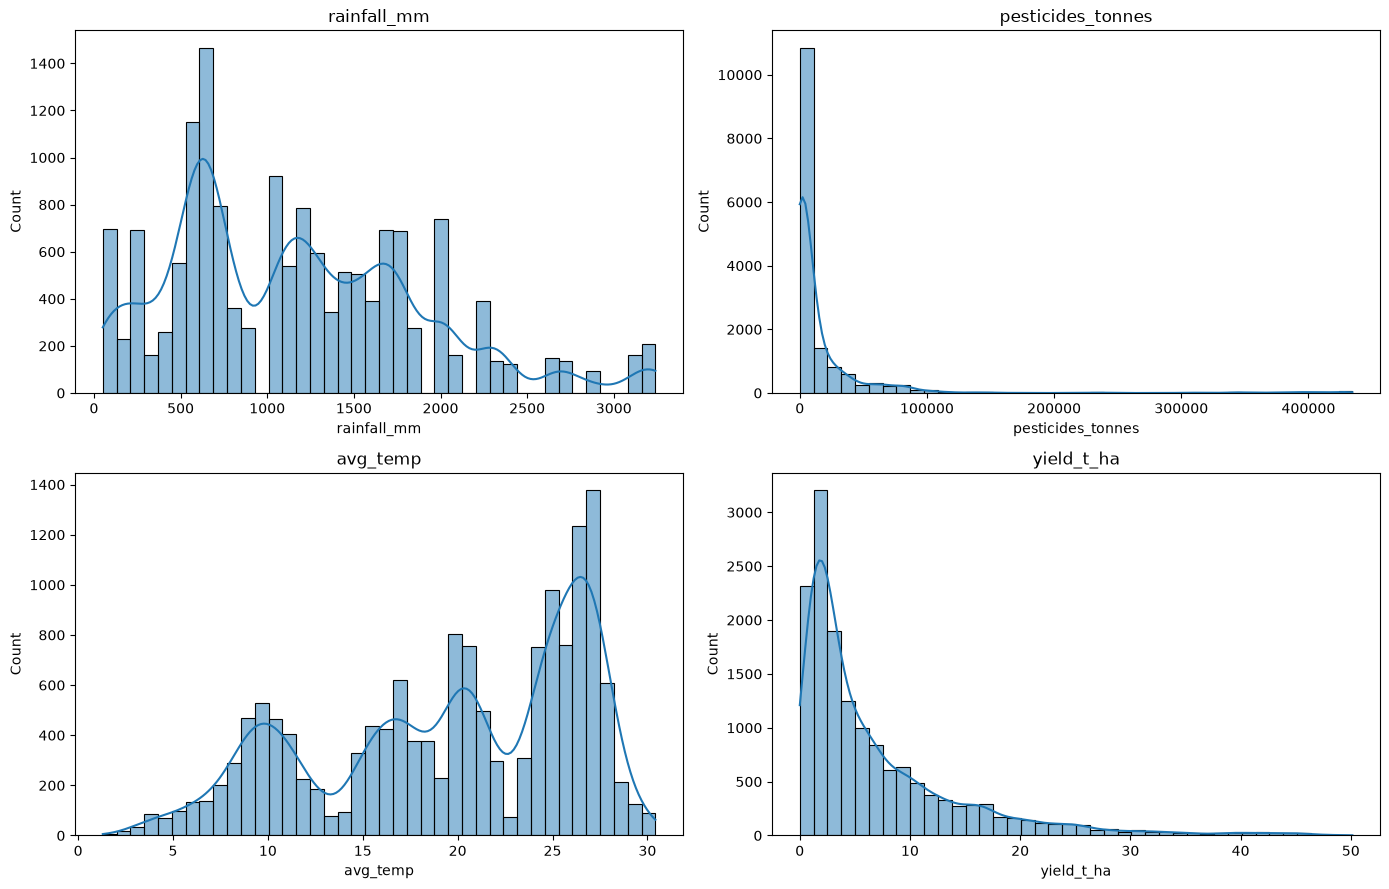

In [136]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(
        data=consolidated_clean,
        x=col,
        bins=40,
        kde=True,
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

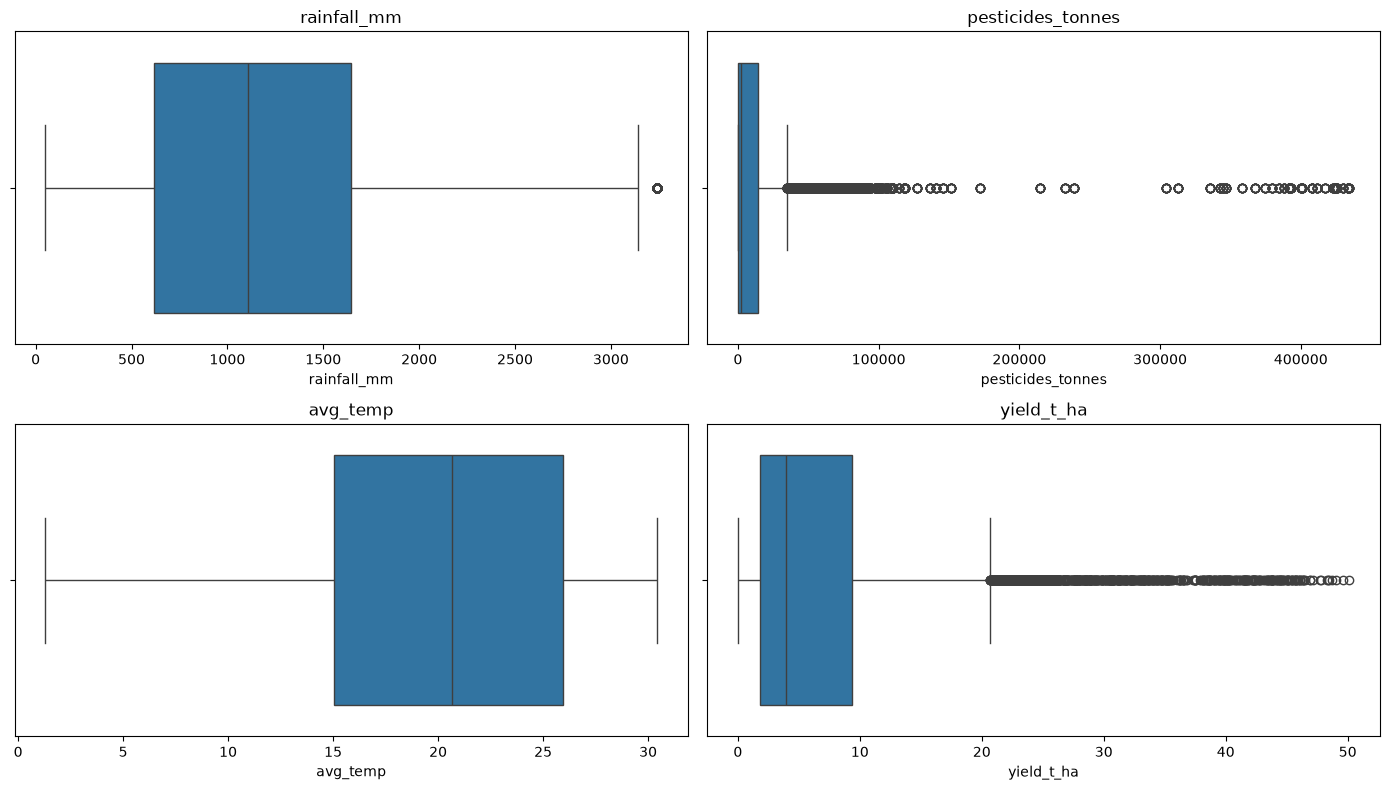

In [137]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(
        data=consolidated_clean,
        x=col,
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

##### Conclusion

- `rainfall_mm` présente une distribution **multimodale**, cohérente avec la diversité géographique des zones.
- `avg_temp` est également **multimodale** ; aucune valeur manifestement incohérente n'apparaît.
- `pesticides_tonnes` est **très asymétrique à droite**, avec de nombreuses valeurs élevées.
- `yield_t_ha` est **asymétrique à droite**, avec des rendements élevés mais plausibles selon les cultures.
- Les valeurs signalées par les boxplots ne sont pas supprimées automatiquement.
- Les distributions reflètent notamment l'hétérogénéité des zones et des cultures du dataset.

In [138]:
# Transformation logarithmique de la variable `pesticides_tonnes` pour réduire l'asymétrie de sa distribution. La transformation log1p est utilisée pour gérer les valeurs nulles.

consolidated_clean["pesticides_log1p"] = np.log1p(
    consolidated_clean["pesticides_tonnes"]
)

print(
    "Skewness pesticides brut :",
    round(consolidated_clean["pesticides_tonnes"].skew(), 3)
)

print(
    "Skewness pesticides log1p :",
    round(consolidated_clean["pesticides_log1p"].skew(), 3)
)

Skewness pesticides brut : 5.962
Skewness pesticides log1p : -0.44


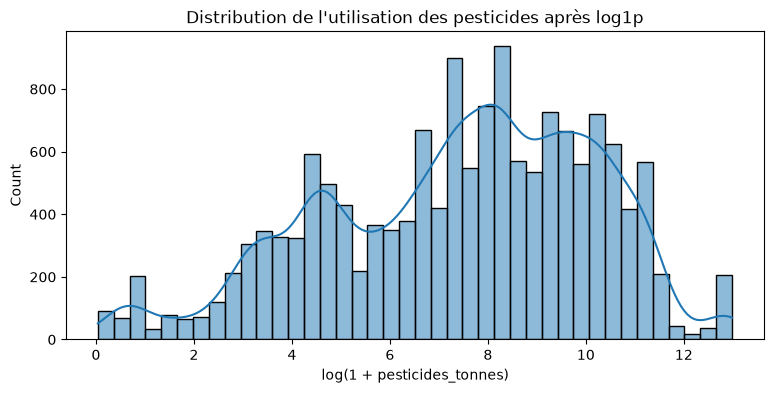

In [139]:
# Visualisation de la distribution de l'utilisation des pesticides après transformation log1p.

plt.figure(figsize=(9, 4))

sns.histplot(
    data=consolidated_clean,
    x="pesticides_log1p",
    bins=40,
    kde=True
)

plt.title("Distribution de l'utilisation des pesticides après log1p")
plt.xlabel("log(1 + pesticides_tonnes)")
plt.show()

##### Conclusion

- La distribution brute des pesticides est fortement asymétrique à droite.
- `log1p` réduit fortement l'influence visuelle des valeurs extrêmes.
- La distribution transformée reste multimodale et n'est pas supposée normale.
- La variable brute est conservée dans le dataset de référence.
- `log1p` sera considérée comme une transformation candidate dans le pipeline de modélisation.

### 7.5 Relations entre les variables et le rendement


#### 7.5.1 Corrélations numériques globales


In [141]:
correlation_cols = [
    "Year",
    "rainfall_mm",
    "pesticides_tonnes",
    "pesticides_log1p",
    "avg_temp",
    "yield_t_ha"
]

corr_matrix = (
    consolidated_clean[correlation_cols]
    .corr()
)

display(corr_matrix.round(3))

,Year,rainfall_mm,pesticides_tonnes,pesticides_log1p,avg_temp,yield_t_ha
Year,1.000,-0.010,0.045,0.052,0.002,0.086
rainfall_mm,-0.010,1.000,-0.010,0.048,0.380,0.013
pesticides_tonnes,0.045,-0.010,1.000,0.499,-0.120,0.114
pesticides_log1p,0.052,0.048,0.499,1.000,-0.381,0.190
avg_temp,0.002,0.380,-0.120,-0.381,1.000,-0.123
yield_t_ha,0.086,0.013,0.114,0.190,-0.123,1.000


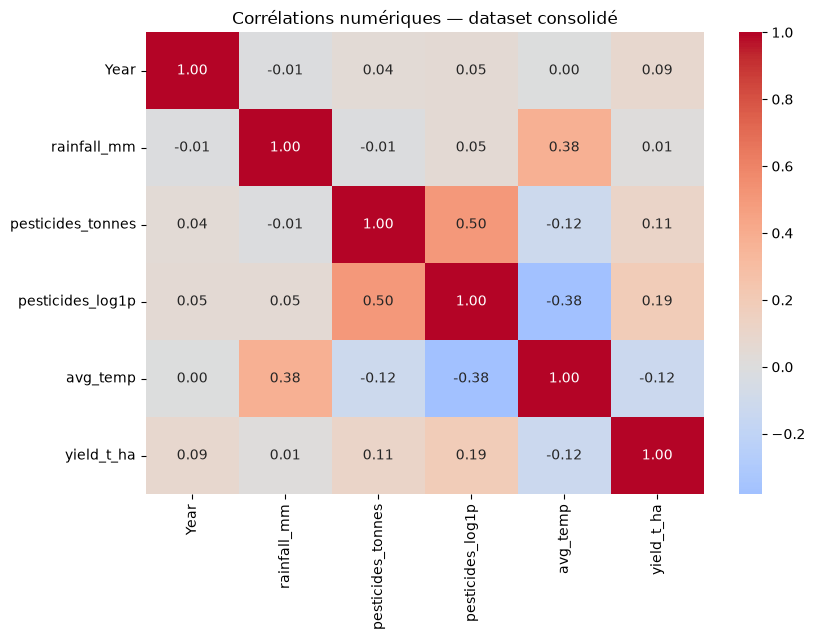

In [142]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Corrélations numériques — dataset consolidé")
plt.show()

In [143]:
yield_correlations = (
    corr_matrix["yield_t_ha"]
    .drop("yield_t_ha")
    .sort_values(
        key=abs,
        ascending=False
    )
)

display(
    yield_correlations
    .to_frame("correlation_with_yield")
    .round(3)
)

,correlation_with_yield
pesticides_log1p,0.190
avg_temp,-0.123
pesticides_tonnes,0.114
Year,0.086
rainfall_mm,0.013


##### Conclusion

- Les corrélations linéaires globales avec le rendement restent faibles.
- `pesticides_log1p` présente l'association la plus élevée : **r = 0,190**.
- `avg_temp` est faiblement négativement corrélée au rendement : **r = -0,123**.
- `pesticides_tonnes` présente une faible corrélation positive : **r = 0,114**.
- `Year` présente une faible association positive : **r = 0,086**.
- `rainfall_mm` est presque non corrélée globalement au rendement : **r = 0,013**.
- Ces résultats sont descriptifs et peuvent être masqués par les différences entre cultures et zones.

In [145]:
# Rendement selon la culture

yield_by_item = (
    consolidated_clean
    .groupby("Item")["yield_t_ha"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .sort_values(
        "median",
        ascending=False
    )
)

display(
    yield_by_item.round(3)
)

,count,mean,median,std,min,max
Item,,,,,,
Potatoes,2361,17.939,15.897,10.161,0.841,50.141
Cassava,1102,10.245,9.898,5.644,1.178,38.582
Yams,546,9.773,8.679,4.805,1.148,25.000
Plantains and others,579,10.188,8.672,7.261,1.953,41.850
Sweet potatoes,1370,10.160,8.218,6.953,0.880,40.000
"Rice, paddy",1774,3.758,3.430,1.944,0.203,10.390
Maize,2321,3.669,2.500,3.019,0.085,20.756
Wheat,2011,2.987,2.406,2.001,0.171,9.939
Soybeans,1502,1.629,1.571,0.773,0.005,4.161


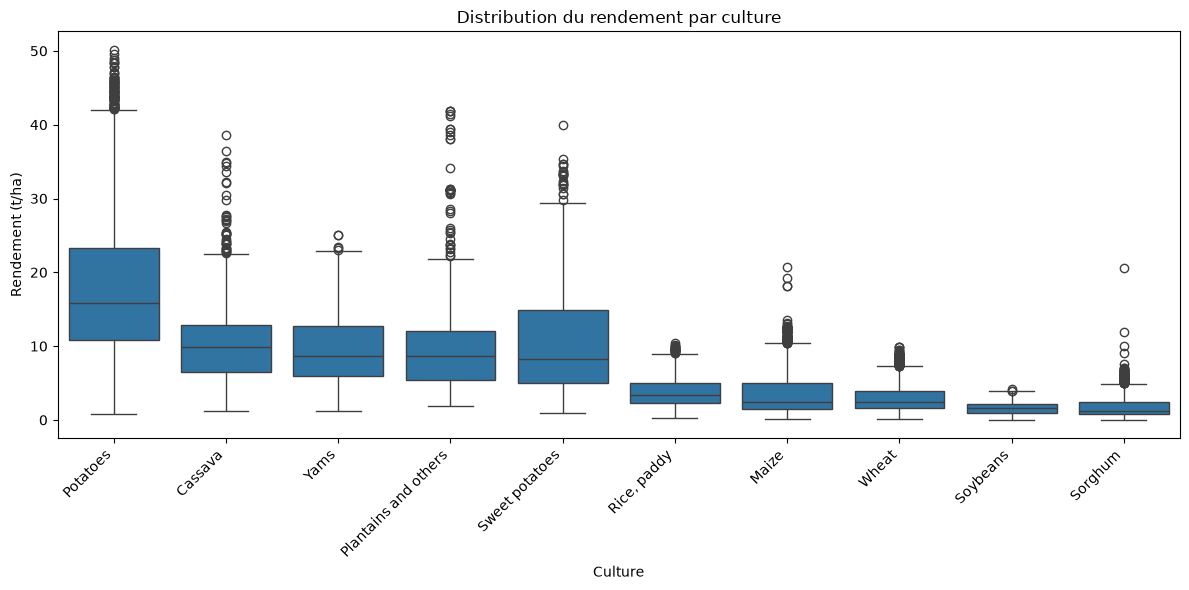

In [146]:
plt.figure(figsize=(12, 6))

order = (
    consolidated_clean
    .groupby("Item")["yield_t_ha"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=consolidated_clean,
    x="Item",
    y="yield_t_ha",
    order=order
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Culture")
plt.ylabel("Rendement (t/ha)")
plt.title("Distribution du rendement par culture")
plt.tight_layout()
plt.show()

##### Conclusion

- Le rendement varie fortement selon la culture.
- `Potatoes` présente la médiane la plus élevée : **15,90 t/ha**.
- `Cassava`, `Yams`, `Plantains and others` et `Sweet potatoes` présentent également des rendements médians élevés.
- `Soybeans` et `Sorghum` présentent les médianes les plus faibles.
- La dispersion du rendement varie fortement selon les cultures.
- Une analyse globale du rendement masque donc une forte hétérogénéité liée à `Item`.
- `Item` devra être intégré comme variable explicative majeure du futur modèle.

#### 7.5.3 Corrélations par culture


In [147]:
#Les corrélations sont recalculées séparément pour chaque culture afin de limiter l'effet de composition lié aux fortes différences de rendement


variables = [
    "Year",
    "rainfall_mm",
    "pesticides_tonnes",
    "pesticides_log1p",
    "avg_temp"
]

corr_by_item = pd.DataFrame({
    item: group[variables + ["yield_t_ha"]]
        .corr()["yield_t_ha"]
        .drop("yield_t_ha")
    for item, group in consolidated_clean.groupby("Item")
}).T

display(
    corr_by_item.round(3)
)

,Year,rainfall_mm,pesticides_tonnes,pesticides_log1p,avg_temp
Cassava,0.206,0.150,0.202,0.248,0.231
Maize,0.205,-0.154,0.246,0.392,-0.456
Plantains and others,0.017,0.225,0.059,0.426,-0.115
Potatoes,0.170,-0.113,0.332,0.492,-0.379
"Rice, paddy",0.193,-0.133,0.325,0.551,-0.317
Sorghum,0.091,0.029,0.341,0.520,-0.309
Soybeans,0.091,-0.025,0.338,0.525,-0.240
Sweet potatoes,0.149,-0.202,0.285,0.432,-0.325
Wheat,0.113,-0.047,0.026,0.246,-0.393
Yams,0.178,0.302,0.155,0.363,-0.205


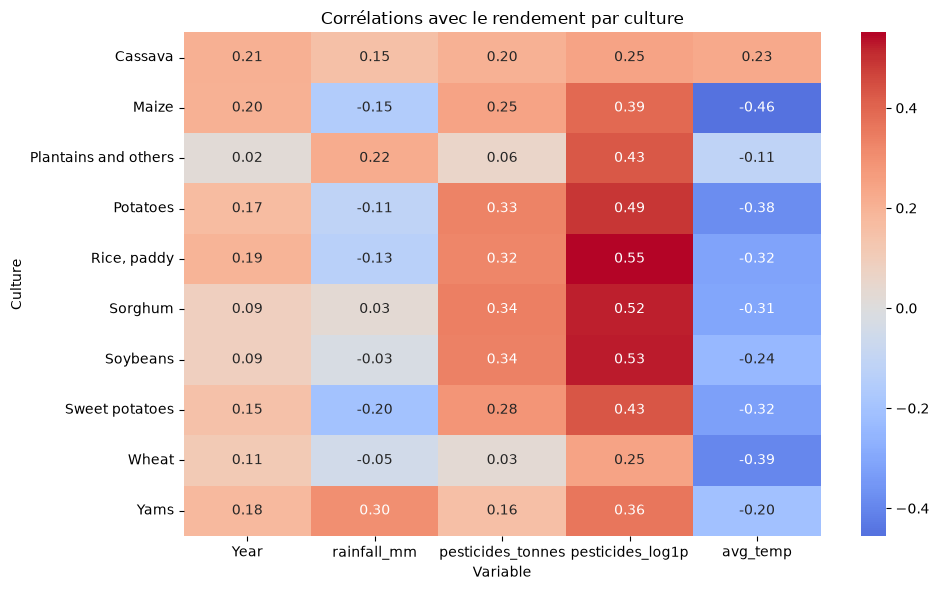

In [148]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_by_item,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Corrélations avec le rendement par culture")
plt.xlabel("Variable")
plt.ylabel("Culture")
plt.tight_layout()
plt.show()

##### Conclusion

- Les relations avec le rendement varient sensiblement selon la culture.
- `pesticides_log1p` est positivement corrélé au rendement pour les **10 cultures** (`r = 0,246` à `0,551`).
- `avg_temp` est négativement corrélée au rendement pour **9 cultures sur 10**, avec des associations marquées pour `Maize`, `Wheat` et `Potatoes`.
- L'effet linéaire de `rainfall_mm` est hétérogène selon les cultures, avec des corrélations positives comme négatives.
- `Year` présente une association positive pour toutes les cultures, généralement faible à modérée.
- Les corrélations globales masquent donc une partie importante de l'hétérogénéité entre cultures.
- Ces associations restent descriptives et ne démontrent aucune causalité.

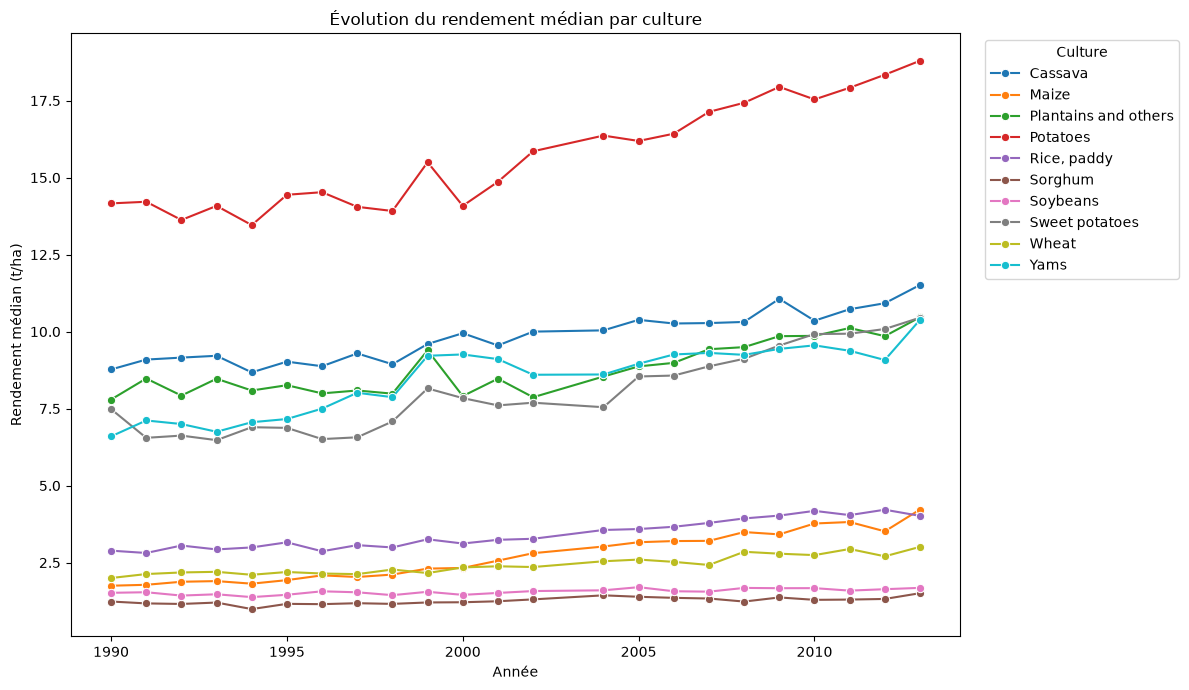

In [149]:
#tendance temporelle par culture
yield_item_year = (
    consolidated_clean
    .groupby(["Year", "Item"], as_index=False)
    .agg(
        median_yield=("yield_t_ha", "median")
    )
)

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=yield_item_year,
    x="Year",
    y="median_yield",
    hue="Item",
    marker="o"
)

plt.title("Évolution du rendement médian par culture")
plt.xlabel("Année")
plt.ylabel("Rendement médian (t/ha)")
plt.legend(
    title="Culture",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

##### Conclusion

- Les niveaux de rendement diffèrent fortement entre cultures.
- Une progression temporelle est visible pour la majorité des cultures.
- `Potatoes` présente une hausse particulièrement marquée sur la période.
- Certaines cultures, notamment `Sorghum` et `Soybeans`, évoluent plus faiblement.
- La tendance globale observée précédemment masque donc des trajectoires différentes selon `Item`.
- `Year` constitue une variable candidate pertinente, sans être interprétée comme une cause directe de l'évolution du rendement.

#### 7.5.5 Hétérogénéité géographique


In [150]:
#Etude différence de rendement entre zones géographiques => évaluer impact variables climatiques et agronomiques sur le rendement est influencé par la zone géographique.
yield_by_area = (
    consolidated_clean
    .groupby("Area_std")["yield_t_ha"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
    .sort_values("median", ascending=False)
)

display(yield_by_area.head(15))
display(yield_by_area.tail(15))

print(
    "Zones avec au moins 100 observations :",
    (yield_by_area["count"] >= 100).sum()
)

print(
    "Médiane des effectifs par zone :",
    yield_by_area["count"].median()
)

,count,mean,median,std
Area_std,,,,
United Kingdom,46,24.095648,19.41920,16.855768
Ireland,46,19.791370,17.41060,11.830302
Sweden,46,18.740550,17.02525,13.110296
Bahrain,29,15.323755,16.00000,3.865973
Jamaica,161,12.234787,15.63570,6.789978
Norway,46,14.611533,13.67270,10.490262
Mauritius,101,12.558626,13.20590,6.181918
Belgium,39,21.646846,11.68720,16.797049
New Zealand,92,19.193183,11.46690,15.034243


,count,mean,median,std
Area_std,,,,
Namibia,82,3.860335,2.00890,4.139084
Uganda,207,3.620442,2.00000,2.948113
Libya,69,6.533542,2.00000,7.869630
United Republic of Tanzania,230,3.207564,1.99310,2.680944
Burkina Faso,184,3.306161,1.94680,3.118529
Iraq,138,3.979972,1.88515,5.384669
Malawi,171,4.881120,1.82000,5.784503
Tunisia,69,5.397458,1.61510,6.307314
Mauritania,161,2.773814,1.58550,2.230956


Zones avec au moins 100 observations : 79
Médiane des effectifs par zone : 138.0


In [151]:
within_group_corrs = []

for (area, item), group in consolidated_clean.groupby(
    ["Area_std", "Item"]
):
    # Effectif minimum pour éviter des corrélations
    # calculées sur des groupes trop petits
    if len(group) >= 10:
        for variable in [
            "Year",
            "rainfall_mm",
            "pesticides_log1p",
            "avg_temp"
        ]:
            corr = group[variable].corr(
                group["yield_t_ha"]
            )

            within_group_corrs.append({
                "Area_std": area,
                "Item": item,
                "variable": variable,
                "correlation": corr,
                "n": len(group)
            })

within_group_corrs = pd.DataFrame(
    within_group_corrs
)

display(
    within_group_corrs
    .groupby("variable")["correlation"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .round(3)
)

c:\Users\obenb\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\obenb\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,count,mean,median,std,min,max
variable,,,,,,
Year,670,0.433,0.612,0.508,-0.987,0.996
avg_temp,670,0.141,0.160,0.302,-0.792,0.781
pesticides_log1p,669,0.123,0.162,0.483,-0.934,0.981
rainfall_mm,0,NaN,NaN,NaN,NaN,NaN


In [152]:
corr_sign_summary = (
    within_group_corrs
    .dropna(subset=["correlation"])
    .groupby("variable")["correlation"]
    .agg(
        n="count",
        pct_positive=lambda x: (x > 0).mean() * 100,
        pct_negative=lambda x: (x < 0).mean() * 100
    )
    .round(1)
)

display(corr_sign_summary)

,n,pct_positive,pct_negative
variable,,,
Year,670,80.4,19.6
avg_temp,670,70.0,30.0
pesticides_log1p,669,59.6,40.4


##### Conclusion intermédiaire

- `Year` présente le signal intra `Area × Item` le plus stable : **80,4 %** des corrélations sont positives.
- L'association de `avg_temp` devient majoritairement positive après contrôle de `Area × Item`, contrairement aux résultats globaux.
- L'association de `pesticides_log1p` reste positive en médiane mais très hétérogène selon les groupes.
- Les corrélations globales sont donc fortement influencées par la composition géographique et culturale.
- `rainfall_mm` produit uniquement des corrélations `NaN` et nécessite un contrôle technique avant interprétation.
- Aucune de ces associations ne permet d'établir une relation causale.

In [153]:
#Déterminer si rainfall_mm est constante à l'intérieur des groupes

rainfall_group_check = (
    consolidated_clean
    .groupby(["Area_std", "Item"])
    .agg(
        n=("Year", "size"),
        n_years=("Year", "nunique"),
        rainfall_nunique=("rainfall_mm", "nunique"),
        rainfall_std=("rainfall_mm", "std")
    )
)

eligible_rainfall_groups = rainfall_group_check[
    rainfall_group_check["n"] >= 10
]

print(
    "Groupes éligibles :",
    len(eligible_rainfall_groups)
)

print(
    "Groupes avec > 1 valeur de pluie :",
    (eligible_rainfall_groups["rainfall_nunique"] > 1).sum()
)

print(
    "Groupes avec écart-type pluie > 0 :",
    (eligible_rainfall_groups["rainfall_std"] > 0).sum()
)

display(
    eligible_rainfall_groups[
        [
            "n",
            "n_years",
            "rainfall_nunique",
            "rainfall_std"
        ]
    ].head(20)
)

Groupes éligibles : 670
Groupes avec > 1 valeur de pluie : 0
Groupes avec écart-type pluie > 0 : 0


n  n_years  rainfall_nunique  rainfall_std
Area_std  Item                                                       
Albania   Maize           23       23                 1           0.0
          Potatoes        23       23                 1           0.0
          Soybeans        23       23                 1           0.0
          Wheat           23       23                 1           0.0
Algeria   Maize           23       23                 1           0.0
          Potatoes        23       23                 1           0.0
          Rice, paddy     23       23                 1           0.0
          Sorghum         22       22                 1           0.0
          Wheat           23       23                 1           0.0
Angola    Cassava         23       23                 1           0.0
          Maize           23       23                 1           0.0
          Potatoes        23       23                 1           0.0
          Rice, paddy     23       23                 1           0.0
          Sorghum         13       13                 1           0.0
          Soybeans        13       13                 1           0.0
          Sweet potatoes  23       23                 1           0.0
          Wheat           23       23                 1           0.0
Argentina Cassava         23       23                 1           0.0
          Maize           23       23                 1           0.0
          Potatoes        23       23                 1           0.0

In [154]:
example_key = eligible_rainfall_groups.index[0]

example_area, example_item = example_key

example_group = consolidated_clean[
    (consolidated_clean["Area_std"] == example_area)
    & (consolidated_clean["Item"] == example_item)
][
    ["Year", "rainfall_mm", "yield_t_ha"]
].sort_values("Year")

print("Exemple :", example_area, "-", example_item)

display(example_group)

print(
    "Corrélation rainfall/yield :",
    example_group["rainfall_mm"].corr(
        example_group["yield_t_ha"]
    )
)

Exemple : Albania - Maize


,Year,rainfall_mm,yield_t_ha
92,1990,1485.0,3.6613
93,1991,1485.0,2.9068
94,1992,1485.0,2.4876
95,1993,1485.0,2.4185
96,1994,1485.0,2.5848
97,1995,1485.0,3.1300
98,1996,1485.0,3.2604
99,1997,1485.0,3.1862
100,1998,1485.0,3.3416
101,1999,1485.0,3.7455


Corrélation rainfall/yield : nan


c:\Users\obenb\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\obenb\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


##### Conclusion

- `rainfall_mm` ne varie pas dans le temps au sein des groupes `Area_std × Item` examinés.
- Exemple : l'Albanie conserve **1 485 mm/an** sur les 23 années disponibles.
- La variance intra-zone étant nulle, aucune corrélation temporelle pluie/rendement ne peut être calculée.
- La corrélation globale pluie/rendement mesure donc essentiellement des **différences entre zones**, et non des variations annuelles de précipitations.
- `rainfall_mm` peut rester une variable descriptive géographique, mais ne doit pas être interprétée comme une mesure annuelle réellement variable dans ce dataset.

### Synthèse des relations avec le rendement

- `Item` est fortement associé au niveau de rendement et constitue une variable explicative majeure.
- `Year` présente une tendance positive dans **80,4 %** des séries `Area × Item` étudiées.
- `avg_temp` change sensiblement d'interprétation selon le niveau d'analyse : négative globalement mais positive dans **70,0 %** des séries intra `Area × Item`.
- `pesticides_log1p` est plus exploitable que la variable brute, mais son association avec le rendement reste très hétérogène entre zones et cultures.
- `rainfall_mm` est constante dans le temps par zone ; elle représente principalement une caractéristique climatique géographique.
- Les corrélations globales sont fortement influencées par la composition en zones et en cultures.
- Aucune de ces associations ne permet d'établir une relation causale.

### 7.6 Comparaison avec `yield_df`


In [155]:
yield_df_reference = (
    yield_df
    .groupby(
        ["Area", "Item", "Year"],
        as_index=False
    )
    .agg(
        yield_ref=("hg/ha_yield", "first"),
        rainfall_ref=(
            "average_rain_fall_mm_per_year",
            "first"
        ),
        pesticides_ref=(
            "pesticides_tonnes",
            "first"
        ),
        avg_temp_ref=(
            "avg_temp",
            "mean"
        )
    )
)

yield_df_reference["yield_ref_t_ha"] = (
    yield_df_reference["yield_ref"] / 10_000
)

print(
    "Dimensions référence :",
    yield_df_reference.shape
)

print(
    "Clés répétées :",
    yield_df_reference.duplicated(
        ["Area", "Item", "Year"]
    ).sum()
)

Dimensions référence : (13130, 8)
Clés répétées : 0


In [156]:
comparison = consolidated_clean.merge(
    yield_df_reference,
    left_on=["Area_std", "Item", "Year"],
    right_on=["Area", "Item", "Year"],
    how="inner"
)

print(
    "Clés comparables :",
    len(comparison)
)

Clés comparables : 13130


In [157]:
comparison["diff_yield"] = (
    comparison["yield_t_ha"]
    - comparison["yield_ref_t_ha"]
).abs()

comparison["diff_rainfall"] = (
    comparison["rainfall_mm"]
    - comparison["rainfall_ref"]
).abs()

comparison["diff_pesticides"] = (
    comparison["pesticides_tonnes"]
    - comparison["pesticides_ref"]
).abs()

comparison["diff_temp"] = (
    comparison["avg_temp"]
    - comparison["avg_temp_ref"]
).abs()

In [158]:
comparison_summary = pd.DataFrame({
    "mean_abs_diff": [
        comparison["diff_yield"].mean(),
        comparison["diff_rainfall"].mean(),
        comparison["diff_pesticides"].mean(),
        comparison["diff_temp"].mean()
    ],
    "max_abs_diff": [
        comparison["diff_yield"].max(),
        comparison["diff_rainfall"].max(),
        comparison["diff_pesticides"].max(),
        comparison["diff_temp"].max()
    ]
}, index=[
    "yield_t_ha",
    "rainfall_mm",
    "pesticides_tonnes",
    "avg_temp"
])

display(comparison_summary)

,mean_abs_diff,max_abs_diff
yield_t_ha,0.000000,0.000000
rainfall_mm,0.000000,0.000000
pesticides_tonnes,0.000000,0.000000
avg_temp,0.030154,0.812929


##### Conclusion

- `yield_df` contient **13 130 clés uniques** `Area × Item × Year` après agrégation.
- Les **13 130 clés** sont retrouvées dans notre dataset consolidé.
- Le rendement, la pluie et les pesticides sont **strictement identiques** à `yield_df`.
- La température présente un faible écart moyen absolu de **0,030 °C**.
- L'écart maximal de température atteint **0,813 °C**.
- Ces écarts sont cohérents avec les différences de granularité observées dans les données de température.
- Notre reconstruction est donc cohérente avec `yield_df`, tout en conservant une granularité unique et explicitement contrôlée.

## 7.7 Synthèse de la stratégie de fusion

- `yield_data` constitue la source du rendement à la granularité **zone × culture × année**.
- `rainfall`, `pesticides` et `temp` sont harmonisés à la granularité **zone × année** avant fusion.
- Les noms géographiques sont harmonisés de manière contrôlée, faisant passer l'intersection de **101 à 114 zones**.
- La période commune contient **23 années entre 1990 et 2013**, l'année 2003 étant absente de `rainfall`.
- La température est dédupliquée puis agrégée annuellement afin d'éviter toute multiplication de lignes.
- Les absences étant principalement structurelles par zone, aucune imputation globale n'est réalisée.
- Le dataset consolidé contient **15 193 observations complètes**, **114 zones**, **10 cultures** et **7 variables principales**.
- La clé `Area_std × Item × Year` est unique et aucune valeur manquante ne subsiste.
- La comparaison avec `yield_df` confirme exactement le rendement, la pluie et les pesticides sur **13 130 clés communes** ; les écarts de température restent faibles.
- `yield_df` est conservé comme référence de contrôle et non comme source principale du dataset consolidé.

## 8. Nettoyage et préparation du dataset consolidé

### 8.1 Contrôle des valeurs extrêmes par culture


In [159]:
outlier_by_item = []

for item, group in consolidated_clean.groupby("Item"):
    q1 = group["yield_t_ha"].quantile(0.25)
    q3 = group["yield_t_ha"].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    flagged = (
        (group["yield_t_ha"] < lower)
        | (group["yield_t_ha"] > upper)
    )

    outlier_by_item.append({
        "Item": item,
        "n": len(group),
        "lower_iqr": lower,
        "upper_iqr": upper,
        "n_flagged": flagged.sum(),
        "pct_flagged": flagged.mean() * 100,
        "max_yield": group["yield_t_ha"].max()
    })

outlier_by_item = pd.DataFrame(
    outlier_by_item
).sort_values(
    "pct_flagged",
    ascending=False
)

display(
    outlier_by_item.round(3)
)

,Item,n,lower_iqr,upper_iqr,n_flagged,pct_flagged,max_yield
2,Plantains and others,579,-4.454,21.873,41,7.081,41.850
5,Sorghum,1627,-1.745,4.895,95,5.839,20.600
8,Wheat,2011,-1.885,7.308,101,5.022,9.939
3,Potatoes,2361,-7.757,41.988,91,3.854,50.141
1,Maize,2321,-3.912,10.417,85,3.662,20.756
0,Cassava,1102,-3.237,22.560,37,3.358,38.582
7,Sweet potatoes,1370,-9.661,29.526,21,1.533,40.000
4,"Rice, paddy",1774,-1.756,8.983,21,1.184,10.390
9,Yams,546,-4.222,22.997,5,0.916,25.000
6,Soybeans,1502,-0.754,3.924,3,0.200,4.161


##### Conclusion

- Les valeurs atypiques varient fortement selon la culture.
- La proportion signalée par l'IQR va de **0,2 % à 7,1 %**.
- `Plantains and others`, `Sorghum` et `Wheat` présentent les proportions les plus élevées.
- Les maxima restent cohérents avec les distributions historiques observées pour chaque culture.
- Le critère IQR identifie des valeurs statistiques atypiques, pas nécessairement des erreurs.
- Aucun rendement n'est supprimé sur ce seul critère.
- Les **15 193 observations** sont donc conservées.

### 8.2 Variables finales

Le dataset de référence conserve uniquement les variables sources harmonisées.
Les transformations destinées au machine learning seront réalisées
ultérieurement dans un pipeline de preprocessing afin d'éviter toute fuite
de données.

- **Variables explicatives candidates** : `Area_std`, `Item`, `Year`,
  `rainfall_mm`, `pesticides_tonnes`, `avg_temp`.
- **Variable cible** : `yield_t_ha`.
- `pesticides_log1p` n'est pas stockée comme variable source ; elle pourra
  être générée dans le pipeline ML.

In [160]:
final_columns = [
    "Area_std",
    "Item",
    "Year",
    "rainfall_mm",
    "pesticides_tonnes",
    "avg_temp",
    "yield_t_ha"
]

consolidated_final = (
    consolidated_clean[final_columns]
    .copy()
)

display(consolidated_final.head())

print("Dimensions :", consolidated_final.shape)
print("Colonnes :", consolidated_final.columns.tolist())

,Area_std,Item,Year,rainfall_mm,pesticides_tonnes,avg_temp,yield_t_ha
92,Albania,Maize,1990,1485.0,121.0,16.37,3.6613
93,Albania,Maize,1991,1485.0,121.0,15.36,2.9068
94,Albania,Maize,1992,1485.0,121.0,16.06,2.4876
95,Albania,Maize,1993,1485.0,121.0,16.05,2.4185
96,Albania,Maize,1994,1485.0,201.0,16.96,2.5848


Dimensions : (15193, 7)
Colonnes : ['Area_std', 'Item', 'Year', 'rainfall_mm', 'pesticides_tonnes', 'avg_temp', 'yield_t_ha']


### 8.3 Contrôle qualité avant export


In [161]:
quality_checks = {
    "15193_rows": len(consolidated_final) == 15193,
    "7_columns": consolidated_final.shape[1] == 7,
    "no_missing": consolidated_final.isna().sum().sum() == 0,
    "no_exact_duplicates": consolidated_final.duplicated().sum() == 0,
    "unique_key": (
        consolidated_final
        .duplicated(["Area_std", "Item", "Year"])
        .sum() == 0
    ),
    "114_areas": consolidated_final["Area_std"].nunique() == 114,
    "10_items": consolidated_final["Item"].nunique() == 10,
    "23_years": consolidated_final["Year"].nunique() == 23,
    "positive_yield": (consolidated_final["yield_t_ha"] > 0).all()
}

quality_checks

{'15193_rows': True,
 '7_columns': True,
 'no_missing': np.True_,
 'no_exact_duplicates': np.True_,
 'unique_key': np.True_,
 '114_areas': True,
 '10_items': True,
 '23_years': True,
 'positive_yield': np.True_}

In [162]:
assert all(quality_checks.values()), (
    "Au moins un contrôle qualité a échoué."
)

print("Tous les contrôles qualité sont validés.")

Tous les contrôles qualité sont validés.


### Conclusion du nettoyage et de la préparation

- Le dataset final contient **15 193 observations et 7 variables**.
- **114 zones**, **10 cultures** et **23 années** sont représentées.
- La clé `Area_std × Item × Year` est unique.
- Aucune valeur manquante ni aucun doublon ne subsiste.
- Tous les rendements sont strictement positifs.
- Les valeurs atypiques ont été contrôlées et conservées lorsqu'aucune erreur n'était démontrée.
- Les transformations ML (`log1p`, encodage, standardisation) ne sont pas appliquées au dataset source.
- Tous les contrôles qualité automatisés sont validés.

## 9. Analyse du dataset final

### 9.1 Fiche d'identité


In [163]:
final_summary = pd.Series({
    "observations": len(consolidated_final),
    "variables": consolidated_final.shape[1],
    "areas": consolidated_final["Area_std"].nunique(),
    "items": consolidated_final["Item"].nunique(),
    "years": consolidated_final["Year"].nunique(),
    "year_min": consolidated_final["Year"].min(),
    "year_max": consolidated_final["Year"].max(),
    "missing_values": consolidated_final.isna().sum().sum(),
    "duplicates": consolidated_final.duplicated().sum(),
    "duplicate_keys": consolidated_final.duplicated(
        ["Area_std", "Item", "Year"]
    ).sum()
})

display(
    final_summary.to_frame("value")
)

,value
observations,15193
variables,7
areas,114
items,10
years,23
year_min,1990
year_max,2013
missing_values,0
duplicates,0
duplicate_keys,0


### 9.2 Variables clés identifiées par l'EDA

- `Item` structure fortement les niveaux de rendement.
- `Year` présente une tendance positive dans la majorité des séries `Area × Item`.
- `avg_temp` montre des associations différentes selon le niveau d'analyse, ce qui suggère des interactions avec la géographie et la culture.
- `pesticides_tonnes` est fortement asymétrique ; `log1p` constitue une transformation candidate pour la modélisation.
- `rainfall_mm` est essentiellement une caractéristique climatique géographique, car elle ne varie pas dans le temps au sein d'une zone.
- `Area_std` doit être conservée pour représenter l'hétérogénéité géographique, mais son utilisation dans le modèle devra être évaluée.
- Les effets non linéaires et interactions devront être étudiés pendant la modélisation.

### 9.3 Limites identifiées

- **39,1 %** des observations temporellement éligibles sont exclues faute de couverture complète des variables explicatives.
- Les absences sont principalement structurelles et géographiques, notamment pour la température.
- `rainfall_mm` ne représente pas une variation annuelle effective au sein des zones.
- `pesticides_tonnes` correspond à un total annuel par zone et non à une quantité appliquée spécifiquement à chaque culture.
- Les effectifs sont déséquilibrés entre zones et cultures.
- Les associations observées varient fortement selon la culture et la zone.
- Les analyses descriptives ne permettent pas d'établir de relations causales.

## 10. Analyse en composantes principales — Agriculture CropYield Dataset


### 10.1 Préparation


In [164]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [165]:
pca_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Days_to_Harvest",
    "Fertilizer_Used",
    "Irrigation_Used"
]

X_pca = crop_yield[pca_features].copy()

X_pca["Fertilizer_Used"] = (
    X_pca["Fertilizer_Used"].astype(int)
)

X_pca["Irrigation_Used"] = (
    X_pca["Irrigation_Used"].astype(int)
)

scaler_pca = StandardScaler()

X_pca_scaled = scaler_pca.fit_transform(
    X_pca
)

print("Dimensions :", X_pca.shape)
print("Valeurs manquantes :", X_pca.isna().sum().sum())

Dimensions : (1000000, 5)
Valeurs manquantes : 0


In [166]:
pca = PCA()

X_pca_transformed = pca.fit_transform(
    X_pca_scaled
)

explained_variance = pd.DataFrame({
    "component": [
        f"PC{i+1}"
        for i in range(len(pca_features))
    ],
    "explained_variance_ratio":
        pca.explained_variance_ratio_,
    "cumulative_variance":
        np.cumsum(
            pca.explained_variance_ratio_
        )
})

display(
    explained_variance.round(4)
)

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.2007,0.2007
1,PC2,0.2005,0.4012
2,PC3,0.2001,0.6013
3,PC4,0.1994,0.8007
4,PC5,0.1993,1.0000


In [167]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_features,
    columns=[
        f"PC{i+1}"
        for i in range(len(pca_features))
    ]
)

display(
    pca_loadings.round(3)
)

,PC1,PC2,PC3,PC4,PC5
Rainfall_mm,0.149,0.733,-0.156,-0.063,0.643
Temperature_Celsius,0.464,-0.228,-0.614,-0.594,-0.055
Days_to_Harvest,-0.527,-0.501,-0.089,-0.188,0.654
Fertilizer_Used,0.593,-0.385,-0.030,0.611,0.355
Irrigation_Used,0.364,-0.107,0.768,-0.485,0.177


### Conclusion de l'ACP

- Les 5 composantes expliquent chacune environ **20 %** de la variance.
- Aucune composante ne domine : PC1 n'explique que **20,07 %**.
- Il faut **4 composantes sur 5** pour conserver environ **80 %** de la variance.
- L'ACP offre donc peu de réduction dimensionnelle sur ce dataset.
- Ce résultat est cohérent avec les faibles corrélations entre les variables explicatives.
- Les coefficients décrivent la construction des composantes, mais ne mesurent pas l'importance prédictive pour `Yield`.
- L'importance des variables pour le rendement devra être évaluée avec des méthodes supervisées lors de la modélisation.

# 11. Export du dataset consolidé


In [168]:
OUTPUT_PATH = DATA_DIR / "consolidated_crop_yield.csv"

consolidated_final.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Fichier exporté :", OUTPUT_PATH)

Fichier exporté : data\consolidated_crop_yield.csv


In [169]:
#vérification de l'exportation en relisant le fichier et en comparant les dimensions et les types de données avec le DataFrame original.
consolidated_check = pd.read_csv(OUTPUT_PATH)

print("Dimensions :", consolidated_check.shape)
print(
    "Valeurs manquantes :",
    consolidated_check.isna().sum().sum()
)
print(
    "Doublons :",
    consolidated_check.duplicated().sum()
)
print(
    "Clés dupliquées :",
    consolidated_check.duplicated(
        ["Area_std", "Item", "Year"]
    ).sum()
)

display(consolidated_check.head())

Dimensions : (15193, 7)
Valeurs manquantes : 0
Doublons : 0
Clés dupliquées : 0


,Area_std,Item,Year,rainfall_mm,pesticides_tonnes,avg_temp,yield_t_ha
0,Albania,Maize,1990,1485.0,121.0,16.37,3.6613
1,Albania,Maize,1991,1485.0,121.0,15.36,2.9068
2,Albania,Maize,1992,1485.0,121.0,16.06,2.4876
3,Albania,Maize,1993,1485.0,121.0,16.05,2.4185
4,Albania,Maize,1994,1485.0,201.0,16.96,2.5848


In [170]:
assert consolidated_check.shape == (15193, 7)
assert consolidated_check.isna().sum().sum() == 0
assert consolidated_check.duplicated().sum() == 0

assert (
    consolidated_check
    .duplicated(["Area_std", "Item", "Year"])
    .sum()
    == 0
)

print("Export validé.")

Export validé.


# 12. Synthèse et contrôle qualité de l'étape 1

## Résultats principaux

- Les six fichiers fournis ont été explorés et contrôlés individuellement.
- `yield_data` a été retenu comme source historique du rendement.
- Les données climatiques et agronomiques ont été harmonisées à la granularité `Area × Year`.
- Les noms géographiques ont été harmonisés de manière contrôlée.
- La période commune couvre **23 années entre 1990 et 2013, hors 2003**.
- Les absences de données étant principalement structurelles par zone, aucune imputation globale n'a été réalisée.
- Le dataset final contient **15 193 observations**, **114 zones** et **10 cultures**.
- La granularité finale est `Area_std × Item × Year`.
- Le dataset ne contient ni valeur manquante ni doublon.
- La comparaison avec `yield_df` valide exactement le rendement, la pluie et les pesticides sur **13 130 clés communes** ; les écarts de température sont faibles.
- L'ACP sur `crop_yield` ne révèle aucune composante dominante : les cinq axes expliquent chacun environ **20 %** de la variance.
- Le dataset consolidé est prêt pour la phase de modélisation.

## Limites

- **39,1 %** des observations temporellement éligibles sont exclues en raison d'une couverture incomplète des sources.
- La couverture manquante est principalement géographique et n'est donc pas aléatoire.
- `rainfall_mm` est constante dans le temps au sein d'une zone et représente surtout une caractéristique climatique géographique.
- `pesticides_tonnes` correspond à un total annuel par zone, et non à une quantité spécifique à chaque culture.
- Les cultures et les zones présentent des effectifs déséquilibrés.
- Les associations observées sont descriptives et ne démontrent pas de relations causales.
- Les transformations et sélections de variables destinées au ML seront réalisées dans le pipeline de modélisation afin d'éviter les fuites de données.

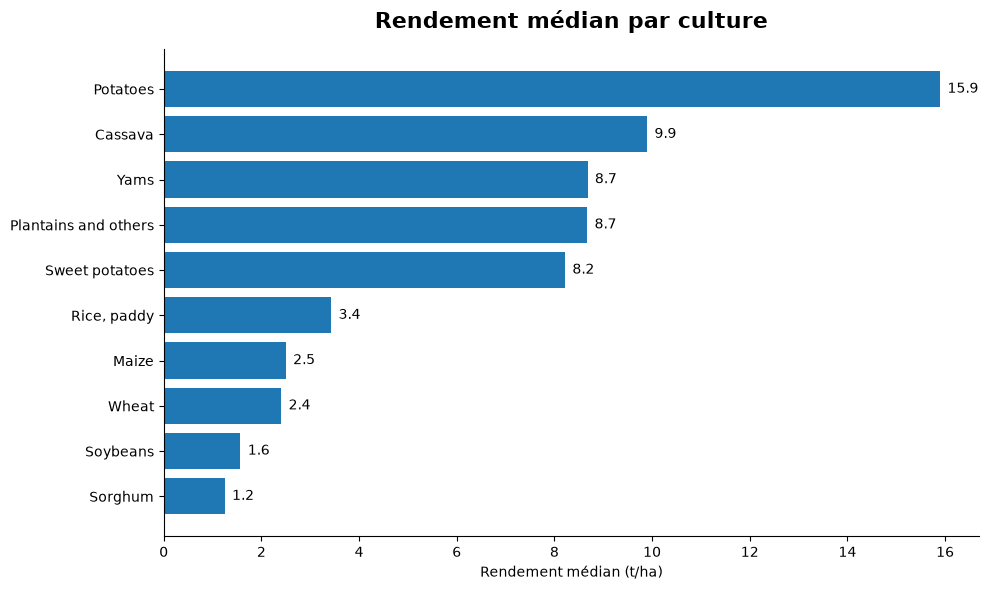

In [171]:
# Rendement médian par culture
yield_median_item = (
    consolidated_final
    .groupby("Item")["yield_t_ha"]
    .median()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    yield_median_item.index,
    yield_median_item.values
)

ax.set_title(
    "Rendement médian par culture",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Rendement médian (t/ha)")
ax.set_ylabel("")

# Valeurs au bout des barres
for bar in bars:
    value = bar.get_width()
    ax.text(
        value + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        fontsize=10
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

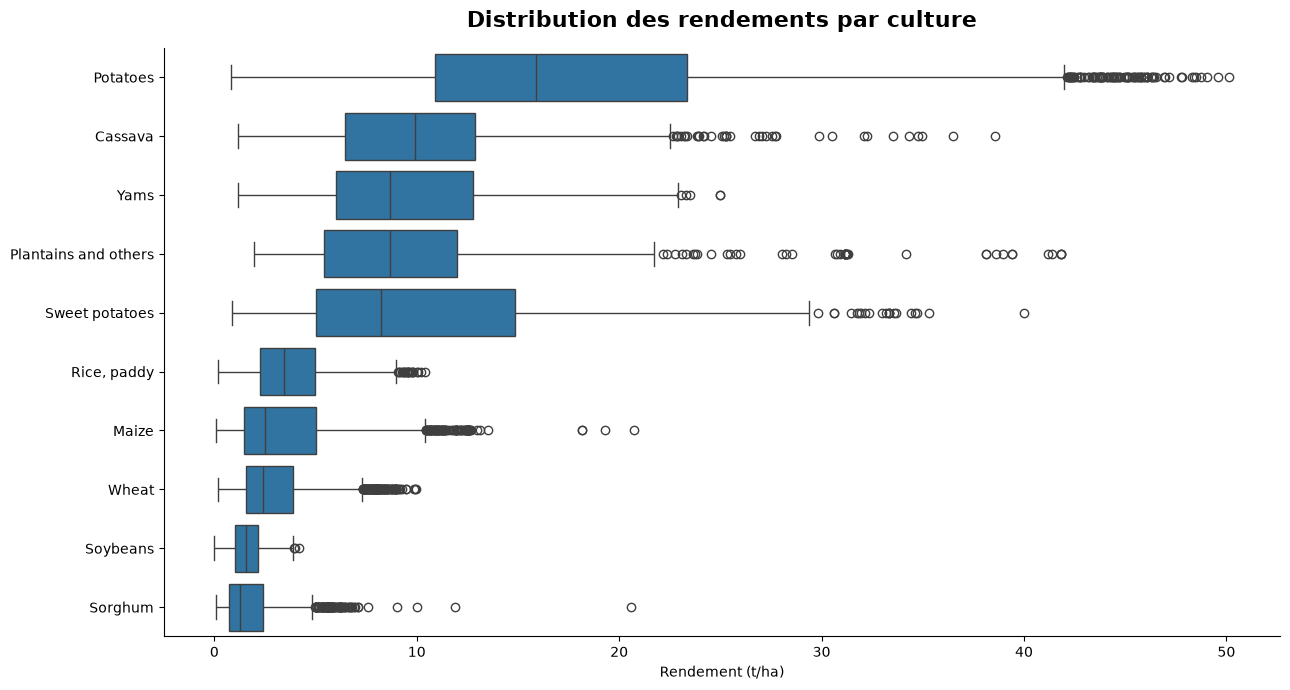

In [172]:
plt.figure(figsize=(13, 7))

order = (
    consolidated_final
    .groupby("Item")["yield_t_ha"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=consolidated_final,
    x="yield_t_ha",
    y="Item",
    order=order,
    showfliers=True
)

plt.title(
    "Distribution des rendements par culture",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Rendement (t/ha)")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

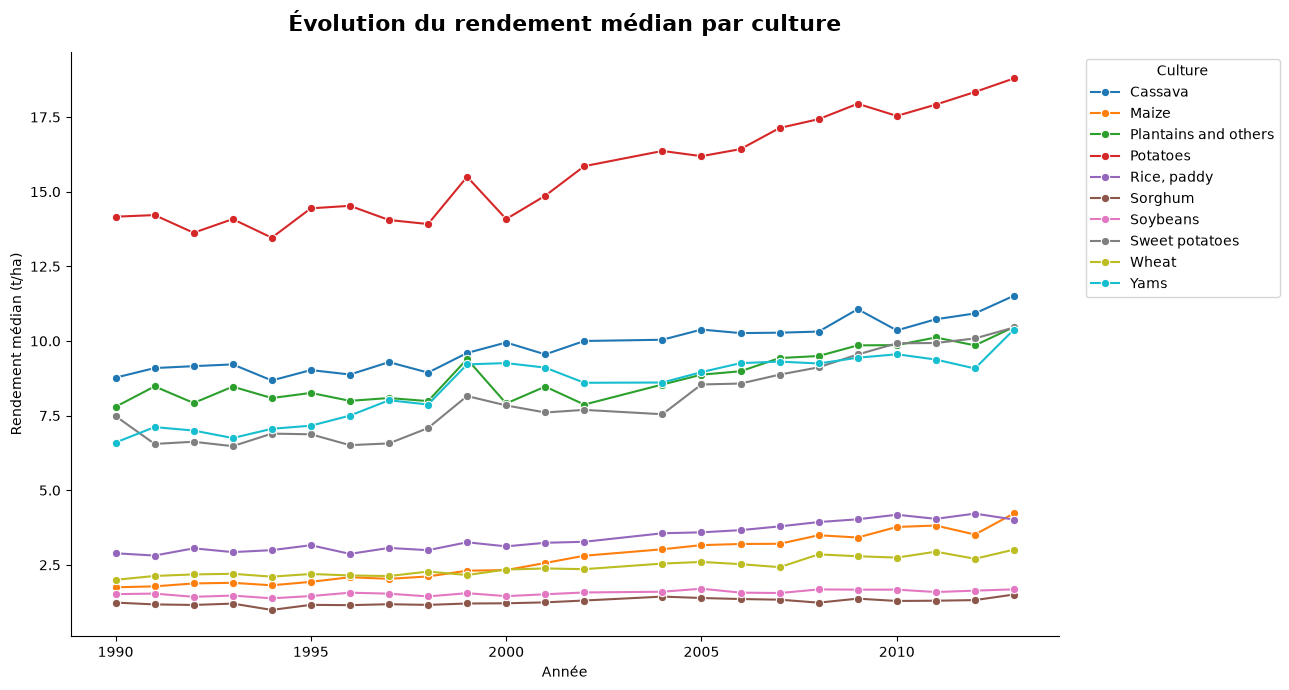

In [173]:
yield_year_item = (
    consolidated_final
    .groupby(["Year", "Item"], as_index=False)
    ["yield_t_ha"]
    .median()
)

plt.figure(figsize=(13, 7))

sns.lineplot(
    data=yield_year_item,
    x="Year",
    y="yield_t_ha",
    hue="Item",
    marker="o"
)

plt.title(
    "Évolution du rendement médian par culture",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Année")
plt.ylabel("Rendement médian (t/ha)")

plt.legend(
    title="Culture",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

sns.despine()
plt.tight_layout()
plt.show()

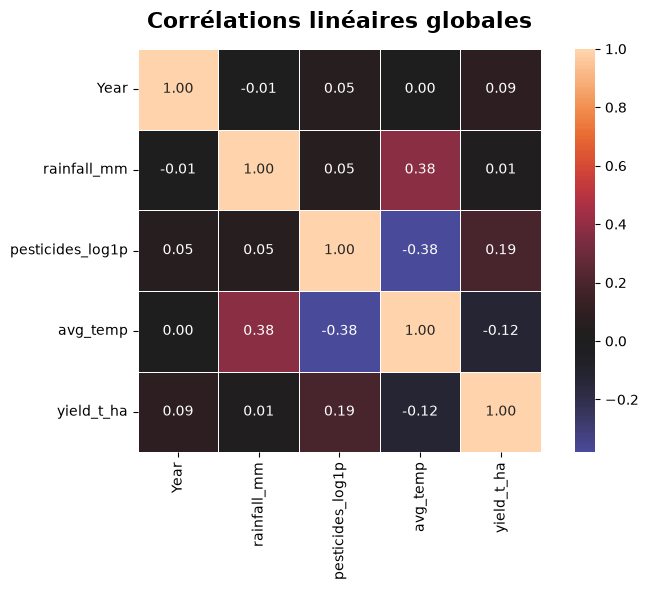

In [174]:
# Création uniquement pour l'analyse
corr_data = consolidated_final.copy()

corr_data["pesticides_log1p"] = np.log1p(
    corr_data["pesticides_tonnes"]
)

corr_columns = [
    "Year",
    "rainfall_mm",
    "pesticides_log1p",
    "avg_temp",
    "yield_t_ha"
]

corr_matrix = (
    corr_data[corr_columns]
    .corr()
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Corrélations linéaires globales",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.show()

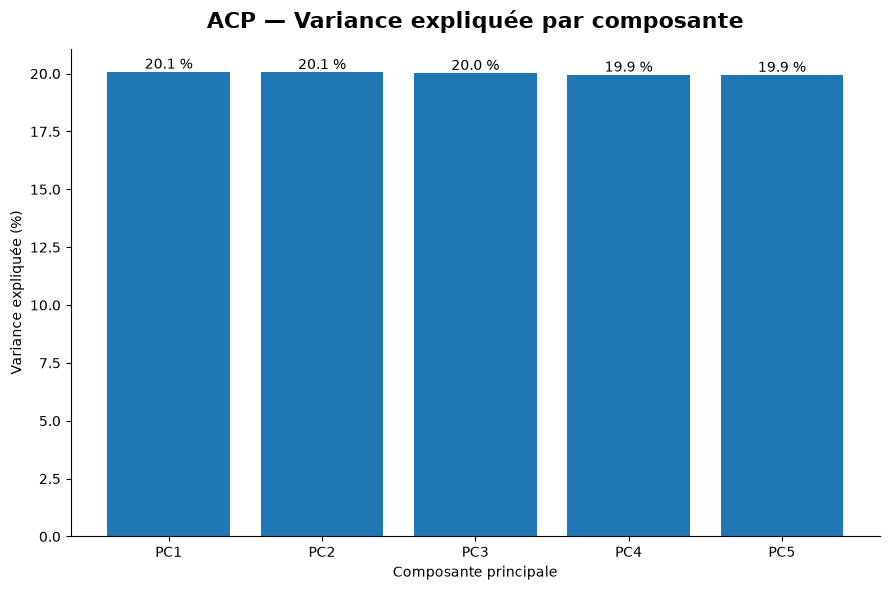

In [175]:
pca_plot = explained_variance.copy()

pca_plot["explained_pct"] = (
    pca_plot["explained_variance_ratio"] * 100
)

pca_plot["cumulative_pct"] = (
    pca_plot["cumulative_variance"] * 100
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    pca_plot["component"],
    pca_plot["explained_pct"]
)

ax.set_title(
    "ACP — Variance expliquée par composante",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Composante principale")
ax.set_ylabel("Variance expliquée (%)")

# Affichage des pourcentages
for bar, value in zip(
    bars,
    pca_plot["explained_pct"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{value:.1f} %",
        ha="center",
        fontsize=10
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

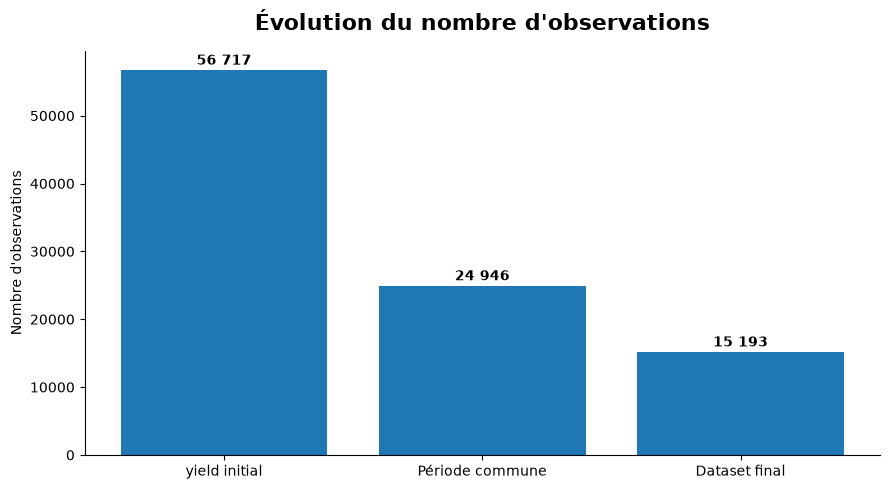

In [176]:
pipeline_counts = pd.DataFrame({
    "Etape": [
        "yield initial",
        "Période commune",
        "Dataset final"
    ],
    "Observations": [
        56717,
        24946,
        15193
    ]
})

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    pipeline_counts["Etape"],
    pipeline_counts["Observations"]
)

ax.set_title(
    "Évolution du nombre d'observations",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Nombre d'observations")
ax.set_xlabel("")

for bar in bars:
    value = int(bar.get_height())

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 800,
        f"{value:,}".replace(",", " "),
        ha="center",
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()